# JWST/MIRI SN1983V Photometry Notebook

- Written by Justin Pierel
- Edited / Formatted by Sophie Kressy

In [1]:
%matplotlib inline

* Create directory to store data -- make sure this matches your current working directory
* Import WEBBPSF Data

In [2]:
import sys,os,glob,shutil
import tarfile, urllib.request

# Set environmental variables
#os.environ["WEBBPSF_PATH"] = "./webbpsf-data/webbpsf-data"
#os.environ["PYSYN_CDBS"] = "./grp/redcat/trds/"

#os.environ["STPSF_PATH"] = "/grp/stpsf/stpsf-data"
# os.environ["STPSF_PATH"] = "./stpsf-data/stpsf-data/"
# os.environ["PYSYN_CDBS"] = "/grp/hst/cdbs"

# update this path to your working directory!!
os.environ["STPSF_PATH"] = '/Users/sophiakressy/Library/Mobile Documents/com~apple~CloudDocs/Desktop/VS_Workspace/sn_dust/stpsf-data/stpsf-data/'
os.environ["PYSYN_CDBS"] = "/Users/sophiakressy/Library/Mobile Documents/com~apple~CloudDocs/Desktop/VS_Workspace/sn_dust/grp"

# WEBBPSF Data
#boxlink = 'https://stsci.box.com/shared/static/qxpiaxsjwo15ml6m4pkhtk36c9jgj70k.gz'  
boxlink = 'https://stsci.box.com/shared/static/kqfolg2bfzqc4mjkgmujo06d3iaymahv.gz'
#boxfile = './webbpsf-data/webbpsf-data-1.0.0.tar.gz'
boxfile = './stpsf-data/stpsf-data-LATEST.tar.gz'
synphot_url = 'http://ssb.stsci.edu/trds/tarfiles/synphot5.tar.gz'
synphot_file = './synphot5.tar.gz'

#webbpsf_folder = './webbpsf-data'
stpsf_folder = "./stpsf-data"
synphot_folder = './grp'

# Gather webbpsf files
#psfExist = os.path.exists(webbpsf_folder)
psfExist = os.path.exists(stpsf_folder)
if not psfExist:
    os.makedirs(stpsf_folder)
    urllib.request.urlretrieve(boxlink, boxfile)
    gzf = tarfile.open(boxfile)
    gzf.extractall(stpsf_folder)

# Gather synphot files
synExist = os.path.exists(synphot_folder)
if not synExist:
    os.makedirs(synphot_folder)
    urllib.request.urlretrieve(synphot_url, synphot_file)
    gzf = tarfile.open(synphot_file)
    gzf.extractall('./')

Import functions

In [3]:
import numpy as np
import sys,os,glob
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy import wcs
from astropy.wcs.utils import skycoord_to_pixel
from astropy import units as u
# from astroquery.mast import Observations
from astropy.visualization import (simple_norm,LinearStretch)
from astropy.wcs import WCS
from photutils.centroids import centroid_com, centroid_sources, centroid_2dg, centroid_quadratic
from photutils.centroids import (centroid_1dg, centroid_2dg,
                                 centroid_com, centroid_quadratic)
from photutils.datasets import make_4gaussians_image
# import jhat
# from jhat import hst_photclass,st_wcs_align
import space_phot
from stwcs.updatewcs import wcsutil
import shutil
import drizzlepac
import stpsf


/Users/sophiakressy/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-071
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


The following tasks in the drizzlepac package can be run with TEAL:
    astrodrizzle       config_testbed      imagefindpars           mapreg       
       photeq            pixreplace           pixtopix            pixtosky      
  refimagefindpars       resetbits          runastrodriz          skytopix      
     tweakback            tweakreg           updatenpol


* polyfit2d and polyval2D_custom: create polyfit functions for a 2D array (credit/questions: Justin Pierel)
* optimize_psf: takes Justin's code and loops through xshift, yshift, background parameters to find best values.
    - For each iteration, fits PSF and calculates residual. 
    - The residual is fitted with a 2D surface polynomial and calculates the residual.
    - The standard deviation of this residual of the residual is found; this is the value that is minimized.
    - options for plotting and number of iterations for each parameter.
    - window is assumed to be 11 pixels. This needs to be incorportated at some point as an additional parameter.

In [4]:
def polyfit2d(x, y, z, deg=2):
    # Build design matrix for 2D polynomial of given degree
    ncols = (deg + 1) * (deg + 2) // 2
    G = np.zeros((x.size, ncols))
    ij = [(i, j) for i in range(deg+1) for j in range(deg+1-i)]
    for k, (i, j) in enumerate(ij):
        G[:, k] = x**i * y**j
    m, _, _, _ = np.linalg.lstsq(G, z, rcond=None)
    return m, ij

def polyval2d_custom(x, y, m, ij):
    z = np.zeros_like(x, dtype=float)

    for a, (i, j) in zip(m, ij):
        z += a * x**i * y**j
    return z


def optimize_psf(drz_obs, drz_psf, sn_loc, fwidth, xshift_range, yshift_range, background_range, nxs, nys, nbkg, plotting):
    smooth_stds = []
    xshifts     = []
    yshifts     = []
    backgrounds = []

    for xshift in np.linspace(xshift_range[0],xshift_range[1],nxs):
        for yshift in np.linspace(yshift_range[0],yshift_range[1],nys): 
            for bkg in np.linspace(background_range[0],background_range[1],nbkg):
                drz_obs.psf_photometry(drz_psf,sn_loc,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=fwidth,
                            background = bkg,
                            fit_bkg=False,
                            fit_centroid=False, 
                            fit_flux=True,
                            centroidx_shift=xshift,
                            centroidy_shift=yshift,
                            psf_method='nest',
                            center_weight=25,npoints=200)

                resid_cutout = drz_obs.psf_result.resid_arr[0][2:fwidth-2,2:fwidth-2]
                yy, xx = np.mgrid[0:resid_cutout.shape[0], 0:resid_cutout.shape[1]]
                xx = xx - resid_cutout.shape[1]//2
                yy = yy - resid_cutout.shape[0]//2

                # Fit and evaluate
                z = resid_cutout.flatten()
                x_flat = xx.flatten()
                y_flat = yy.flatten()
                m, ij = polyfit2d(x_flat, y_flat, z, deg=2)
                model = polyval2d_custom(xx, yy, m, ij)
                residuals_from_model = resid_cutout - model

                # Final metric: deviation from smooth model
                smoothness_metric = np.std(residuals_from_model)
                # print(f"Deviation from 2D smooth background model: {smoothness_metric:.5f}")
                
                smooth_stds.append(smoothness_metric)
                xshifts.append(xshift)
                yshifts.append(yshift)
                backgrounds.append(bkg)

                if plotting == True:
                    drz_obs.plot_psf_fit()
                    plt.show()

                    plt.imshow(residuals_from_model)
                    plt.title('Residual from 2D Smooth Background Model')
                    plt.colorbar()
                    plt.show()
                
    return smooth_stds, xshifts, yshifts, backgrounds



                


## Select level 2 and level 3 file paths

In [5]:
# SN 2009HD
# lvl2 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN2009HD/lvl_2/*skysub_cal.fits'
# lvl3 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN2009HD/lvl_3/*jhat_i2d.fits'
# lvl3_single = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN2009HD/lvl_3/jw02107-o011_t011_miri_f770w_jhat_i2d.fits'

# ra  = '11:20:16.9038' #unit=(u.hourangle,u.deg)) #icrs
# dec = '+12:58:47.105' #unit=(u.hourangle,u.deg)) #icrs


# SN 1983V
lvl2 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/*skysub_cal.fits'
lvl3 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/*jhat_i2d.fits'
lvl3_single = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f770w_jhat_i2d.fits'
# lvl3_single_1130 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-c1003_t003_miri_f1130w_jhat_i2d.fits'

ra  = '3:33:31.6159' #unit=(u.hourangle,u.deg)) #icrs
dec = '-36:08:55.222' #unit=(u.hourangle,u.deg)) #icrs

# ra1130  = '3:33:31.6099'
# dec1130 = '-36:08:55.046'

### grab files

In [6]:
files = glob.glob(lvl2) #lvl2
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter_arr

['F2100W', 'F1000W', 'F770W', 'F1000W', 'F1130W', 'F770W', 'F2100W', 'F1130W', 'F1000W', 'F770W', 'F770W', 'F2100W', 'F1000W', 'F1130W', 'F2100W', 'F1130W', 'F1000W', 'F770W', 'F770W', 'F1130W', 'F2100W', 'F1130W', 'F2100W', 'F1000W', 'F1130W', 'F770W', 'F1000W', 'F1000W', 'F2100W', 'F1130W', 'F2100W', 'F770W', 'F1130W', 'F1130W', 'F1000W', 'F2100W', 'F2100W', 'F1000W', 'F770W', 'F770W', 'F2100W', 'F770W', 'F1130W', 'F770W', 'F2100W', 'F1130W', 'F1000W', 'F1000W', 'F1130W', 'F770W', 'F2100W', 'F1000W', 'F1130W', 'F2100W', 'F770W', 'F1000W', 'F2100W', 'F2100W', 'F1130W', 'F1000W', 'F1130W', 'F770W', 'F770W', 'F1000W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003003_05101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003002_03101_00003_mirimage_skysub_cal.fits', '/Users/sophiakre

['F2100W',
 'F1000W',
 'F770W',
 'F1000W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F770W',
 'F770W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F770W',
 'F770W',
 'F1130W',
 'F2100W',
 'F1130W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F770W',
 'F1000W',
 'F1000W',
 'F2100W',
 'F1130W',
 'F2100W',
 'F770W',
 'F1130W',
 'F1130W',
 'F1000W',
 'F2100W',
 'F2100W',
 'F1000W',
 'F770W',
 'F770W',
 'F2100W',
 'F770W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F1000W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F2100W',
 'F770W',
 'F1000W',
 'F2100W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F1130W',
 'F770W',
 'F770W',
 'F1000W']

## Get Centroid

In [7]:
f = fits.open(lvl3_single)
data = f[1].data
w = WCS(f[1].header)

initial_location = SkyCoord(ra,dec,unit=(u.hourangle,u.deg)) #icrs
print(initial_location)

x_init, y_init = wcs.utils.skycoord_to_pixel(initial_location,w)
print(x_init, y_init)

x_cent, y_cent = centroid_sources(data, x_init, y_init, box_size=3, centroid_func=centroid_2dg)
print(x_cent,y_cent)

centered_location = wcs.utils.pixel_to_skycoord(x_cent[0],y_cent[0],w)
print(centered_location)

sn_location = centered_location
print(sn_location)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
1137.554594329321 1243.3071850688011
[1137.46869832] [1242.62863838]
<SkyCoord (ICRS): (ra, dec) in deg
    (53.38175848, -36.14866849)>
<SkyCoord (ICRS): (ra, dec) in deg
    (53.38175848, -36.14866849)>


### Create a PSF using SPACE_PHOT in these DRZ tweakback images


# MIRI F770W

In [8]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F770W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F770W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F770W', 'F770W', 'F770W', 'F770W', 'F770W', 'F770W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_03101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_03101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00003_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli

### Run PSF fit
* only need to run this once per filter

2025-11-04 10:10:28,468 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 10:10:28,469 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 10:10:28,470 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 10:10:28,470 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 10:10:28,471 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 10:10:28,471 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 10:10:28,472 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 10:10:28,539 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 10:10:28,544 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

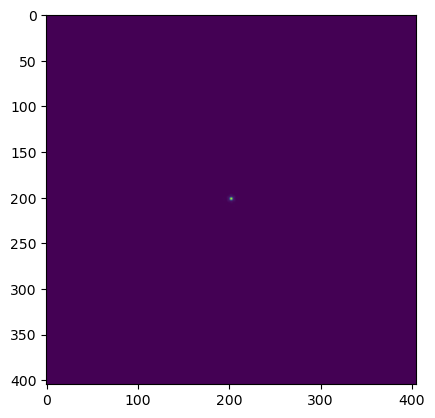

In [9]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])
# has attributes .upper_limit, .psf_photometry, .create_psf_subtracted, .aperature_photometry, .plant_psf

# input_drzs[0] # use this as data and error
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4) # this uses photutils to find PSF

plt.imshow(psf_drz.data)
plt.show()

## Optimize PSF
* Can set range of values to test for xshift and yshift to explore parameter space.
* Number of values tested set by nxs, nyx
* Background_range has not be implemented yet, so have to keep that constant. 
* So, will need to play around with background value in following cell.
* I recommend setting 'plotting' == False if iterations are larger than 10!

In [32]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[-1,1], yshift_range=[-1,1], background_range=[8.5,8.5],
                                                      nxs=10, nys=10, nbkg=1, plotting=False)

# What different attributes does psf_drz contain? .data 
# drz_obs contains .psf_photometry

# Best Fit: xshift = 0.73
# yshift = -0.33
# Background = 2.33

2253it [00:01, 1847.15it/s, +200 | bound: 9 | nc: 1 | ncall: 9838 | eff(%): 25.451 | loglstar:   -inf < -81.323 <    inf | logz: -90.890 +/-  0.208 | dlogz:  0.001 >  0.209] 


[2.51109408]
0.3235708421158301
[0.81251683]
Finished PSF psf_photometry with median residuals of 7.62%


2160it [00:01, 1763.40it/s, +200 | bound: 9 | nc: 1 | ncall: 10047 | eff(%): 23.967 | loglstar:   -inf < -68.681 <    inf | logz: -77.784 +/-  0.202 | dlogz:  0.001 >  0.209]


[2.17834691]
0.3235708421158301
[0.70484954]
Finished PSF psf_photometry with median residuals of 7.54%


2254it [00:01, 1842.80it/s, +200 | bound: 9 | nc: 1 | ncall: 10099 | eff(%): 24.790 | loglstar:   -inf < -56.454 <    inf | logz: -66.028 +/-  0.208 | dlogz:  0.001 >  0.209]


...

[2.14316407]
0.3235708421158301
[0.6934654]
Finished PSF psf_photometry with median residuals of 7.48%


2256it [00:01, 1760.22it/s, +200 | bound: 9 | nc: 1 | ncall: 10079 | eff(%): 24.861 | loglstar:   -inf < -52.101 <    inf | logz: -61.685 +/-  0.208 | dlogz:  0.001 >  0.209]


[2.18332223]
0.3235708421158301
[0.70645941]
Finished PSF psf_photometry with median residuals of 7.38%


2186it [00:01, 1684.36it/s, +200 | bound: 9 | nc: 1 | ncall: 10211 | eff(%): 23.834 | loglstar:   -inf < -54.957 <    inf | logz: -64.191 +/-  0.204 | dlogz:  0.001 >  0.209]

[2.42727523]
0.3235708421158301
[0.78539549]
Finished PSF psf_photometry with median residuals of 7.28%


#### Plot standard deviation for x_shift, y_shift parameter space
* plots the standard deviation for each iteration of the residual of smoothed background for pixel space around SN target
* does not address background, so need to do that manually?
* Change 's' marker size to fill space inbetween.
* Want to minimize the standard deviation, so look for global minimum in color map.
* If you aren't seeing a clear minimum in both x & y, expand search range above ^

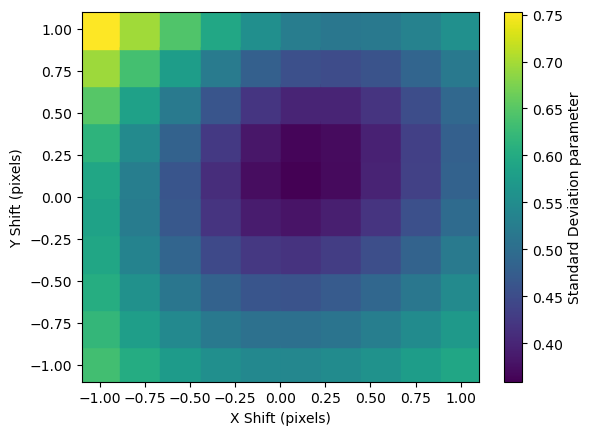

In [33]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')


#### Grab indices where stddev is minimum
* works for multiple varying parameters
* also plot the standard deviation as a function of the iterations (visual check)

Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.3590263596761377
x_shift:  0.11111111111111116 y_shift:  0.11111111111111116
background:  8.5


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

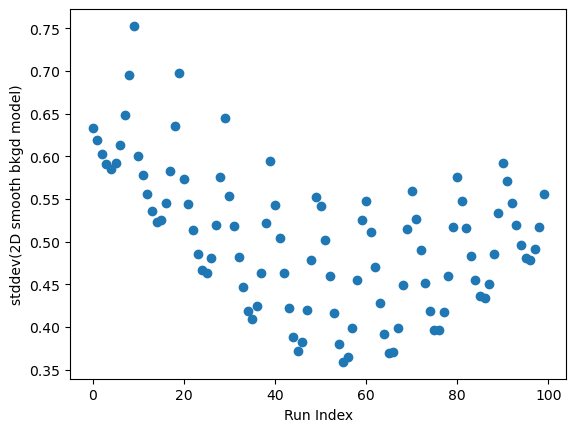

In [34]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

### Re-run with optimized parameters + fit background value!
* here, is where you can play with background value to see what looks right!

2304it [00:01, 1813.96it/s, +200 | bound: 9 | nc: 1 | ncall: 10218 | eff(%): 24.995 | loglstar:   -inf < -28.218 <    inf | logz: -38.044 +/-  0.211 | dlogz:  0.001 >  0.209]   


[1.78605903]
0.3235708421158301
[0.57791662]
Finished PSF psf_photometry with median residuals of 7.58%


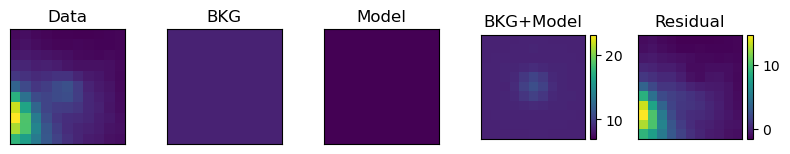

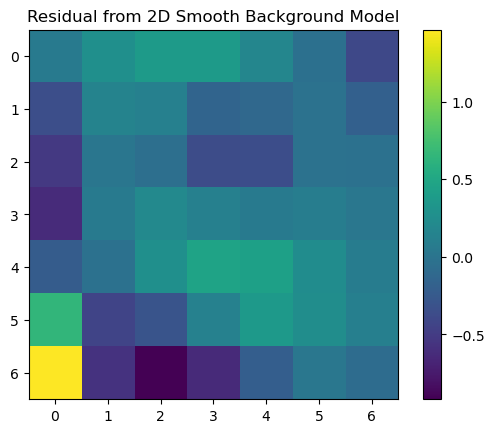

In [35]:
# stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
#                                                       xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
#                                                       yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
#                                                       background_range=[back_ground[min_ind],back_ground[min_ind]],
#                                                       nxs=1, nys=1, nbkg=1, plotting=True)

# Optimized params
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[0.11,0.11], 
                                                      yshift_range=[-0.11,-0.11], 
                                                      background_range=[8.5,8.5],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

## Finally run photometry now that parameters are optimized

In [36]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 8.5,
                            fit_bkg=False,
                            fit_centroid=False, 
                            fit_flux=True,
                            centroidx_shift=0.11,
                            centroidy_shift=-0.11,
                            psf_method='nest',
                            center_weight=25,npoints=200)



2190it [00:01, 1781.44it/s, +200 | bound: 9 | nc: 1 | ncall: 10076 | eff(%): 24.200 | loglstar:   -inf < -28.218 <    inf | logz: -37.472 +/-  0.204 | dlogz:  0.001 >  0.209]

[1.74767987]
0.3235708421158301
[0.56549825]
Finished PSF psf_photometry with median residuals of 7.58%


## Test with PhotUtils error comparison

#### Print magnitude and error

In [37]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra         ...                    exp                    
------------------ ... ------------------------------------------
53.381753970123604 ... jw02107-o003_t003_miri_f770w_jhat_i2d.fits
       mag               magerr      
------------------ ------------------
21.665315071877625 0.0679284764870934
        flux        
--------------------
7.83202330794928e-12
      fluxerr       
--------------------
5.05659359597768e-13


#### Calculate Flux from magnitudes found

In [38]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  7.832023307949303e-06
FLUX ERROR [Jy] =  4.900061440236487e-07


# MIRI F1000W

In [39]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F1000W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F1000W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F1000W', 'F1000W', 'F1000W', 'F1000W', 'F1000W', 'F1000W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_05101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_05101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00001_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

### Run PSF fit

2025-11-04 10:31:45,647 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 10:31:45,648 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 10:31:45,649 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 10:31:45,649 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 10:31:45,650 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 10:31:45,650 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 10:31:45,651 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 10:31:45,745 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 10:31:45,750 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

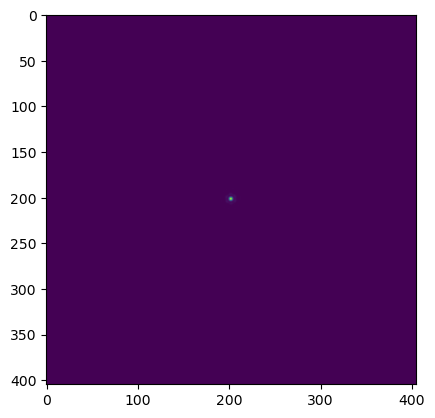

In [41]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])

psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

In [70]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[-1.5,1.5], yshift_range=[-0.5,0.5], background_range=[16.5,16.5],
                                                      nxs=10, nys=10, nbkg=1, plotting=False)

# Best Fit: X shift = 0.42, Y shift = -0.4, background = 0.77

2093it [00:01, 1798.12it/s, +200 | bound: 8 | nc: 1 | ncall: 9776 | eff(%): 23.945 | loglstar:   -inf < -1001.519 <    inf | logz: -1010.292 +/-  0.198 | dlogz:  0.001 >  0.209]


[3.84086204]
0.3235708421158301
[1.24279096]
Finished PSF psf_photometry with median residuals of 0.02%


2088it [00:01, 1827.23it/s, +200 | bound: 8 | nc: 1 | ncall: 9377 | eff(%): 24.932 | loglstar:   -inf < -984.648 <    inf | logz: -993.396 +/-  0.198 | dlogz:  0.001 >  0.209]  


[3.85836905]
0.3235708421158301
[1.24845572]
Finished PSF psf_photometry with median residuals of -0.03%


2090it [00:01, 1813.46it/s, +200 | bound: 8 | nc: 1 | ncall: 9570 | eff(%): 24.440 | loglstar:   -inf < -969.864 <    inf | logz: -978.622 +/-  0.198 | dlogz:  0.001 >  0.209]  


...

[2.52404982]
0.3235708421158301
[0.81670893]
Finished PSF psf_photometry with median residuals of -0.36%


2146it [00:01, 1682.00it/s, +200 | bound: 9 | nc: 1 | ncall: 9839 | eff(%): 24.339 | loglstar:   -inf < -101.409 <    inf | logz: -110.446 +/-  0.201 | dlogz:  0.001 >  0.209]


[2.60943937]
0.3235708421158301
[0.8443385]
Finished PSF psf_photometry with median residuals of -0.44%


2145it [00:01, 1689.92it/s, +200 | bound: 9 | nc: 1 | ncall: 9689 | eff(%): 24.713 | loglstar:   -inf < -109.538 <    inf | logz: -118.569 +/-  0.201 | dlogz:  0.001 >  0.209]

[2.73098836]
0.3235708421158301
[0.8836682]
Finished PSF psf_photometry with median residuals of -0.52%


Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.27792623924853727
x_shift:  0.833333333333333 y_shift:  0.16666666666666663
background:  16.5


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

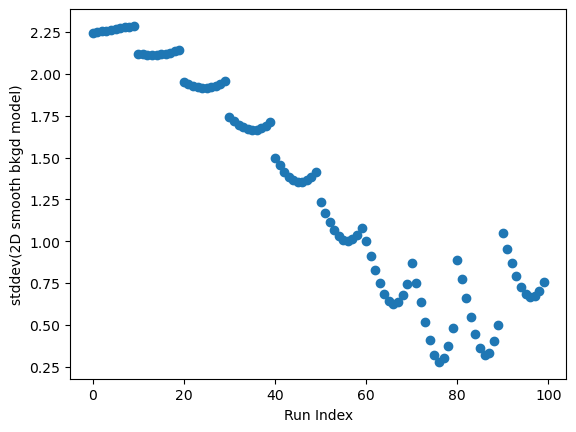

In [71]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2183it [00:01, 1671.89it/s, +200 | bound: 9 | nc: 1 | ncall: 9692 | eff(%): 25.105 | loglstar:   -inf < -52.190 <    inf | logz: -61.409 +/-  0.204 | dlogz:  0.001 >  0.209] 


[2.34260856]
0.3235708421158301
[0.75799982]
Finished PSF psf_photometry with median residuals of 0.21%


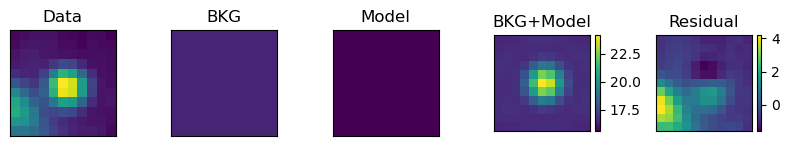

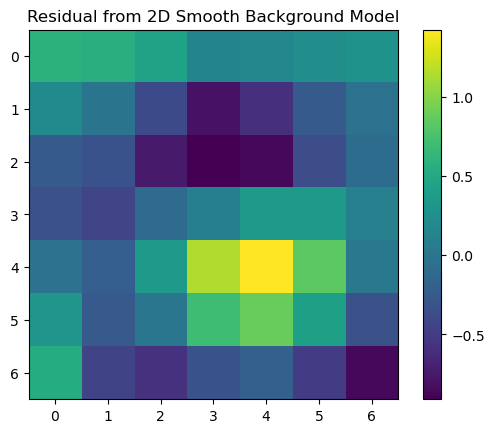

In [94]:
# stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
#                                                       xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
#                                                       yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
#                                                       background_range=[back_ground[min_ind],back_ground[min_ind]],
#                                                       nxs=1, nys=1, nbkg=1, plotting=True)

stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[0.833,0.833], 
                                                      yshift_range=[-0.166,-0.166], 
                                                      background_range=[16.5, 16.5],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [95]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra         ...                     exp                    
------------------ ... -------------------------------------------
53.381726287497855 ... jw02107-o003_t003_miri_f1000w_jhat_i2d.fits
       mag                magerr       
------------------ --------------------
19.980374035552778 0.019725082858381617


#### Calculate Flux

In [96]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  3.697007961094678e-05
FLUX ERROR [Jy] =  6.71652912015901e-07


# MIRI F1130W

In [97]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F1130W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F1130W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs


['F1130W', 'F1130W', 'F1130W', 'F1130W', 'F1130W', 'F1130W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_07101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_07101_00003_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1130w_jhat_i2d.fits']

2025-11-04 11:43:38,515 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 11:43:38,516 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 11:43:38,518 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 11:43:38,518 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 11:43:38,519 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 11:43:38,520 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 11:43:38,520 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 11:43:38,623 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 11:43:38,628 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

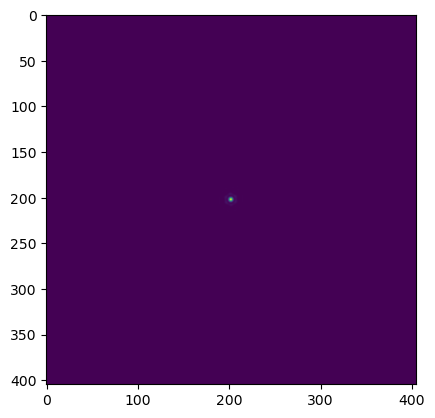

In [98]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

In [107]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[-2,2], yshift_range=[-2,2], background_range=[27,27],
                                                      nxs=10, nys=10, nbkg=1, plotting=False)

# Best fit params X shift = 0.55, Y shift = -0.45, bkg = 2.628


2018it [00:01, 1692.07it/s, +200 | bound: 8 | nc: 1 | ncall: 9298 | eff(%): 24.379 | loglstar:   -inf < -643.975 <    inf | logz: -652.371 +/-  0.193 | dlogz:  0.001 >  0.209]   


[6.30176877]
0.3235708421158301
[2.03906863]
Finished PSF psf_photometry with median residuals of -1.21%


1979it [00:01, 1725.10it/s, +200 | bound: 8 | nc: 1 | ncall: 9240 | eff(%): 24.104 | loglstar:   -inf < -595.960 <    inf | logz: -604.162 +/-  0.191 | dlogz:  0.001 >  0.209]   


[5.92762005]
0.3235708421158301
[1.91800501]
Finished PSF psf_photometry with median residuals of -1.24%


2062it [00:01, 1727.76it/s, +200 | bound: 8 | nc: 1 | ncall: 10007 | eff(%): 23.065 | loglstar:   -inf < -555.799 <    inf | logz: -564.414 +/-  0.196 | dlogz:  0.001 >  0.209] 


...

[5.29579437]
0.3235708421158301
[1.71356464]
Finished PSF psf_photometry with median residuals of -2.26%


2018it [00:01, 1694.79it/s, +200 | bound: 8 | nc: 1 | ncall: 9730 | eff(%): 23.274 | loglstar:   -inf < -408.257 <    inf | logz: -416.654 +/-  0.193 | dlogz:  0.001 >  0.209]   


[6.64627077]
0.3235708421158301
[2.15053943]
Finished PSF psf_photometry with median residuals of -2.77%


1913it [00:01, 1746.15it/s, +200 | bound: 7 | nc: 1 | ncall: 9432 | eff(%): 22.888 | loglstar:   -inf < -512.671 <    inf | logz: -520.545 +/-  0.186 | dlogz:  0.001 >  0.209]   

[8.43664833]
0.3235708421158301
[2.72985341]
Finished PSF psf_photometry with median residuals of -3.41%


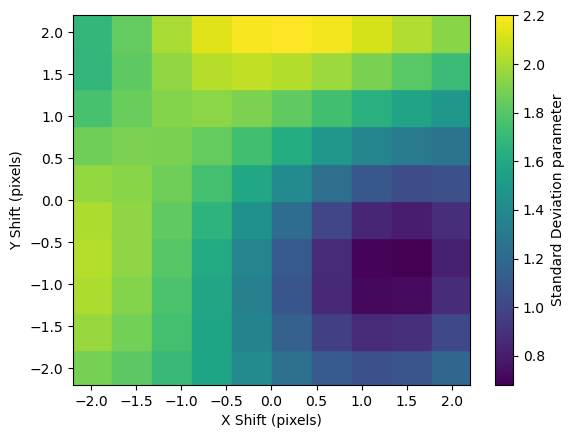

In [108]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')

Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.6808084857326301
x_shift:  1.5555555555555554 y_shift:  -0.6666666666666667
background:  27.0


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

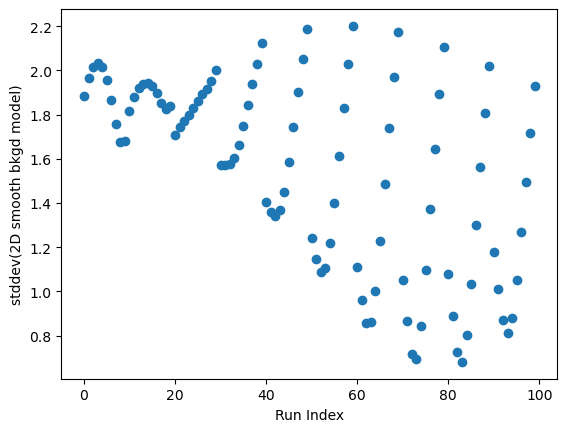

In [109]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2155it [00:01, 1737.91it/s, +200 | bound: 9 | nc: 1 | ncall: 9636 | eff(%): 24.958 | loglstar:   -inf < -74.177 <    inf | logz: -83.257 +/-  0.202 | dlogz:  0.001 >  0.209] 


[2.87426212]
0.3235708421158301
[0.93002741]
Finished PSF psf_photometry with median residuals of 0.60%


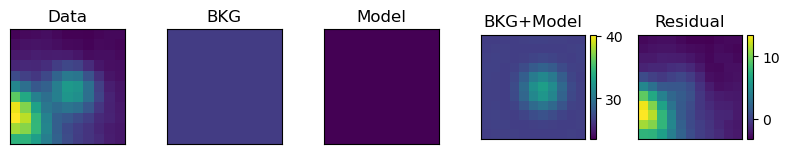

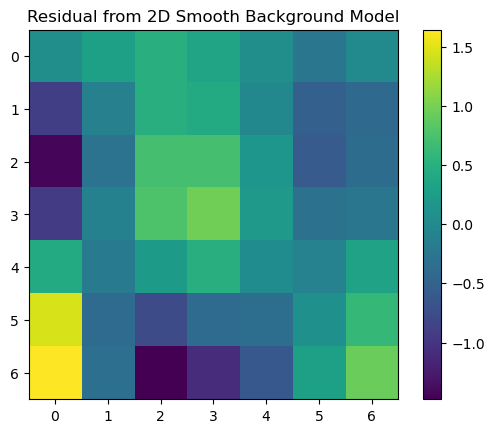

In [113]:
# stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
#                                                       xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
#                                                       yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
#                                                       background_range=[back_ground[min_ind],back_ground[min_ind]],
#                                                       nxs=1, nys=1, nbkg=1, plotting=True)

stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[1.5,1.5], 
                                                      yshift_range=[-0.666,-0.666], 
                                                      background_range=[26.5, 26.5],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [114]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra        ...                     exp                    
----------------- ... -------------------------------------------
53.38169941229118 ... jw02107-o003_t003_miri_f1130w_jhat_i2d.fits
       mag               magerr       
----------------- --------------------
19.96416490910425 0.023798220394587816


#### Calculate Flux

In [115]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  3.7526152260049254e-05
FLUX ERROR [Jy] =  8.225346434352889e-07


# MIRI F2100W

In [116]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F2100W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F2100W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F2100W', 'F2100W', 'F2100W', 'F2100W', 'F2100W', 'F2100W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_09101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_09101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00004_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

### Run PSF fit

2025-11-04 12:34:05,248 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 12:34:05,248 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 12:34:05,249 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 12:34:05,250 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 12:34:05,251 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 12:34:05,251 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 12:34:05,252 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 12:34:05,382 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 12:34:05,387 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

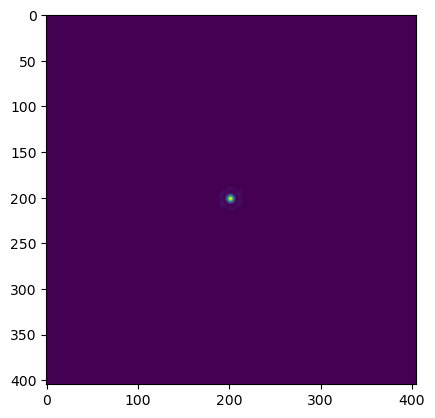

In [117]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])

psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

In [133]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[-2,2], yshift_range=[-2,2], background_range=[235,235],
                                                      nxs=10, nys=10, nbkg=1, plotting=False)

# Best Fit: X Shift = -0.22, Y shift = -0.11, bkg = 4.55

1803it [00:01, 1687.60it/s, +200 | bound: 7 | nc: 1 | ncall: 9048 | eff(%): 22.638 | loglstar:   -inf < -260.775 <    inf | logz: -268.101 +/-  0.179 | dlogz:  0.001 >  0.209]


[11.92228832]
0.3235708421158301
[3.85770487]
Finished PSF psf_photometry with median residuals of -0.82%


1853it [00:01, 1725.13it/s, +200 | bound: 7 | nc: 1 | ncall: 9238 | eff(%): 22.715 | loglstar:   -inf < -221.227 <    inf | logz: -228.800 +/-  0.182 | dlogz:  0.001 >  0.209]


[11.06621432]
0.3235708421158301
[3.58070429]
Finished PSF psf_photometry with median residuals of -0.80%


1944it [00:01, 1778.35it/s, +200 | bound: 7 | nc: 1 | ncall: 9514 | eff(%): 23.019 | loglstar:   -inf < -184.517 <    inf | logz: -192.547 +/-  0.188 | dlogz:  0.001 >  0.209]   


...

[7.15692895]
0.3235708421158301
[2.31577353]
Finished PSF psf_photometry with median residuals of -0.66%


1901it [00:01, 1742.64it/s, +200 | bound: 7 | nc: 1 | ncall: 9320 | eff(%): 23.037 | loglstar:   -inf < -100.843 <    inf | logz: -108.656 +/-  0.186 | dlogz:  0.001 >  0.209]  


[7.41155725]
0.3235708421158301
[2.39816382]
Finished PSF psf_photometry with median residuals of -0.69%


1902it [00:01, 1714.44it/s, +200 | bound: 7 | nc: 1 | ncall: 9668 | eff(%): 22.201 | loglstar:   -inf < -96.970 <    inf | logz: -104.790 +/-  0.186 | dlogz:  0.001 >  0.209]    

[8.43413197]
0.3235708421158301
[2.72903918]
Finished PSF psf_photometry with median residuals of -0.74%


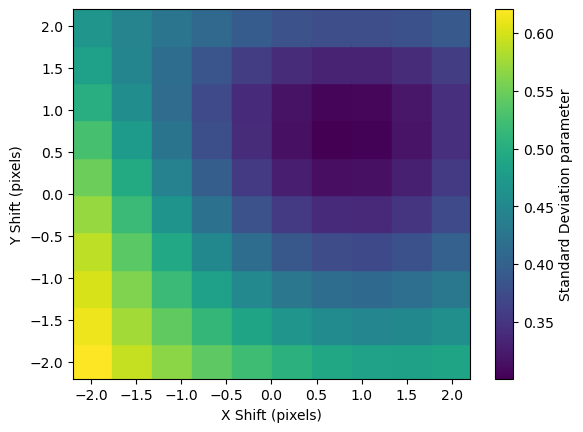

In [134]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')


Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.3006773391289969
x_shift:  0.6666666666666665 y_shift:  0.6666666666666665
background:  235.0


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

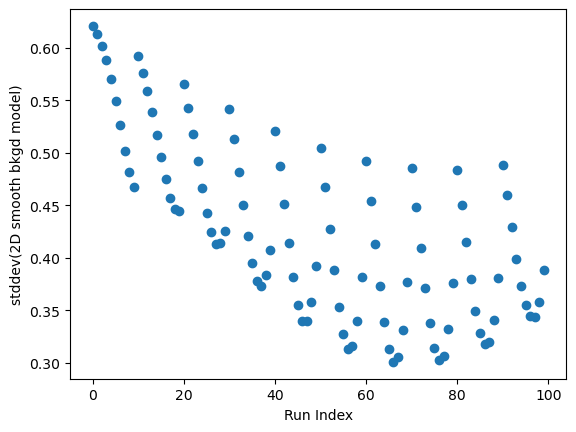

In [135]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2022it [00:01, 1812.24it/s, +200 | bound: 7 | nc: 1 | ncall: 9763 | eff(%): 23.235 | loglstar:   -inf < -31.594 <    inf | logz: -40.010 +/-  0.194 | dlogz:  0.001 >  0.209]     


[6.65710524]
0.3235708421158301
[2.15404515]
Finished PSF psf_photometry with median residuals of 0.69%


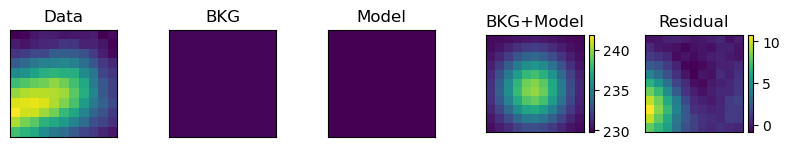

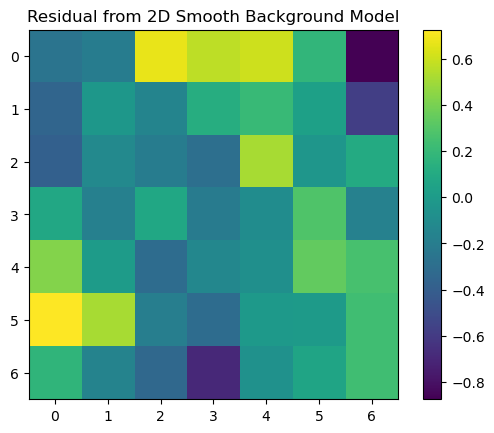

In [137]:
# stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
#                                                       xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
#                                                       yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
#                                                       background_range=[back_ground[min_ind],back_ground[min_ind]],
#                                                       nxs=1, nys=1, nbkg=1, plotting=True)

stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[0.66,0.66], 
                                                      yshift_range=[0.66,0.66], 
                                                      background_range=[230, 230],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [138]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra        ...                     exp                    
----------------- ... -------------------------------------------
53.38173533423675 ... jw02107-o003_t003_miri_f2100w_jhat_i2d.fits
       mag                magerr      
------------------ -------------------
18.324426238932073 0.01223844991707102


#### Calculate Flux

In [139]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  0.0001699141332387663
FLUX ERROR [Jy] =  1.915277026530052e-06


## ----------------------------------------------------------------------------------------
## ----------------------------------------------------------------------------------------

# NIRCAM F200W

### Grab files

In [151]:
# SN 1983V
lvl2 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/*_cal.fits'
lvl3 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/*jhat_i2d.fits'
lvl3_single = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f200w_jhat_i2d.fits'

ra  = '3:33:31.6159' #unit=(u.hourangle,u.deg)) #icrs
dec = '-36:08:55.222' #unit=(u.hourangle,u.deg)) #icrs


In [152]:
files = glob.glob(lvl2) #lvl2
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter_arr

['F200W', 'F2100W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F1000W', 'F770W', 'F200W', 'F1000W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F300M', 'F770W', 'F200W', 'F335M', 'F360M', 'F200W', 'F2100W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F1000W', 'F770W', 'F360M', 'F770W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F2100W', 'F360M', 'F1000W', 'F1130W', 'F200W', 'F2100W', 'F200W', 'F1130W', 'F300M', 'F335M', 'F360M', 'F200W', 'F360M', 'F200W', 'F300M', 'F1000W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F200W', 'F2100W', 'F1130W', 'F300M', 'F2100W', 'F1000W', 'F200W', 'F200W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F360M', 'F200W', 'F200W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F360M', 'F1000W', 'F200W', 'F200W', 'F200W', 'F335M', 'F1000W', 'F2100W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F335M', 'F200W', 'F200W', 'F360M', 'F200W', 'F1130W', 'F21

['F200W',
 'F2100W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F1000W',
 'F770W',
 'F200W',
 'F1000W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F300M',
 'F770W',
 'F200W',
 'F335M',
 'F360M',
 'F200W',
 'F2100W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F1000W',
 'F770W',
 'F360M',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F2100W',
 'F360M',
 'F1000W',
 'F1130W',
 'F200W',
 'F2100W',
 'F200W',
 'F1130W',
 'F300M',
 'F335M',
 'F360M',
 'F200W',
 'F360M',
 'F200W',
 'F300M',
 'F1000W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F2100W',
 'F1130W',
 'F300M',
 'F2100W',
 'F1000W',
 'F200W',
 'F200W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F360M',
 'F200W',
 'F200W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F360M',
 'F1000W',
 'F200W',
 'F200W',
 'F200W',
 'F335M',
 'F1000W',
 'F2100W',
 'F200W'

### Centroid

In [153]:
f = fits.open(lvl3_single)
data = f[1].data
w = WCS(f[1].header)

initial_location = SkyCoord(ra,dec,unit=(u.hourangle,u.deg)) #icrs
print(initial_location)

x_init, y_init = wcs.utils.skycoord_to_pixel(initial_location,w)
print(x_init, y_init)

x_cent, y_cent = centroid_sources(data, x_init, y_init, box_size=3, centroid_func=centroid_2dg)
print(x_cent,y_cent)

centered_location = wcs.utils.pixel_to_skycoord(x_cent[0],y_cent[0],w)
print(centered_location)

sn_location = centered_location
print(sn_location)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
2590.898681841159 5376.109602703007
[2590.85447829] [5375.4346242]
<SkyCoord (ICRS): (ra, dec) in deg
    (53.3817399, -36.14867154)>
<SkyCoord (ICRS): (ra, dec) in deg
    (53.3817399, -36.14867154)>


### Now run through filters

In [154]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F200W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F200W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcb2_cal.fits',
 '/Users/s

#### Run PSF

2025-11-04 13:10:39,205 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 13:10:39,206 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 13:10:39,207 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 13:10:39,208 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 13:10:39,208 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 13:10:39,209 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 13:10:39,209 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 13:10:39,325 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 13:10:39,331 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

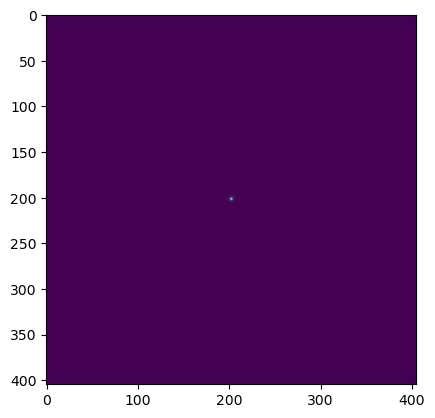

In [155]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

2064it [00:01, 1876.56it/s, +200 | bound: 8 | nc: 1 | ncall: 9342 | eff(%): 24.765 | loglstar:   -inf < -5.024 <    inf | logz: -13.652 +/-  0.196 | dlogz:  0.001 >  0.209]      


[3.90586651]
0.31592907602473186
[1.2339768]
Finished PSF psf_photometry with median residuals of -2.57%


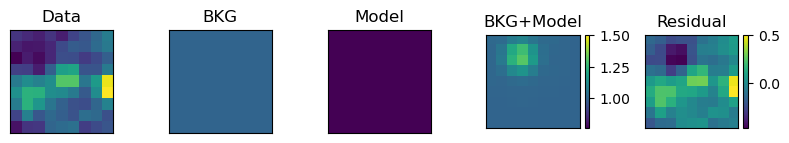

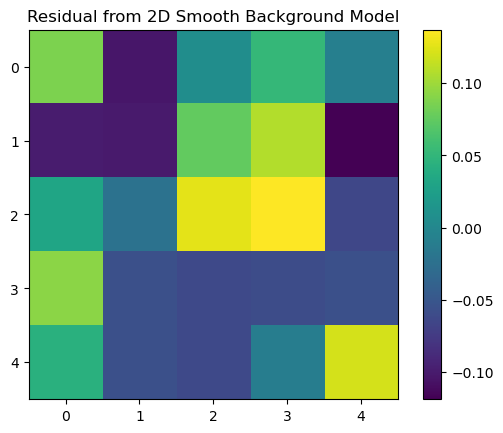

2164it [00:01, 1857.76it/s, +200 | bound: 9 | nc: 1 | ncall: 9454 | eff(%): 25.546 | loglstar:   -inf < -4.731 <    inf | logz: -13.854 +/-  0.203 | dlogz:  0.001 >  0.209]  


[2.48629696]
0.31592907602473186
[0.7854935]
Finished PSF psf_photometry with median residuals of -2.62%


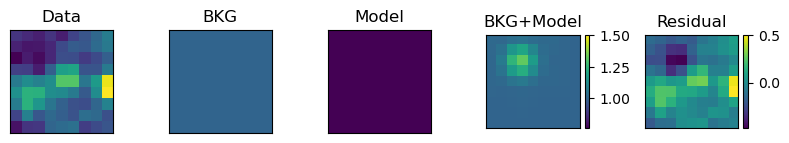

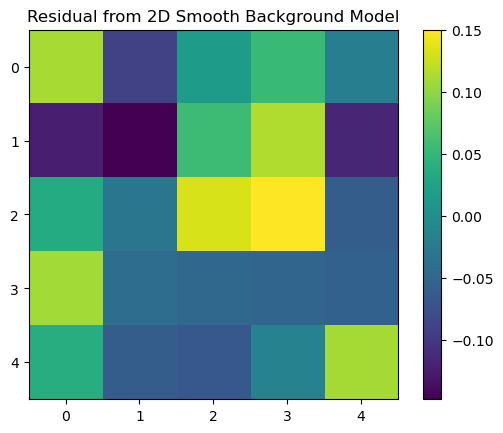

2277it [00:01, 1881.12it/s, +200 | bound: 9 | nc: 1 | ncall: 9933 | eff(%): 25.450 | loglstar:   -inf < -4.307 <    inf | logz: -13.997 +/-  0.209 | dlogz:  0.001 >  0.209]  


[1.91314016]
0.31592907602473186
[0.6044166]
Finished PSF psf_photometry with median residuals of -2.20%


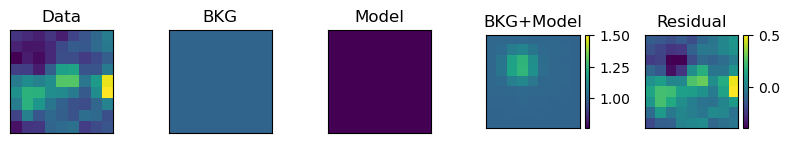

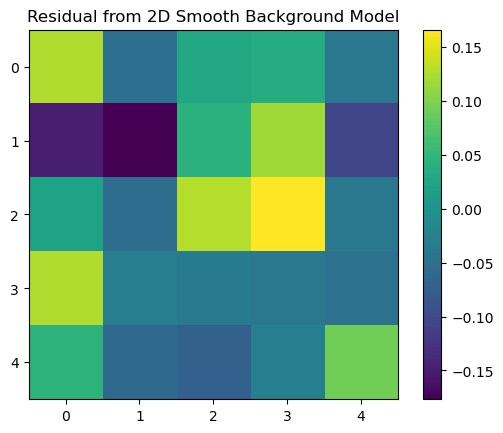

2270it [00:01, 1867.46it/s, +200 | bound: 9 | nc: 1 | ncall: 9994 | eff(%): 25.220 | loglstar:   -inf < -3.760 <    inf | logz: -13.416 +/-  0.209 | dlogz:  0.001 >  0.209]  


[1.5004742]
0.31592907602473186
[0.47404343]
Finished PSF psf_photometry with median residuals of -2.18%


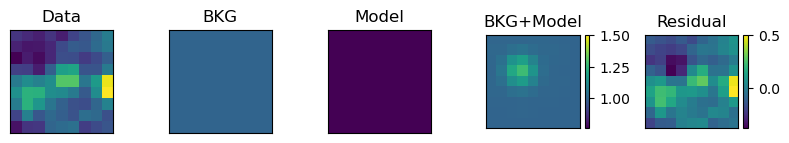

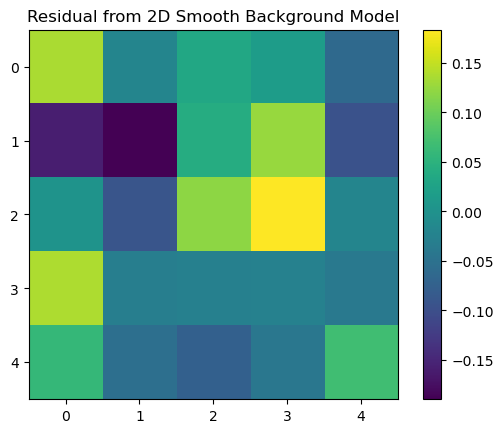

2279it [00:01, 1897.02it/s, +200 | bound: 9 | nc: 1 | ncall: 9974 | eff(%): 25.363 | loglstar:   -inf < -3.230 <    inf | logz: -12.928 +/-  0.209 | dlogz:  0.001 >  0.209]  


[1.32930442]
0.31592907602473186
[0.41996592]
Finished PSF psf_photometry with median residuals of -2.24%


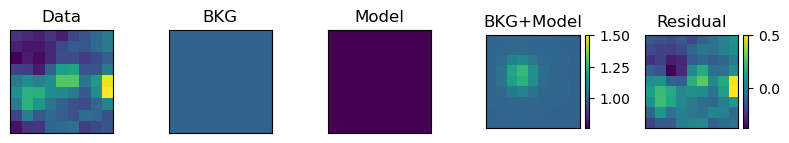

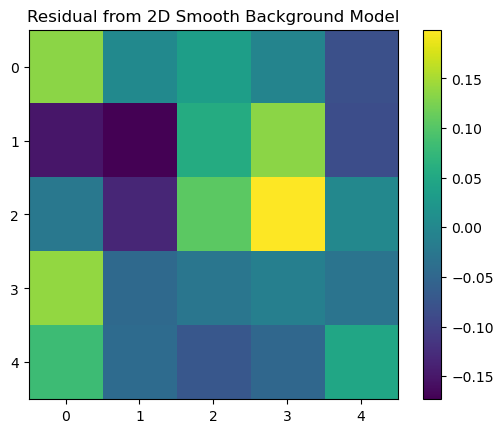

2335it [00:01, 1829.56it/s, +200 | bound: 10 | nc: 1 | ncall: 10040 | eff(%): 25.762 | loglstar:   -inf < -2.916 <    inf | logz: -12.893 +/-  0.213 | dlogz:  0.001 >  0.209]


[1.34355008]
0.31592907602473186
[0.42446654]
Finished PSF psf_photometry with median residuals of -2.18%


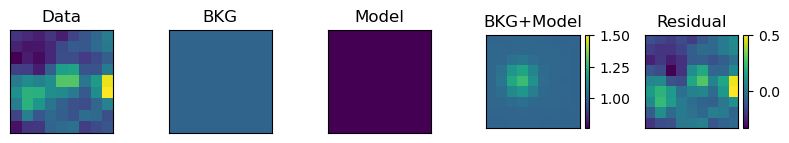

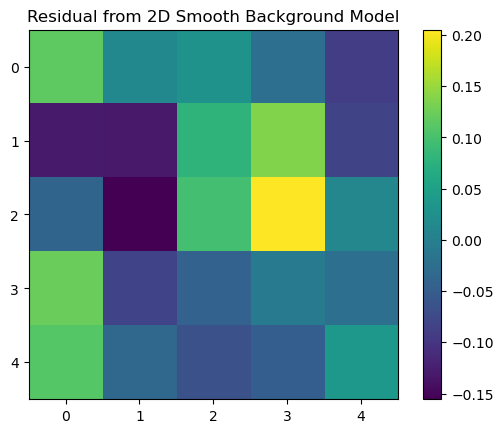

2351it [00:01, 1901.43it/s, +200 | bound: 9 | nc: 1 | ncall: 10581 | eff(%): 24.574 | loglstar:   -inf < -2.872 <    inf | logz: -12.931 +/-  0.214 | dlogz:  0.001 >  0.209] 


[1.22169547]
0.31592907602473186
[0.38596912]
Finished PSF psf_photometry with median residuals of -2.31%


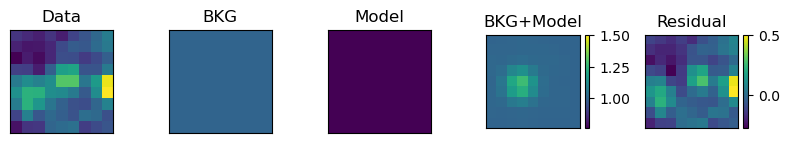

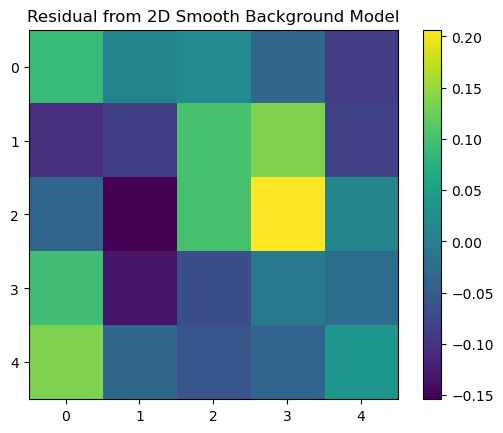

2308it [00:01, 1857.25it/s, +200 | bound: 9 | nc: 1 | ncall: 10211 | eff(%): 25.052 | loglstar:   -inf < -3.102 <    inf | logz: -12.945 +/-  0.211 | dlogz:  0.001 >  0.209] 


[1.3192128]
0.31592907602473186
[0.41677768]
Finished PSF psf_photometry with median residuals of -2.31%


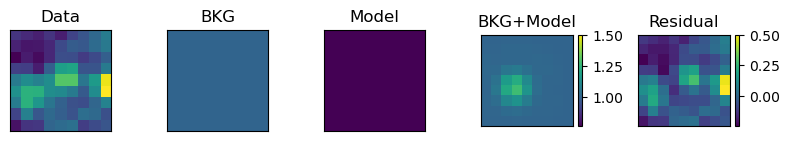

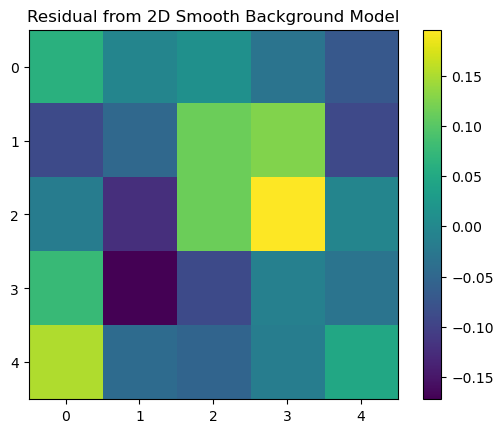

2247it [00:01, 1872.26it/s, +200 | bound: 9 | nc: 1 | ncall: 9856 | eff(%): 25.342 | loglstar:   -inf < -3.502 <    inf | logz: -13.040 +/-  0.207 | dlogz:  0.001 >  0.209]  


[1.64679318]
0.31592907602473186
[0.52026985]
Finished PSF psf_photometry with median residuals of -2.63%


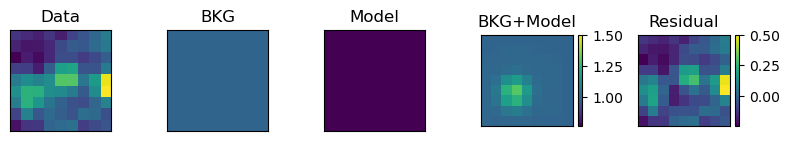

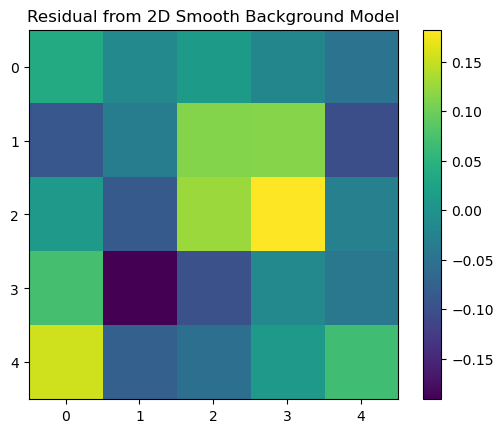

2192it [00:01, 1869.11it/s, +200 | bound: 9 | nc: 1 | ncall: 9463 | eff(%): 25.823 | loglstar:   -inf < -3.988 <    inf | logz: -13.254 +/-  0.204 | dlogz:  0.001 >  0.209]  


[2.15590398]
0.31592907602473186
[0.68111275]
Finished PSF psf_photometry with median residuals of -2.99%


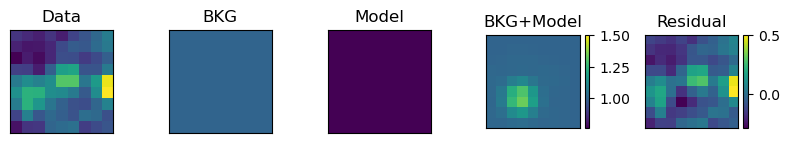

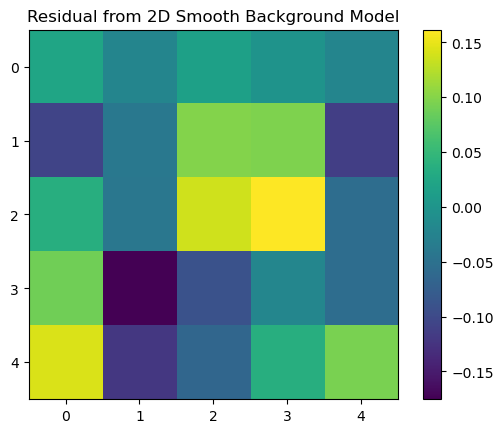

2196it [00:01, 1859.24it/s, +200 | bound: 9 | nc: 1 | ncall: 9630 | eff(%): 25.408 | loglstar:   -inf < -4.833 <    inf | logz: -14.117 +/-  0.204 | dlogz:  0.001 >  0.209]  


[3.29129667]
0.31592907602473186
[1.03981632]
Finished PSF psf_photometry with median residuals of -2.69%


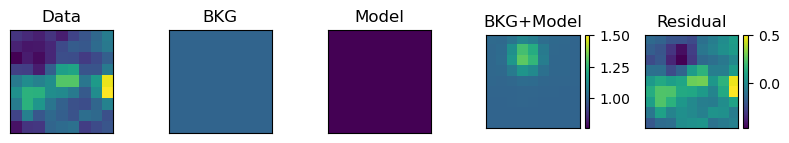

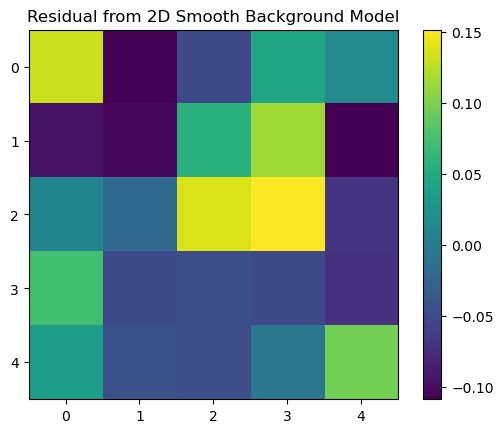

2271it [00:01, 1866.01it/s, +200 | bound: 9 | nc: 1 | ncall: 9974 | eff(%): 25.281 | loglstar:   -inf < -4.366 <    inf | logz: -14.025 +/-  0.209 | dlogz:  0.001 >  0.209]  


[2.20532682]
0.31592907602473186
[0.69672686]
Finished PSF psf_photometry with median residuals of -2.49%


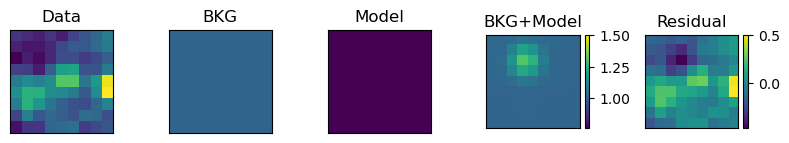

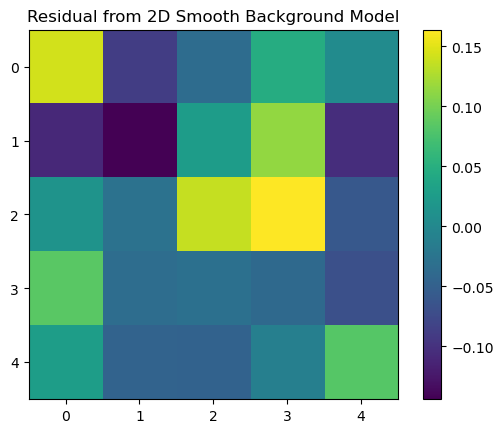

2421it [00:01, 1929.65it/s, +200 | bound: 9 | nc: 1 | ncall: 10655 | eff(%): 25.069 | loglstar:   -inf < -3.736 <    inf | logz: -14.146 +/-  0.218 | dlogz:  0.001 >  0.209]    


[1.60722216]
0.31592907602473186
[0.50776821]
Finished PSF psf_photometry with median residuals of -2.27%


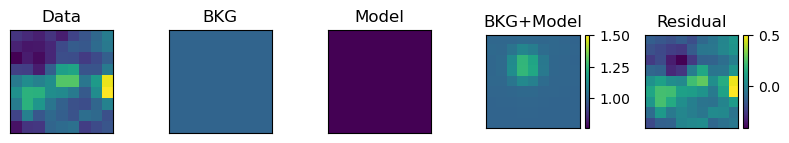

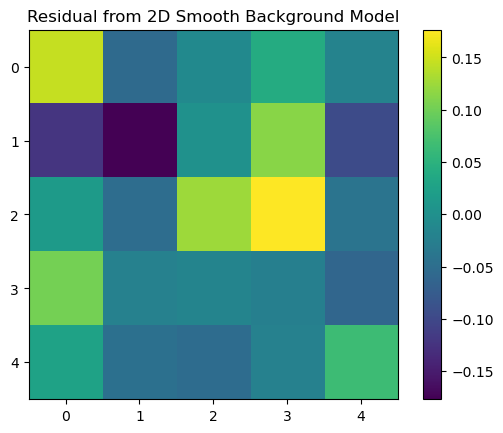

2251it [00:01, 1847.17it/s, +200 | bound: 9 | nc: 1 | ncall: 9830 | eff(%): 25.452 | loglstar:   -inf < -2.982 <    inf | logz: -12.539 +/-  0.208 | dlogz:  0.001 >  0.209]     


[1.27779849]
0.31592907602473186
[0.4036937]
Finished PSF psf_photometry with median residuals of -2.30%


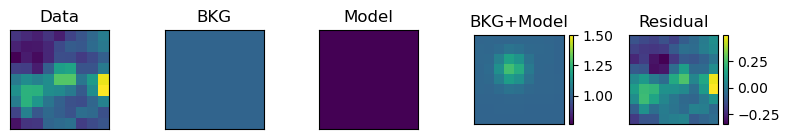

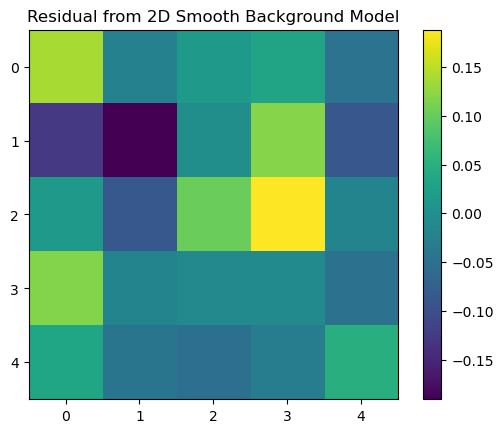

2336it [00:01, 1809.17it/s, +200 | bound: 10 | nc: 1 | ncall: 10001 | eff(%): 25.875 | loglstar:   -inf < -2.306 <    inf | logz: -12.291 +/-  0.213 | dlogz:  0.001 >  0.209]


[1.07998483]
0.31592907602473186
[0.34119861]
Finished PSF psf_photometry with median residuals of -2.23%


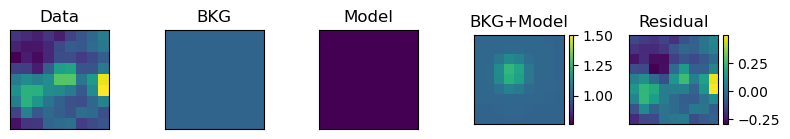

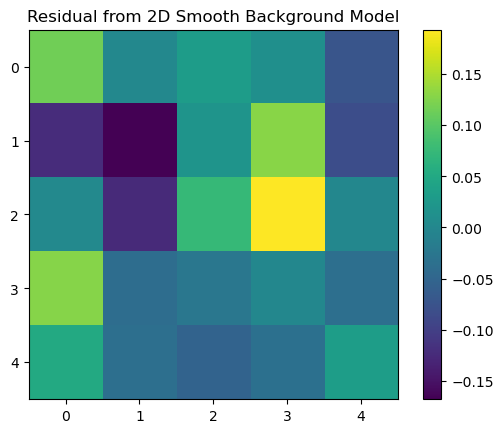

2432it [00:01, 1847.82it/s, +200 | bound: 10 | nc: 1 | ncall: 10472 | eff(%): 25.623 | loglstar:   -inf < -1.961 <    inf | logz: -12.422 +/-  0.218 | dlogz:  0.001 >  0.209]   


[1.0368319]
0.31592907602473186
[0.32756535]
Finished PSF psf_photometry with median residuals of -2.22%


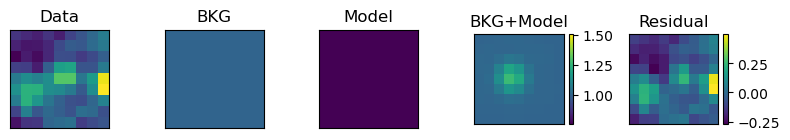

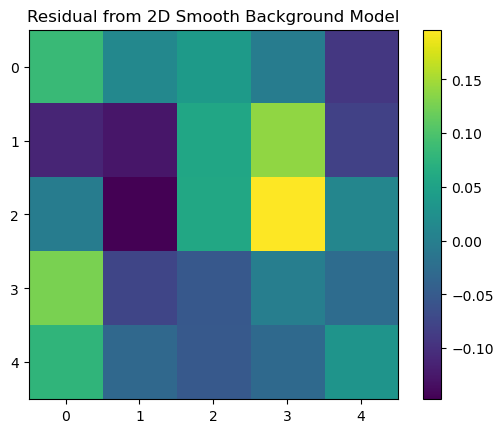

2372it [00:01, 1817.35it/s, +200 | bound: 10 | nc: 1 | ncall: 9985 | eff(%): 26.285 | loglstar:   -inf < -2.008 <    inf | logz: -12.169 +/-  0.215 | dlogz:  0.001 >  0.209]    


[1.07161421]
0.31592907602473186
[0.33855409]
Finished PSF psf_photometry with median residuals of -2.23%


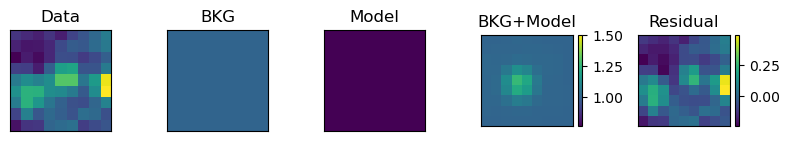

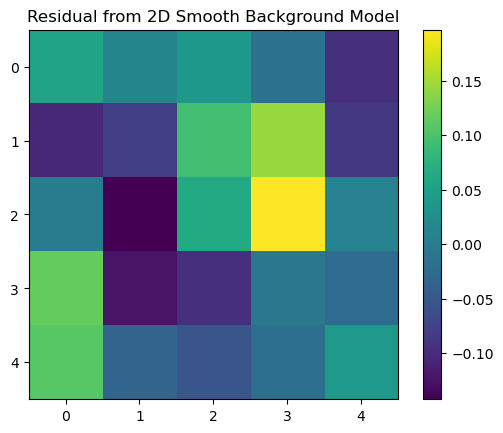

2280it [00:01, 1854.19it/s, +200 | bound: 9 | nc: 1 | ncall: 9898 | eff(%): 25.572 | loglstar:   -inf < -2.425 <    inf | logz: -12.128 +/-  0.209 | dlogz:  0.001 >  0.209]     


[1.14679048]
0.31592907602473186
[0.36230446]
Finished PSF psf_photometry with median residuals of -2.28%


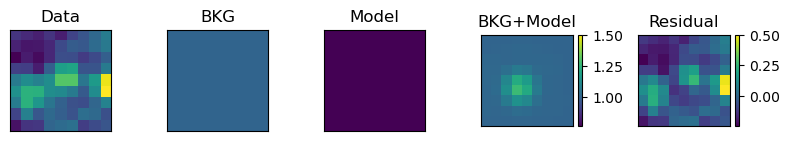

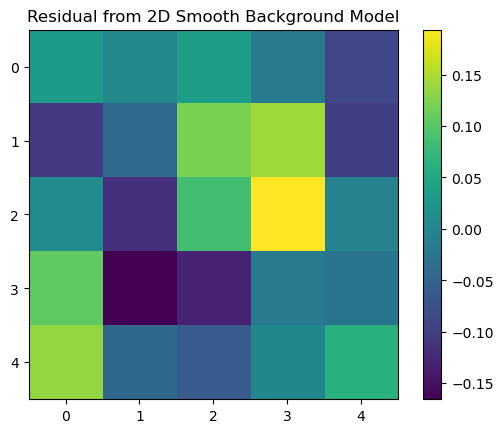

2381it [00:01, 1801.53it/s, +200 | bound: 10 | nc: 1 | ncall: 10208 | eff(%): 25.789 | loglstar:   -inf < -3.054 <    inf | logz: -13.260 +/-  0.215 | dlogz:  0.001 >  0.209]


[1.33655675]
0.31592907602473186
[0.42225714]
Finished PSF psf_photometry with median residuals of -2.44%


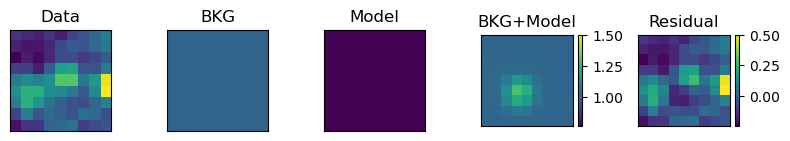

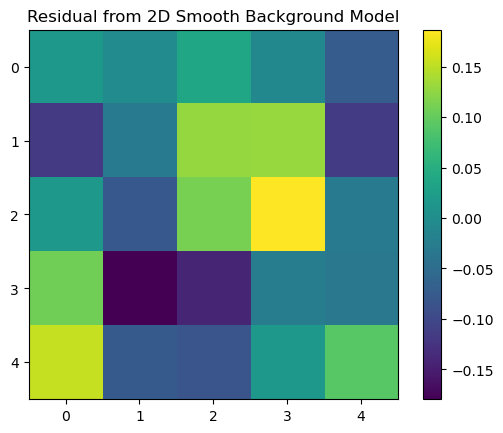

2181it [00:01, 1768.53it/s, +200 | bound: 9 | nc: 1 | ncall: 9566 | eff(%): 25.422 | loglstar:   -inf < -3.775 <    inf | logz: -12.984 +/-  0.204 | dlogz:  0.001 >  0.209]  


[1.65870261]
0.31592907602473186
[0.52403238]
Finished PSF psf_photometry with median residuals of -2.65%


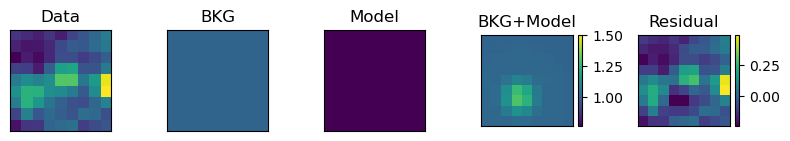

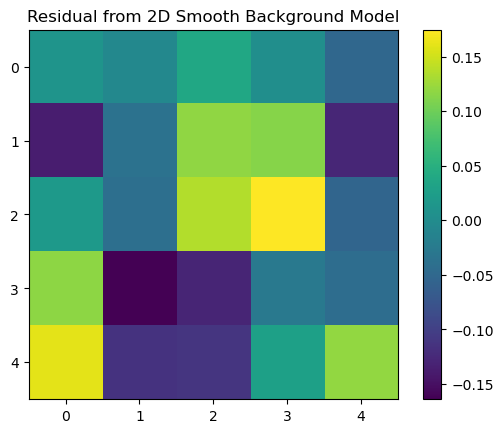

2185it [00:01, 1782.42it/s, +200 | bound: 9 | nc: 1 | ncall: 9959 | eff(%): 24.439 | loglstar:   -inf < -4.612 <    inf | logz: -13.841 +/-  0.204 | dlogz:  0.001 >  0.209]  


[3.05049547]
0.31592907602473186
[0.96374022]
Finished PSF psf_photometry with median residuals of -2.90%


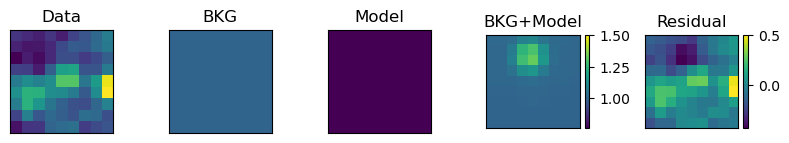

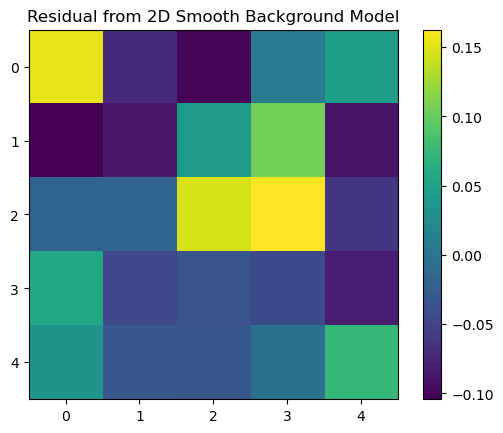

2289it [00:01, 1860.23it/s, +200 | bound: 9 | nc: 1 | ncall: 10206 | eff(%): 24.875 | loglstar:   -inf < -3.969 <    inf | logz: -13.718 +/-  0.210 | dlogz:  0.001 >  0.209] 


[1.93267447]
0.31592907602473186
[0.61058806]
Finished PSF psf_photometry with median residuals of -2.76%


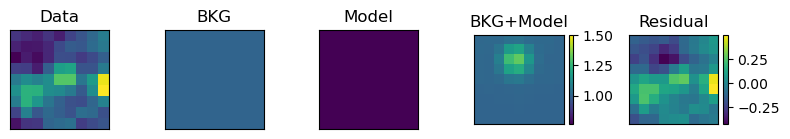

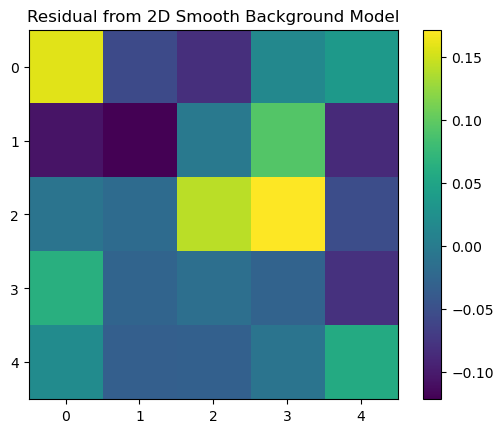

2371it [00:01, 1845.20it/s, +200 | bound: 9 | nc: 1 | ncall: 10465 | eff(%): 25.046 | loglstar:   -inf < -3.144 <    inf | logz: -13.301 +/-  0.215 | dlogz:  0.001 >  0.209]    


[1.37580368]
0.31592907602473186
[0.43465639]
Finished PSF psf_photometry with median residuals of -2.62%


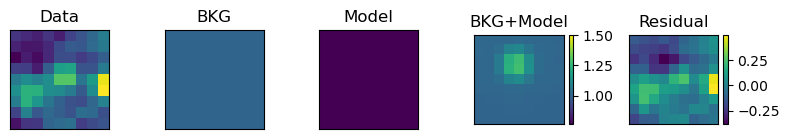

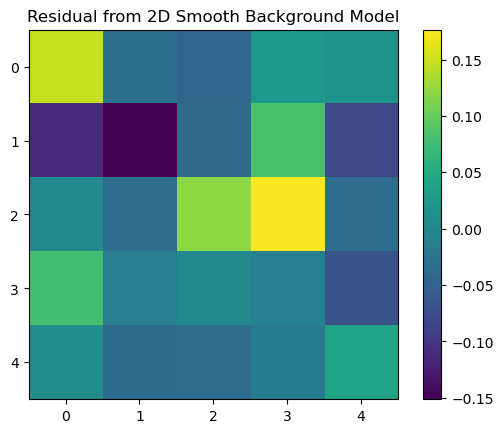

2345it [00:01, 1753.49it/s, +200 | bound: 10 | nc: 1 | ncall: 10098 | eff(%): 25.712 | loglstar:   -inf < -2.208 <    inf | logz: -12.234 +/-  0.213 | dlogz:  0.001 >  0.209]   


[1.12313804]
0.31592907602473186
[0.35483196]
Finished PSF psf_photometry with median residuals of -2.51%


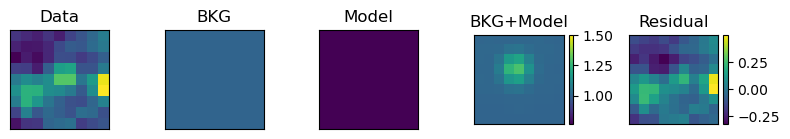

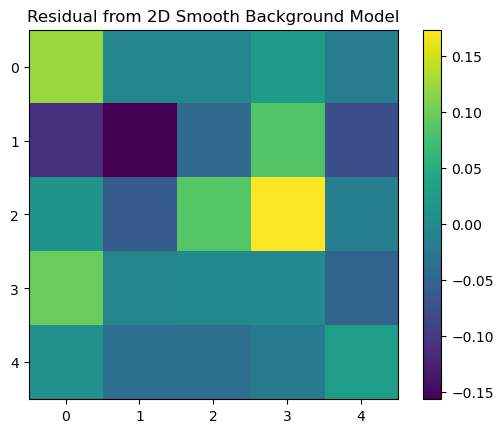

2387it [00:01, 1838.41it/s, +200 | bound: 10 | nc: 1 | ncall: 9758 | eff(%): 27.066 | loglstar:   -inf < -1.420 <    inf | logz: -11.657 +/-  0.216 | dlogz:  0.001 >  0.209]    


[1.02276864]
0.31592907602473186
[0.32312235]
Finished PSF psf_photometry with median residuals of -2.36%


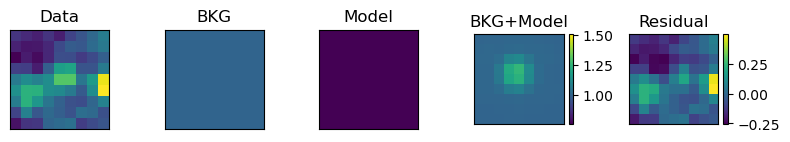

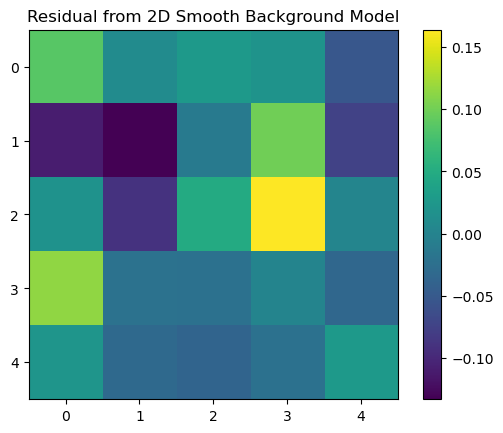

2363it [00:01, 1763.58it/s, +200 | bound: 10 | nc: 1 | ncall: 9962 | eff(%): 26.255 | loglstar:   -inf < -1.072 <    inf | logz: -11.190 +/-  0.214 | dlogz:  0.001 >  0.209]    


[0.91726522]
0.31592907602473186
[0.28979075]
Finished PSF psf_photometry with median residuals of -2.34%


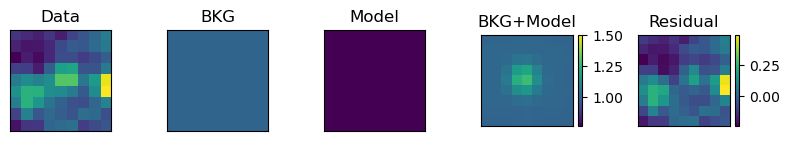

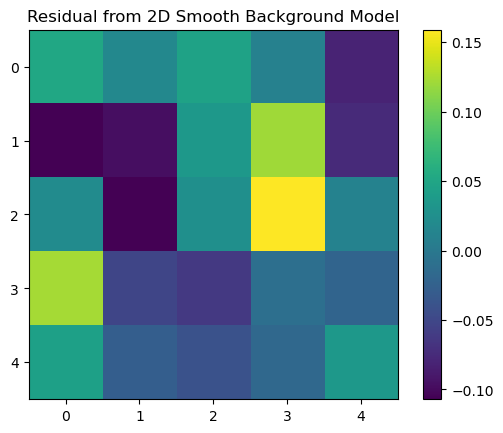

2384it [00:01, 1799.83it/s, +200 | bound: 10 | nc: 1 | ncall: 9946 | eff(%): 26.513 | loglstar:   -inf < -1.220 <    inf | logz: -11.440 +/-  0.216 | dlogz:  0.001 >  0.209]    


[0.92492525]
0.31592907602473186
[0.29221078]
Finished PSF psf_photometry with median residuals of -2.33%


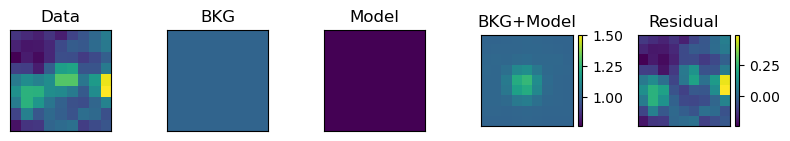

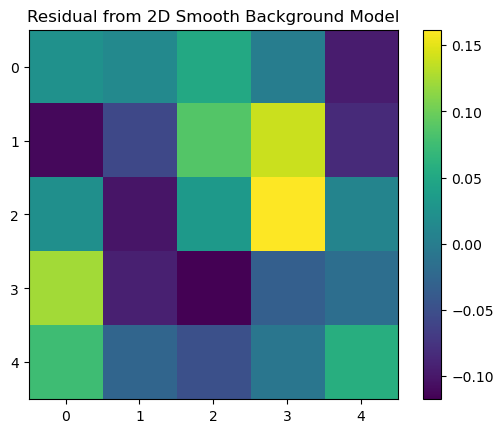

2363it [00:01, 1774.88it/s, +200 | bound: 10 | nc: 1 | ncall: 10232 | eff(%): 25.548 | loglstar:   -inf < -1.821 <    inf | logz: -11.940 +/-  0.214 | dlogz:  0.001 >  0.209]   


[1.02615096]
0.31592907602473186
[0.32419092]
Finished PSF psf_photometry with median residuals of -2.34%


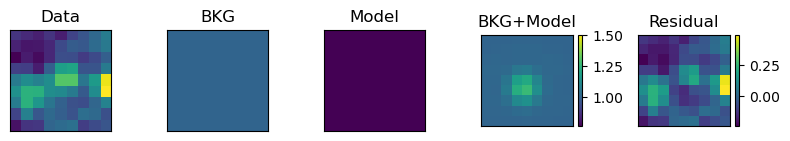

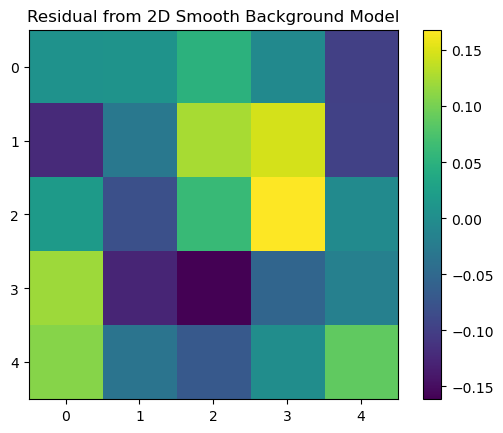

2330it [00:01, 1809.49it/s, +200 | bound: 10 | nc: 1 | ncall: 9858 | eff(%): 26.196 | loglstar:   -inf < -2.662 <    inf | logz: -12.615 +/-  0.212 | dlogz:  0.001 >  0.209] 


[1.17311117]
0.31592907602473186
[0.37061993]
Finished PSF psf_photometry with median residuals of -2.50%


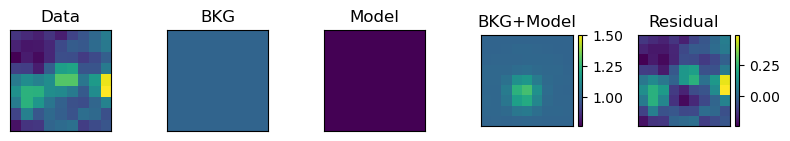

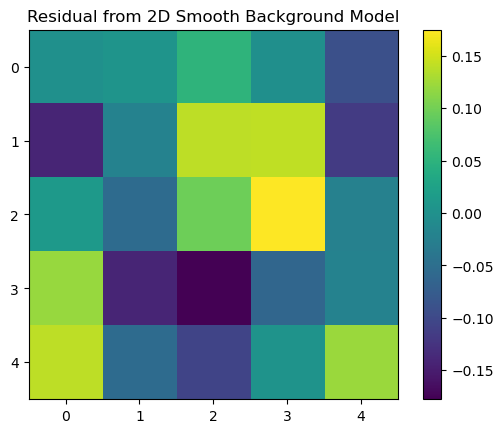

2253it [00:01, 1830.15it/s, +200 | bound: 9 | nc: 1 | ncall: 10088 | eff(%): 24.808 | loglstar:   -inf < -3.591 <    inf | logz: -13.159 +/-  0.208 | dlogz:  0.001 >  0.209] 


[1.54453811]
0.31592907602473186
[0.4879645]
Finished PSF psf_photometry with median residuals of -2.47%


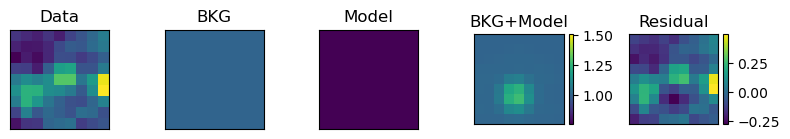

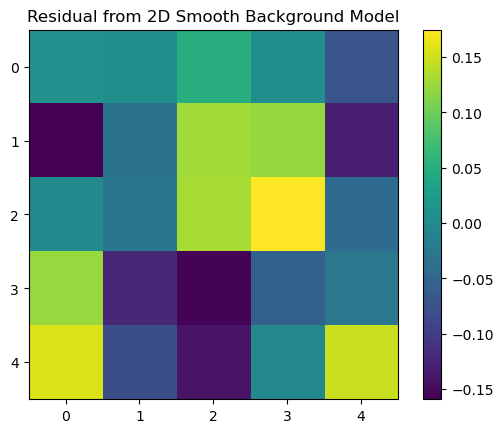

2195it [00:01, 1783.79it/s, +200 | bound: 9 | nc: 1 | ncall: 9803 | eff(%): 24.940 | loglstar:   -inf < -4.423 <    inf | logz: -13.700 +/-  0.204 | dlogz:  0.001 >  0.209]  


[2.94187444]
0.31592907602473186
[0.92942367]
Finished PSF psf_photometry with median residuals of -3.31%


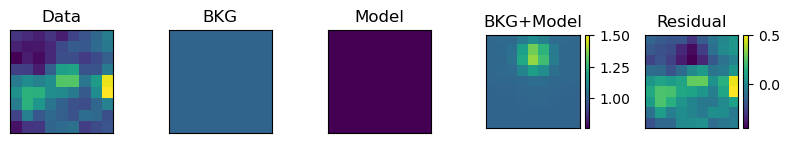

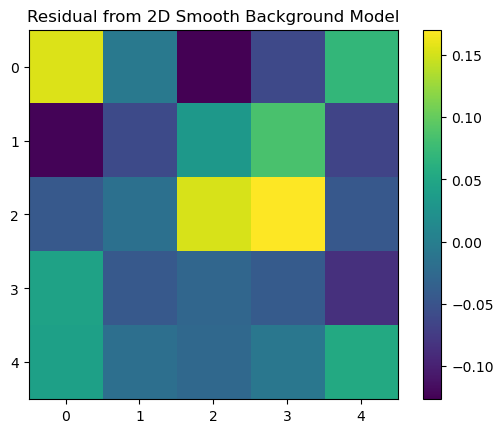

2171it [00:01, 1793.09it/s, +200 | bound: 9 | nc: 1 | ncall: 9759 | eff(%): 24.804 | loglstar:   -inf < -3.648 <    inf | logz: -12.810 +/-  0.203 | dlogz:  0.001 >  0.209]  


[1.98351009]
0.31592907602473186
[0.62664851]
Finished PSF psf_photometry with median residuals of -2.97%


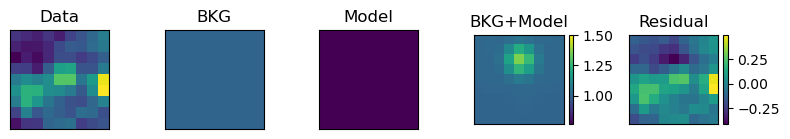

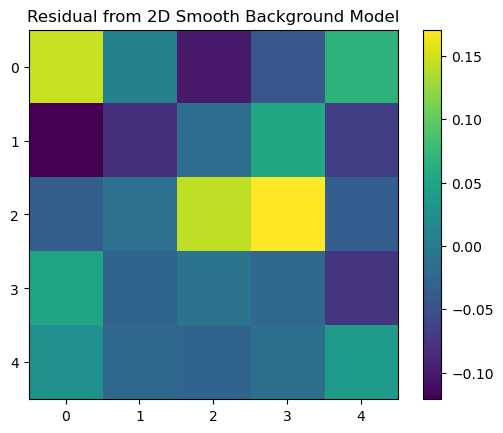

2281it [00:01, 1855.63it/s, +200 | bound: 9 | nc: 1 | ncall: 10114 | eff(%): 25.025 | loglstar:   -inf < -2.690 <    inf | logz: -12.398 +/-  0.210 | dlogz:  0.001 >  0.209] 


[1.39650958]
0.31592907602473186
[0.44119798]
Finished PSF psf_photometry with median residuals of -2.85%


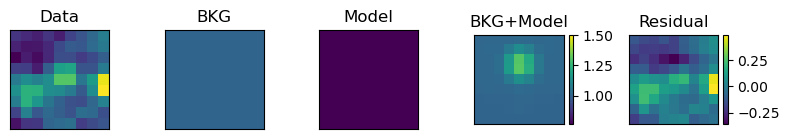

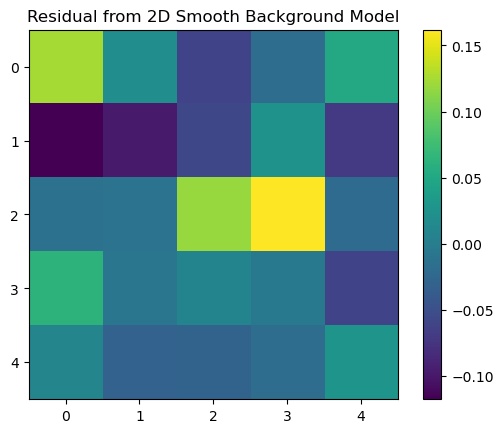

2416it [00:01, 1603.45it/s, +200 | bound: 10 | nc: 1 | ncall: 10693 | eff(%): 24.931 | loglstar:   -inf < -1.646 <    inf | logz: -12.028 +/-  0.217 | dlogz:  0.001 >  0.209]   


[1.11936587]
0.31592907602473186
[0.35364023]
Finished PSF psf_photometry with median residuals of -2.73%


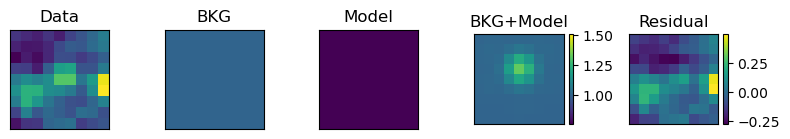

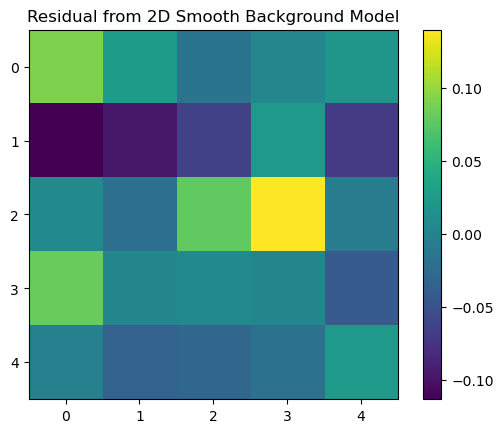

2360it [00:01, 1807.29it/s, +200 | bound: 10 | nc: 1 | ncall: 10107 | eff(%): 25.840 | loglstar:   -inf < -0.810 <    inf | logz: -10.914 +/-  0.214 | dlogz:  0.001 >  0.209]   


[0.949242]
0.31592907602473186
[0.29989315]
Finished PSF psf_photometry with median residuals of -2.56%


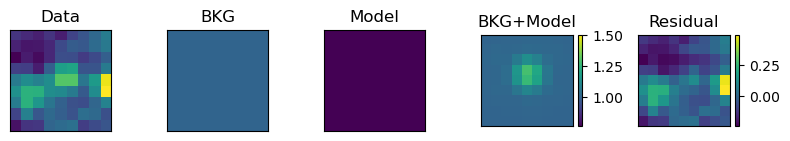

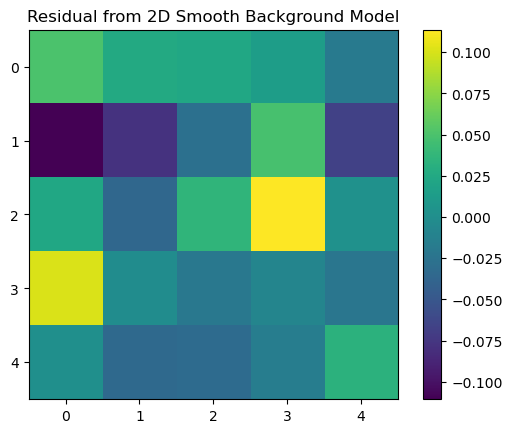

2416it [00:01, 1830.74it/s, +200 | bound: 10 | nc: 1 | ncall: 10208 | eff(%): 26.139 | loglstar:   -inf < -0.490 <    inf | logz: -10.871 +/-  0.217 | dlogz:  0.001 >  0.209]   


[0.91891704]
0.31592907602473186
[0.29031261]
Finished PSF psf_photometry with median residuals of -2.42%


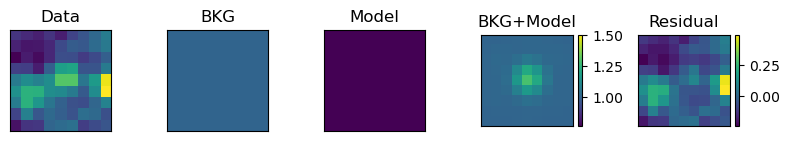

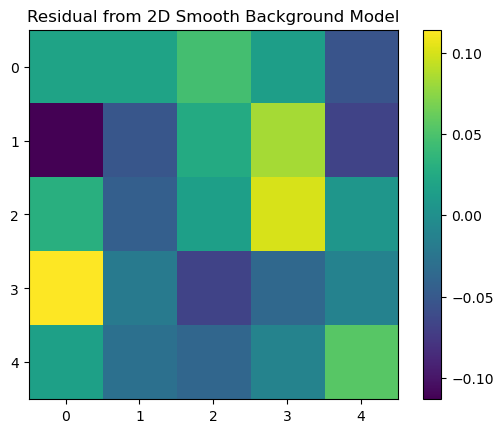

2341it [00:01, 1825.44it/s, +200 | bound: 10 | nc: 1 | ncall: 9876 | eff(%): 26.261 | loglstar:   -inf < -0.735 <    inf | logz: -10.740 +/-  0.213 | dlogz:  0.001 >  0.209]    


[0.94737421]
0.31592907602473186
[0.29930306]
Finished PSF psf_photometry with median residuals of -2.35%


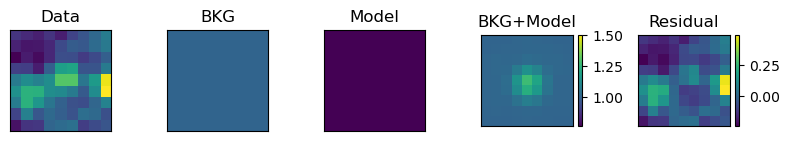

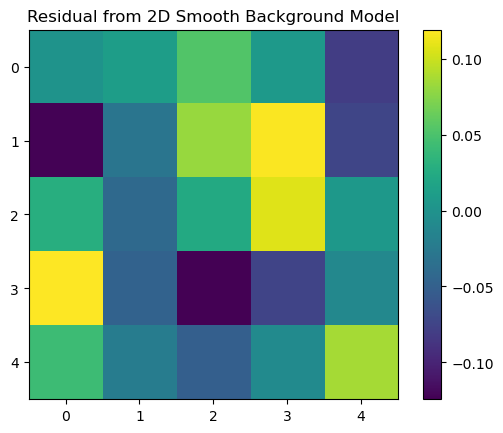

2341it [00:01, 1787.44it/s, +200 | bound: 10 | nc: 1 | ncall: 10025 | eff(%): 25.863 | loglstar:   -inf < -1.478 <    inf | logz: -11.488 +/-  0.213 | dlogz:  0.001 >  0.209]   


[1.04103212]
0.31592907602473186
[0.32889232]
Finished PSF psf_photometry with median residuals of -2.40%


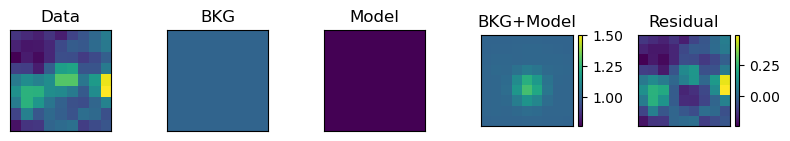

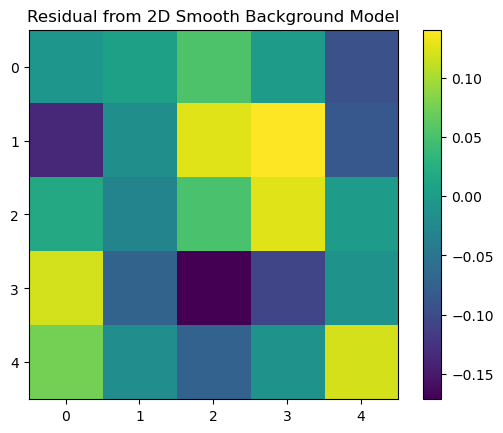

2301it [00:01, 1876.33it/s, +200 | bound: 9 | nc: 1 | ncall: 9963 | eff(%): 25.617 | loglstar:   -inf < -2.466 <    inf | logz: -12.273 +/-  0.211 | dlogz:  0.001 >  0.209]     


[1.21886406]
0.31592907602473186
[0.3850746]
Finished PSF psf_photometry with median residuals of -2.50%


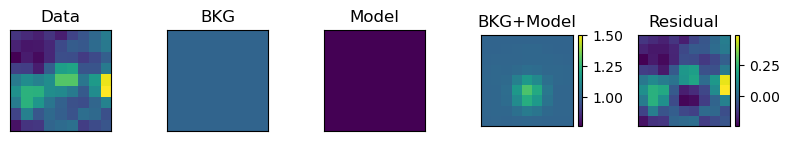

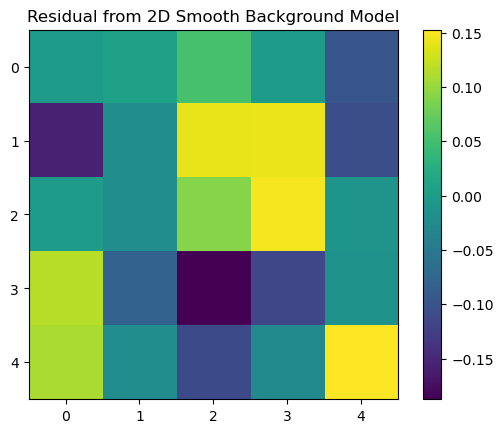

2359it [00:01, 1862.05it/s, +200 | bound: 9 | nc: 1 | ncall: 10538 | eff(%): 24.753 | loglstar:   -inf < -3.524 <    inf | logz: -13.621 +/-  0.214 | dlogz:  0.001 >  0.209] 


[1.56994004]
0.31592907602473186
[0.4959897]
Finished PSF psf_photometry with median residuals of -2.54%


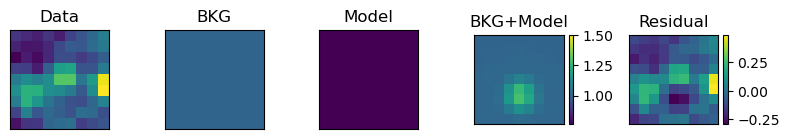

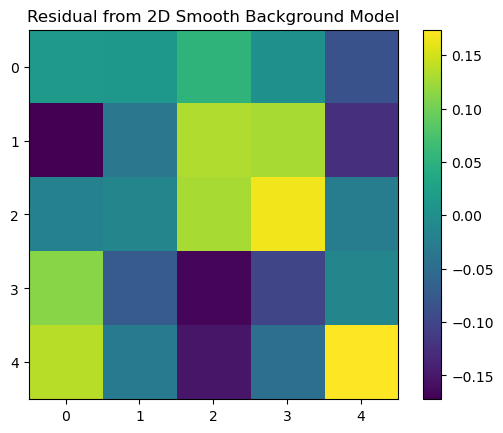

2223it [00:01, 1837.28it/s, +200 | bound: 9 | nc: 1 | ncall: 9736 | eff(%): 25.409 | loglstar:   -inf < -4.333 <    inf | logz: -13.752 +/-  0.206 | dlogz:  0.001 >  0.209]      


[3.06849876]
0.31592907602473186
[0.96942798]
Finished PSF psf_photometry with median residuals of -3.75%


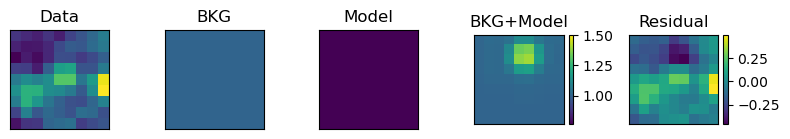

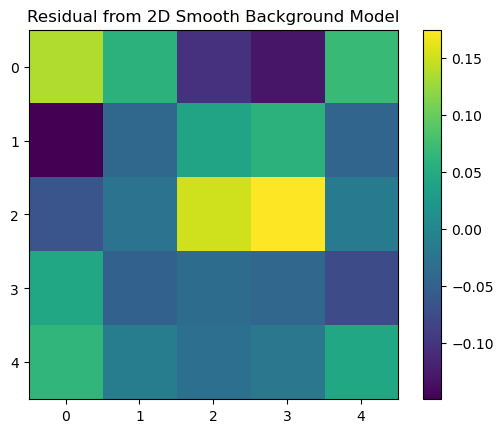

2238it [00:01, 1831.76it/s, +200 | bound: 9 | nc: 1 | ncall: 10030 | eff(%): 24.802 | loglstar:   -inf < -3.515 <    inf | logz: -13.007 +/-  0.207 | dlogz:  0.001 >  0.209] 

[2.16466803]
0.31592907602473186
[0.68388157]
Finished PSF psf_photometry with median residuals of -3.46%


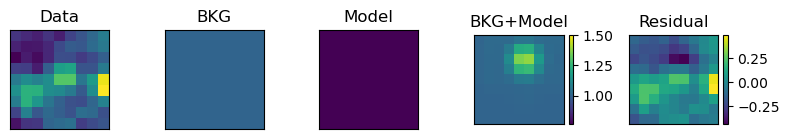

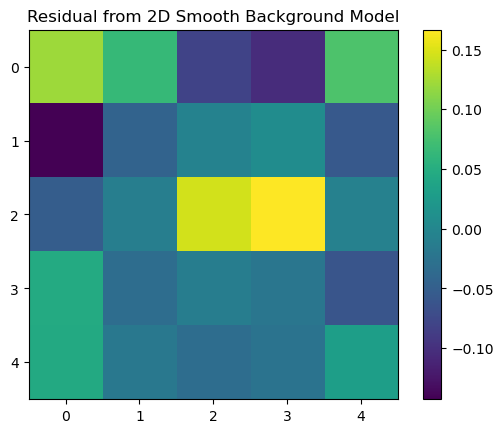

2377it [00:01, 1781.73it/s, +200 | bound: 10 | nc: 1 | ncall: 10416 | eff(%): 25.225 | loglstar:   -inf < -2.526 <    inf | logz: -12.713 +/-  0.215 | dlogz:  0.001 >  0.209]


[1.5715678]
0.31592907602473186
[0.49650396]
Finished PSF psf_photometry with median residuals of -3.18%


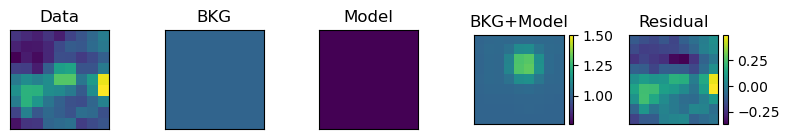

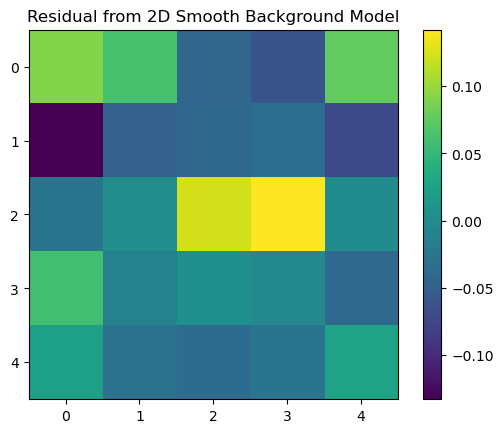

2369it [00:01, 1825.45it/s, +200 | bound: 10 | nc: 1 | ncall: 10034 | eff(%): 26.124 | loglstar:   -inf < -1.474 <    inf | logz: -11.624 +/-  0.215 | dlogz:  0.001 >  0.209]   


[1.24918582]
0.31592907602473186
[0.39465412]
Finished PSF psf_photometry with median residuals of -2.93%


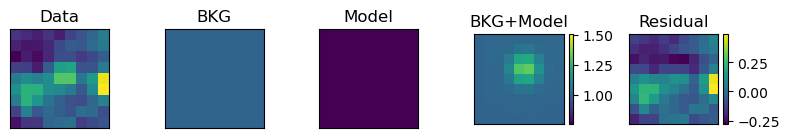

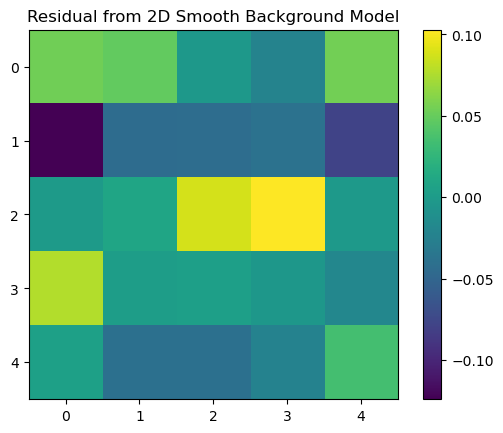

2404it [00:01, 1808.13it/s, +200 | bound: 10 | nc: 1 | ncall: 10516 | eff(%): 25.242 | loglstar:   -inf < -0.662 <    inf | logz: -10.986 +/-  0.217 | dlogz:  0.001 >  0.209]


[1.05576216]
0.31592907602473186
[0.33354596]
Finished PSF psf_photometry with median residuals of -2.75%


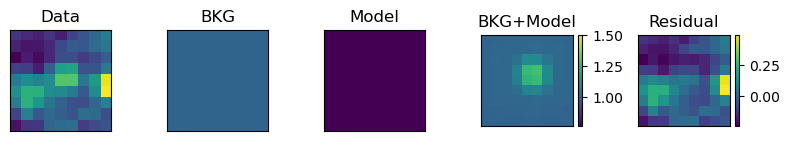

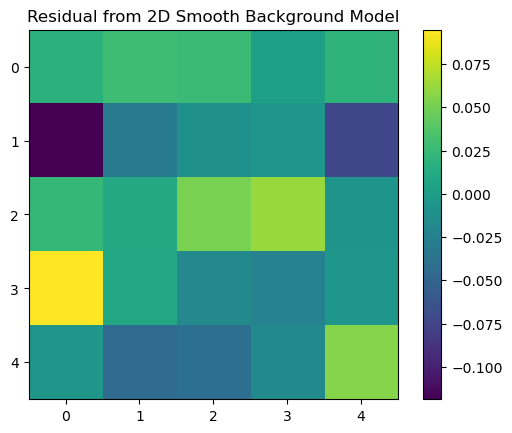

2395it [00:01, 1842.83it/s, +200 | bound: 10 | nc: 1 | ncall: 10073 | eff(%): 26.284 | loglstar:   -inf < -0.391 <    inf | logz: -10.670 +/-  0.216 | dlogz:  0.001 >  0.209]   


[1.00648963]
0.31592907602473186
[0.31797934]
Finished PSF psf_photometry with median residuals of -2.70%


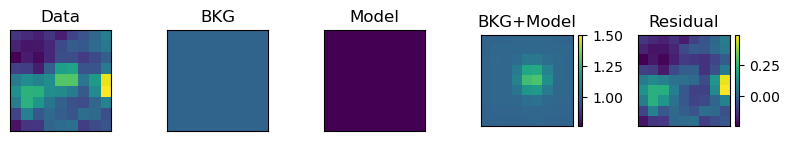

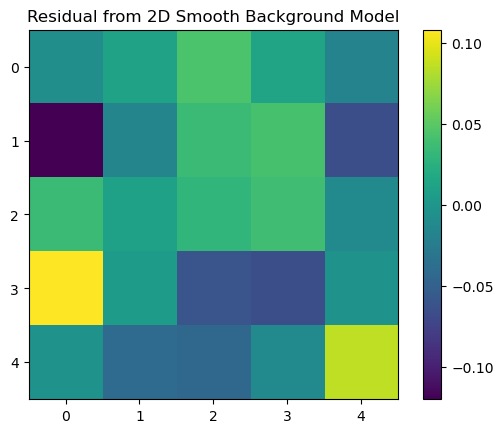

2265it [00:01, 1855.42it/s, +200 | bound: 9 | nc: 1 | ncall: 9852 | eff(%): 25.539 | loglstar:   -inf < -0.701 <    inf | logz: -10.332 +/-  0.209 | dlogz:  0.001 >  0.209]     


[0.95524271]
0.31592907602473186
[0.30178895]
Finished PSF psf_photometry with median residuals of -2.65%


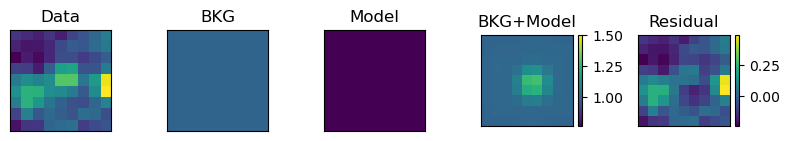

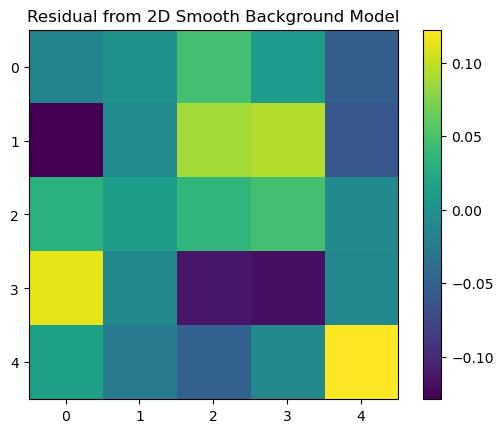

2307it [00:01, 1898.14it/s, +200 | bound: 9 | nc: 1 | ncall: 9729 | eff(%): 26.309 | loglstar:   -inf < -1.505 <    inf | logz: -11.345 +/-  0.211 | dlogz:  0.001 >  0.209]     


[1.08663837]
0.31592907602473186
[0.34330066]
Finished PSF psf_photometry with median residuals of -2.53%


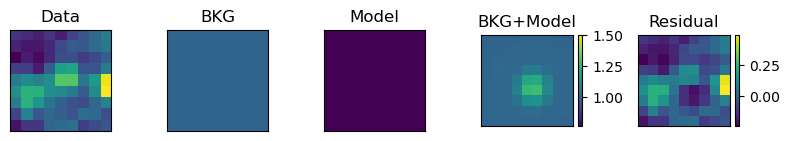

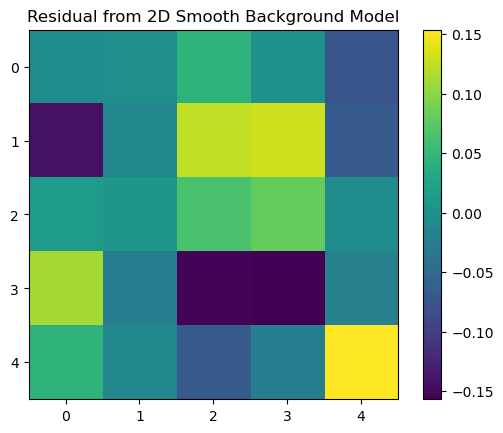

2303it [00:01, 1863.45it/s, +200 | bound: 9 | nc: 1 | ncall: 10142 | eff(%): 25.176 | loglstar:   -inf < -2.533 <    inf | logz: -12.352 +/-  0.211 | dlogz:  0.001 >  0.209] 


[1.33886978]
0.31592907602473186
[0.42298789]
Finished PSF psf_photometry with median residuals of -2.66%


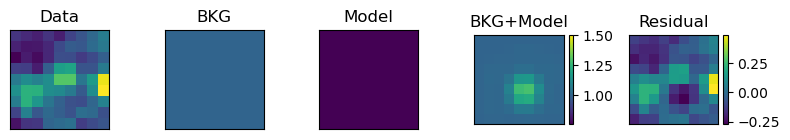

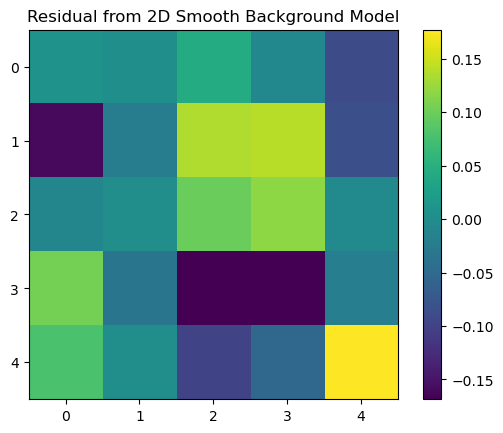

2274it [00:01, 1835.90it/s, +200 | bound: 9 | nc: 1 | ncall: 9983 | eff(%): 25.289 | loglstar:   -inf < -3.605 <    inf | logz: -13.279 +/-  0.209 | dlogz:  0.001 >  0.209]  


[1.66726844]
0.31592907602473186
[0.52673858]
Finished PSF psf_photometry with median residuals of -2.72%


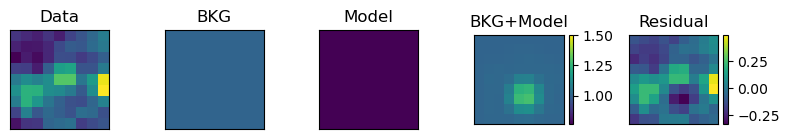

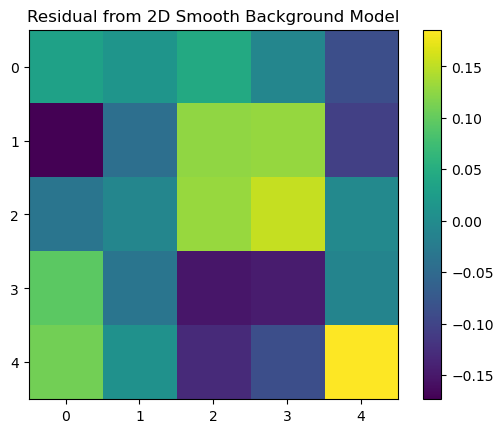

2149it [00:01, 1759.56it/s, +200 | bound: 9 | nc: 1 | ncall: 9544 | eff(%): 25.139 | loglstar:   -inf < -4.365 <    inf | logz: -13.417 +/-  0.202 | dlogz:  0.001 >  0.209]  


[3.60626258]
0.31592907602473186
[1.13932321]
Finished PSF psf_photometry with median residuals of -4.36%


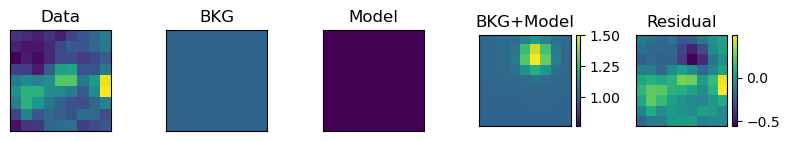

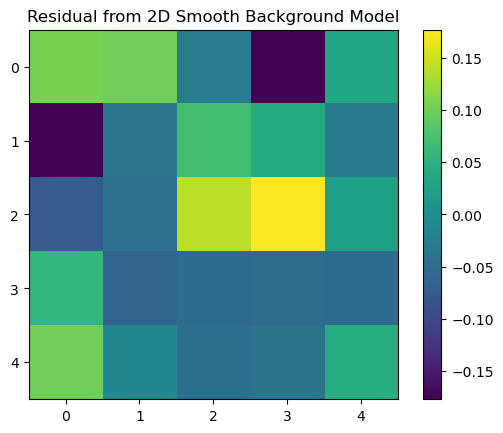

2204it [00:01, 1822.88it/s, +200 | bound: 9 | nc: 1 | ncall: 9506 | eff(%): 25.833 | loglstar:   -inf < -3.612 <    inf | logz: -12.936 +/-  0.205 | dlogz:  0.001 >  0.209]  


[2.36626234]
0.31592907602473186
[0.74757108]
Finished PSF psf_photometry with median residuals of -4.03%


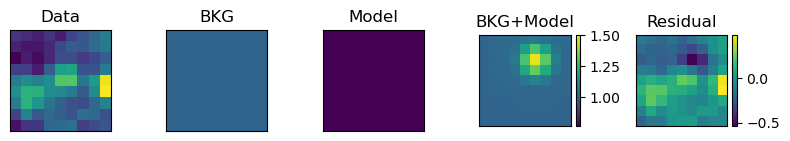

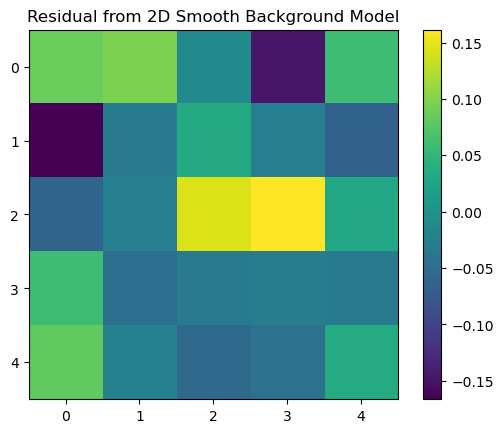

2293it [00:01, 1812.45it/s, +200 | bound: 9 | nc: 1 | ncall: 10149 | eff(%): 25.058 | loglstar:   -inf < -2.709 <    inf | logz: -12.480 +/-  0.210 | dlogz:  0.001 >  0.209]     


[1.80420165]
0.31592907602473186
[0.56999976]
Finished PSF psf_photometry with median residuals of -3.56%


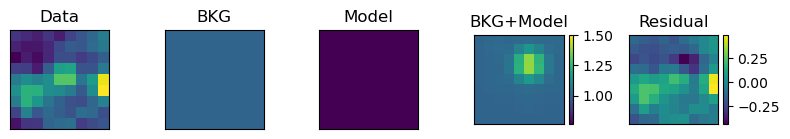

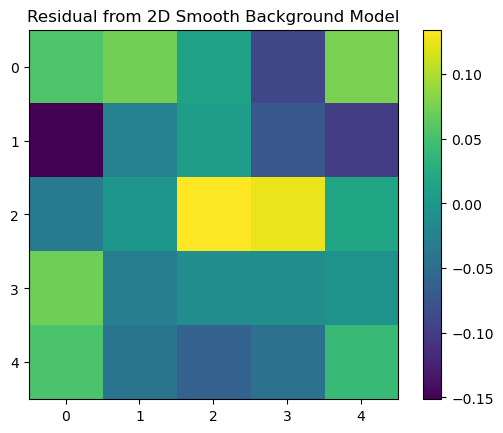

2239it [00:01, 1826.21it/s, +200 | bound: 9 | nc: 1 | ncall: 9964 | eff(%): 24.980 | loglstar:   -inf < -1.760 <    inf | logz: -11.262 +/-  0.207 | dlogz:  0.001 >  0.209]  


[1.36926295]
0.31592907602473186
[0.43258998]
Finished PSF psf_photometry with median residuals of -3.32%


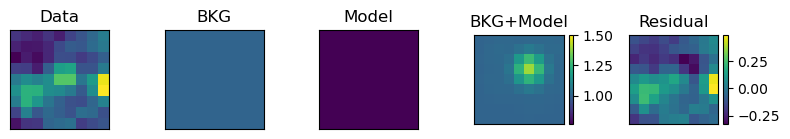

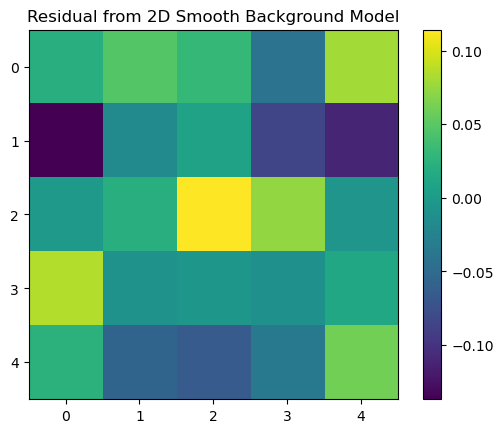

2346it [00:01, 1779.16it/s, +200 | bound: 10 | nc: 1 | ncall: 10246 | eff(%): 25.343 | loglstar:   -inf < -1.046 <    inf | logz: -11.080 +/-  0.213 | dlogz:  0.001 >  0.209]


[1.26123536]
0.31592907602473186
[0.39846092]
Finished PSF psf_photometry with median residuals of -3.09%


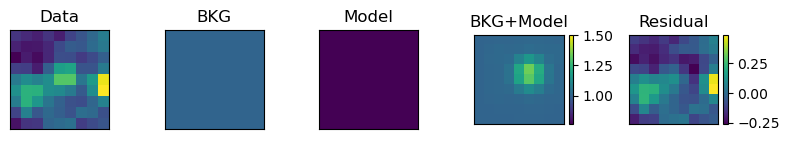

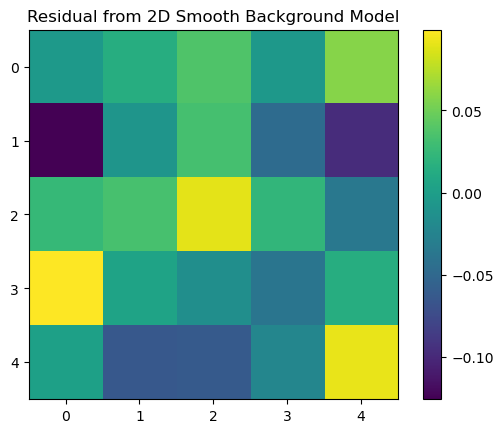

2334it [00:01, 1825.77it/s, +200 | bound: 10 | nc: 1 | ncall: 9815 | eff(%): 26.355 | loglstar:   -inf < -0.840 <    inf | logz: -10.813 +/-  0.213 | dlogz:  0.001 >  0.209]    


[1.15665024]
0.31592907602473186
[0.36541944]
Finished PSF psf_photometry with median residuals of -3.03%


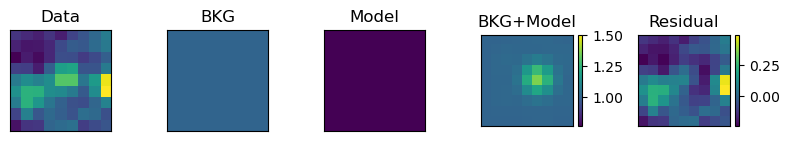

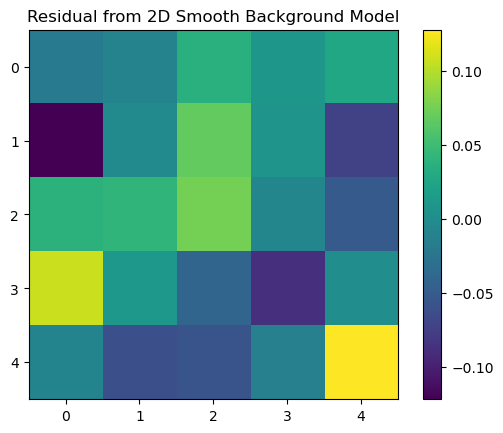

2281it [00:01, 1839.15it/s, +200 | bound: 9 | nc: 1 | ncall: 10052 | eff(%): 25.183 | loglstar:   -inf < -1.171 <    inf | logz: -10.877 +/-  0.210 | dlogz:  0.001 >  0.209]    


[1.16521636]
0.31592907602473186
[0.36812573]
Finished PSF psf_photometry with median residuals of -2.98%


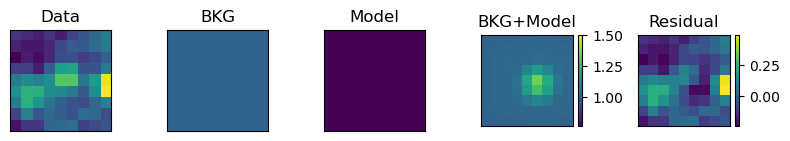

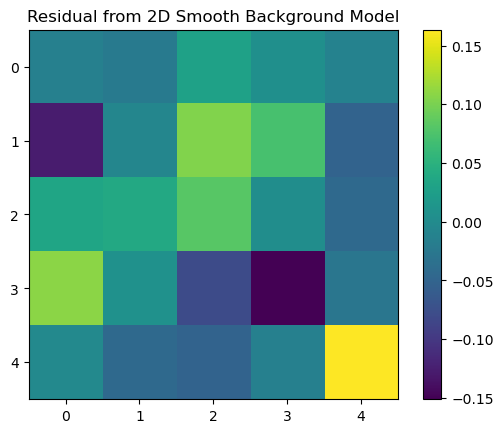

2362it [00:01, 1796.59it/s, +200 | bound: 10 | nc: 1 | ncall: 10200 | eff(%): 25.620 | loglstar:   -inf < -1.940 <    inf | logz: -12.054 +/-  0.214 | dlogz:  0.001 >  0.209]


[1.28948074]
0.31592907602473186
[0.40738446]
Finished PSF psf_photometry with median residuals of -2.91%


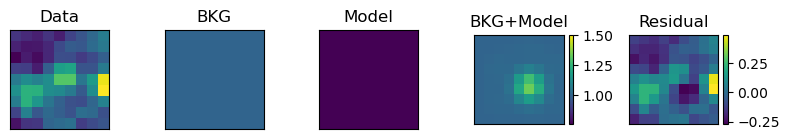

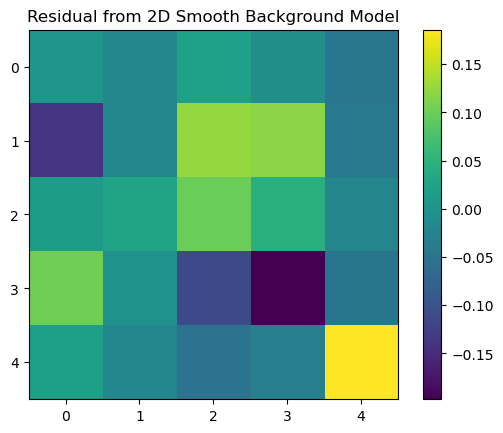

2279it [00:01, 1817.45it/s, +200 | bound: 9 | nc: 1 | ncall: 10143 | eff(%): 24.932 | loglstar:   -inf < -2.884 <    inf | logz: -12.581 +/-  0.209 | dlogz:  0.001 >  0.209]    


[1.51970641]
0.31592907602473186
[0.48011944]
Finished PSF psf_photometry with median residuals of -2.87%


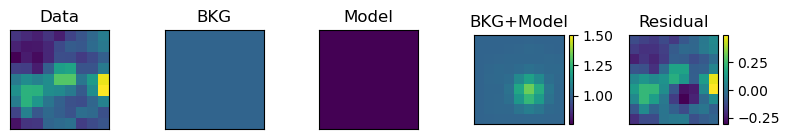

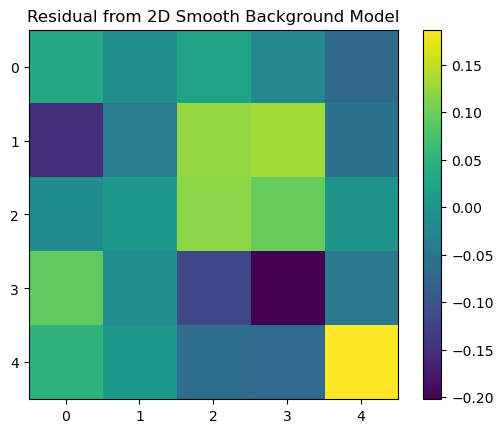

2222it [00:01, 1814.88it/s, +200 | bound: 9 | nc: 1 | ncall: 9823 | eff(%): 25.169 | loglstar:   -inf < -3.839 <    inf | logz: -13.254 +/-  0.206 | dlogz:  0.001 >  0.209]  


[1.91255436]
0.31592907602473186
[0.60423153]
Finished PSF psf_photometry with median residuals of -3.04%


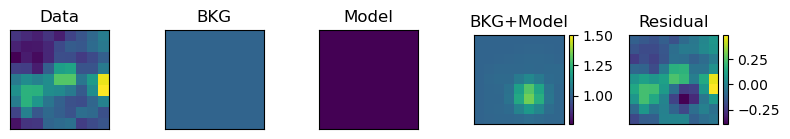

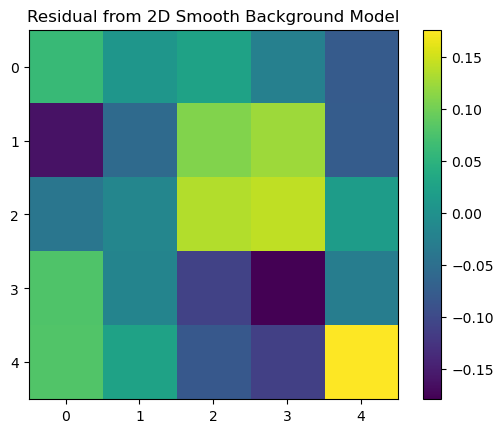

2108it [00:01, 1892.13it/s, +200 | bound: 8 | nc: 1 | ncall: 9274 | eff(%): 25.435 | loglstar:   -inf < -4.487 <    inf | logz: -13.334 +/-  0.199 | dlogz:  0.001 >  0.209]      


[4.62983713]
0.31592907602473186
[1.46270017]
Finished PSF psf_photometry with median residuals of -5.45%


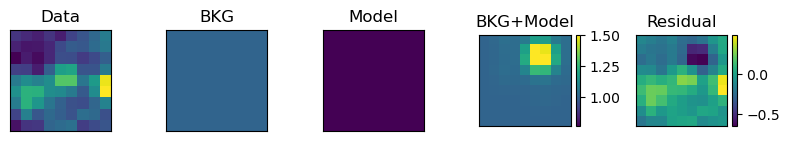

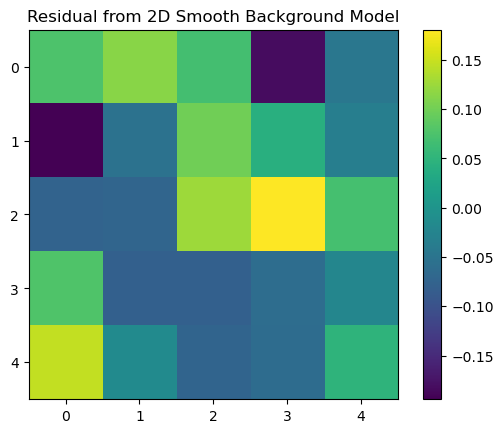

2153it [00:01, 1821.81it/s, +200 | bound: 8 | nc: 1 | ncall: 10192 | eff(%): 23.549 | loglstar:   -inf < -3.898 <    inf | logz: -12.966 +/-  0.202 | dlogz:  0.001 >  0.209] 


[3.0323776]
0.31592907602473186
[0.95801625]
Finished PSF psf_photometry with median residuals of -4.68%


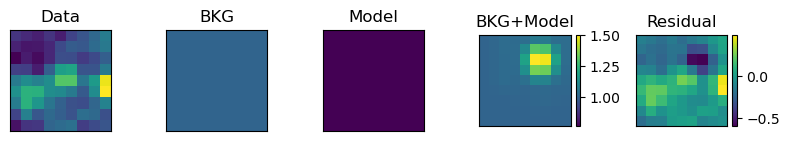

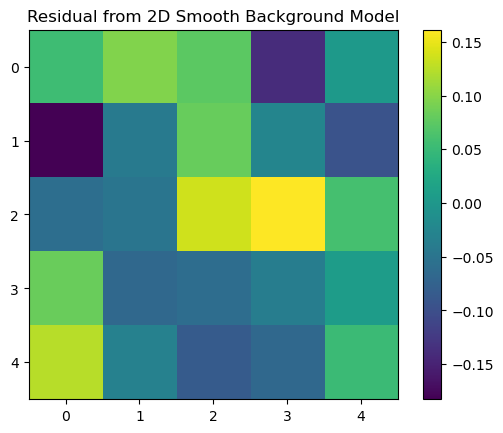

2160it [00:01, 1794.22it/s, +200 | bound: 9 | nc: 1 | ncall: 9753 | eff(%): 24.704 | loglstar:   -inf < -3.196 <    inf | logz: -12.300 +/-  0.202 | dlogz:  0.001 >  0.209]  


[2.26306283]
0.31592907602473186
[0.71496735]
Finished PSF psf_photometry with median residuals of -4.19%


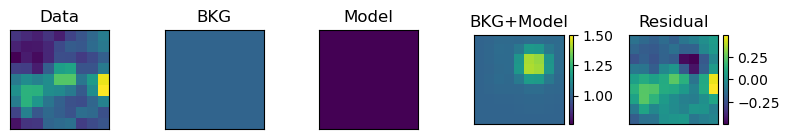

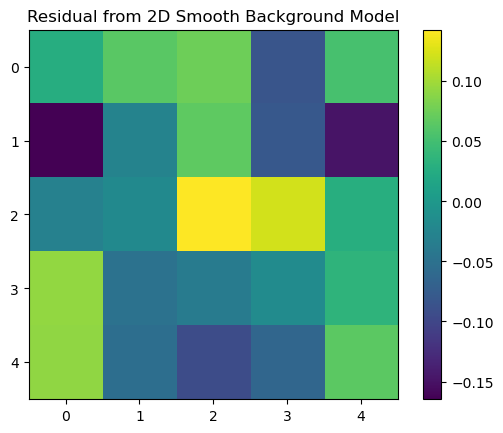

2221it [00:01, 1827.39it/s, +200 | bound: 9 | nc: 1 | ncall: 9717 | eff(%): 25.439 | loglstar:   -inf < -2.459 <    inf | logz: -11.867 +/-  0.206 | dlogz:  0.001 >  0.209]  


[1.86580396]
0.31592907602473186
[0.58946172]
Finished PSF psf_photometry with median residuals of -3.87%


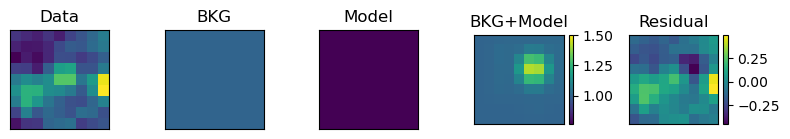

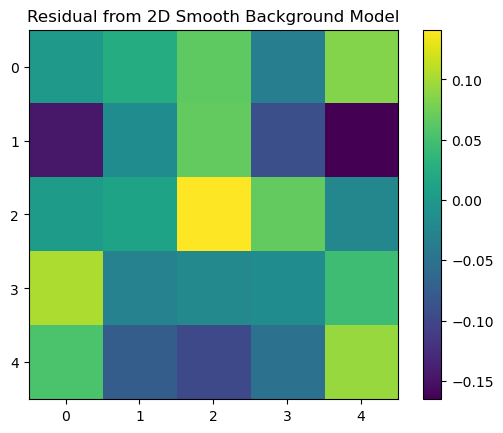

2313it [00:01, 1810.24it/s, +200 | bound: 10 | nc: 1 | ncall: 9689 | eff(%): 26.483 | loglstar:   -inf < -1.915 <    inf | logz: -11.783 +/-  0.211 | dlogz:  0.001 >  0.209] 


[1.52548361]
0.31592907602473186
[0.48194463]
Finished PSF psf_photometry with median residuals of -3.58%


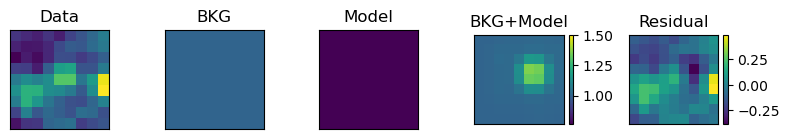

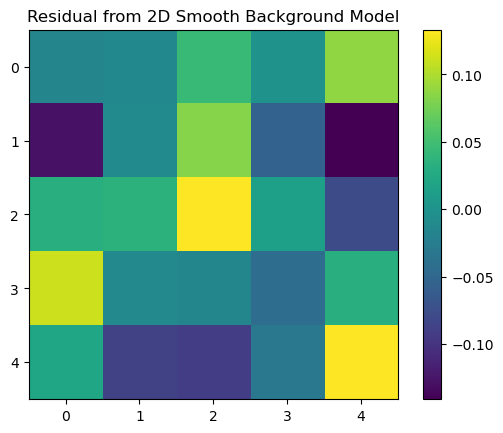

2397it [00:01, 1865.89it/s, +200 | bound: 9 | nc: 1 | ncall: 10487 | eff(%): 25.245 | loglstar:   -inf < -1.785 <    inf | logz: -12.071 +/-  0.216 | dlogz:  0.001 >  0.209]    


[1.42574722]
0.31592907602473186
[0.450435]
Finished PSF psf_photometry with median residuals of -3.31%


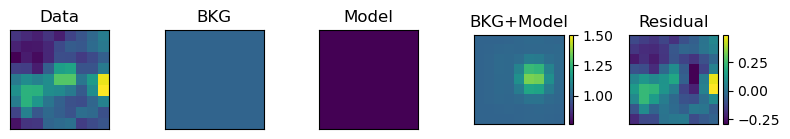

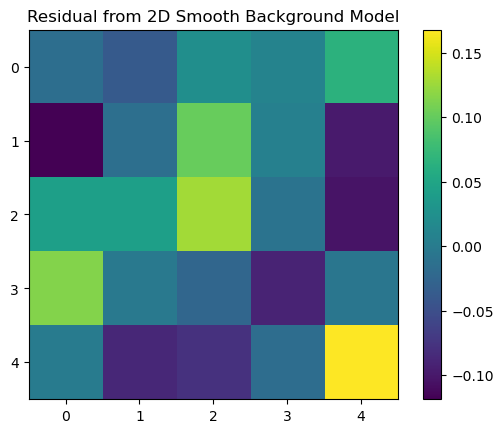

2290it [00:01, 1843.68it/s, +200 | bound: 9 | nc: 1 | ncall: 10092 | eff(%): 25.172 | loglstar:   -inf < -2.085 <    inf | logz: -11.840 +/-  0.210 | dlogz:  0.001 >  0.209] 


[1.42111094]
0.31592907602473186
[0.44897027]
Finished PSF psf_photometry with median residuals of -3.32%


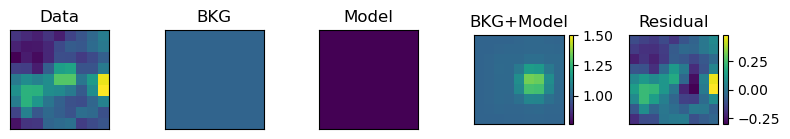

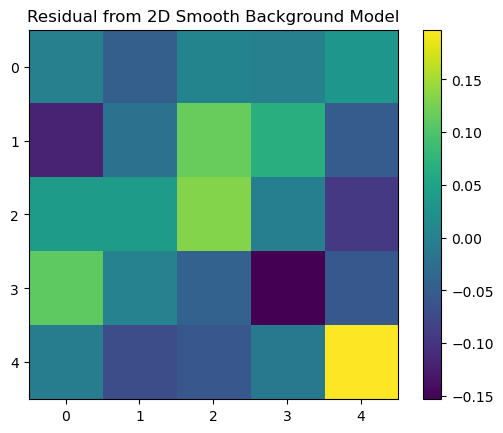

2308it [00:01, 1857.57it/s, +200 | bound: 9 | nc: 1 | ncall: 9860 | eff(%): 25.963 | loglstar:   -inf < -2.718 <    inf | logz: -12.562 +/-  0.211 | dlogz:  0.001 >  0.209]  


[1.67179515]
0.31592907602473186
[0.5281687]
Finished PSF psf_photometry with median residuals of -3.13%


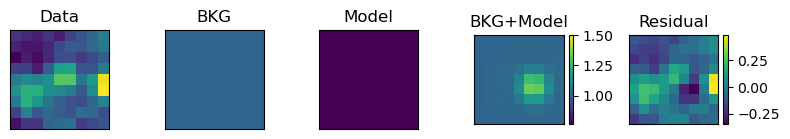

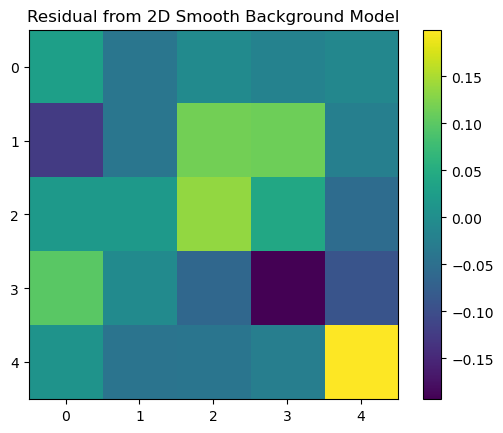

2283it [00:01, 1871.34it/s, +200 | bound: 9 | nc: 1 | ncall: 9776 | eff(%): 25.929 | loglstar:   -inf < -3.454 <    inf | logz: -13.175 +/-  0.210 | dlogz:  0.001 >  0.209]  


[1.84711525]
0.31592907602473186
[0.58355741]
Finished PSF psf_photometry with median residuals of -3.16%


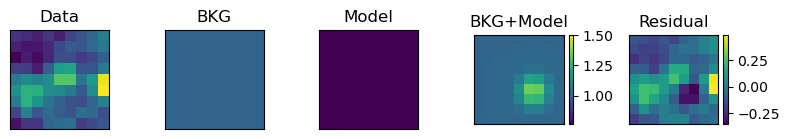

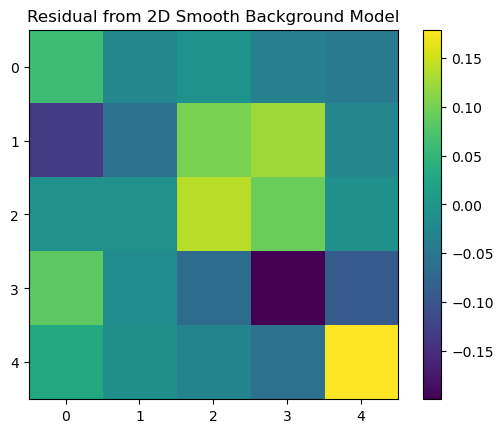

2198it [00:01, 1849.92it/s, +200 | bound: 9 | nc: 1 | ncall: 9396 | eff(%): 26.077 | loglstar:   -inf < -4.171 <    inf | logz: -13.463 +/-  0.205 | dlogz:  0.001 >  0.209]  


[2.46364239]
0.31592907602473186
[0.77833626]
Finished PSF psf_photometry with median residuals of -3.26%


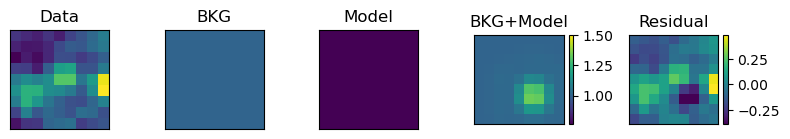

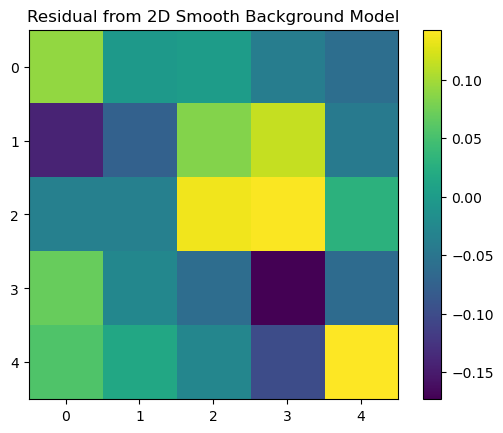

2025it [00:01, 1795.16it/s, +200 | bound: 8 | nc: 1 | ncall: 9653 | eff(%): 23.538 | loglstar:   -inf < -4.557 <    inf | logz: -12.989 +/-  0.194 | dlogz:  0.001 >  0.209]     


[5.91177996]
0.31592907602473186
[1.86770318]
Finished PSF psf_photometry with median residuals of -6.64%


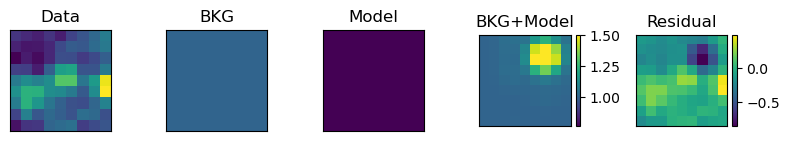

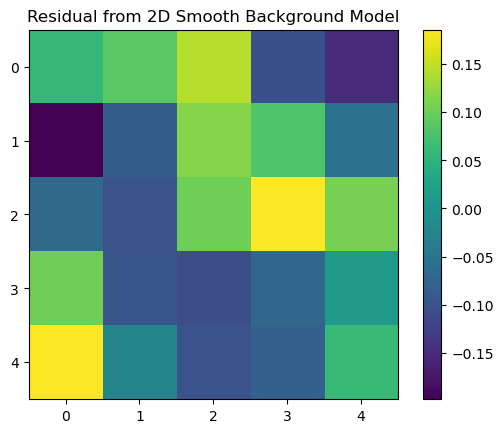

2188it [00:01, 1840.69it/s, +200 | bound: 8 | nc: 1 | ncall: 10264 | eff(%): 23.728 | loglstar:   -inf < -4.165 <    inf | logz: -13.409 +/-  0.204 | dlogz:  0.001 >  0.209]    


[4.28215571]
0.31592907602473186
[1.3528575]
Finished PSF psf_photometry with median residuals of -5.29%


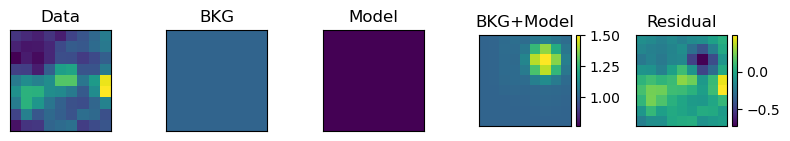

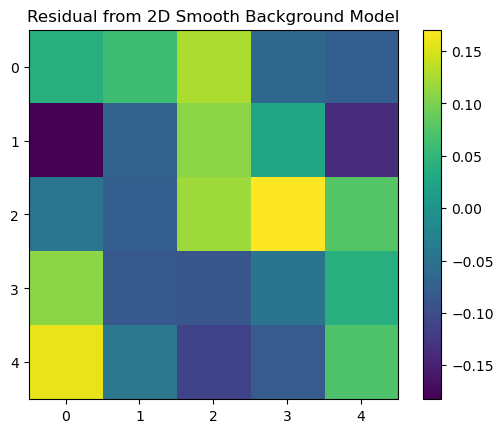

2176it [00:01, 1858.86it/s, +200 | bound: 8 | nc: 1 | ncall: 9988 | eff(%): 24.275 | loglstar:   -inf < -3.699 <    inf | logz: -12.882 +/-  0.203 | dlogz:  0.001 >  0.209]  


[3.04780001]
0.31592907602473186
[0.96288864]
Finished PSF psf_photometry with median residuals of -5.03%


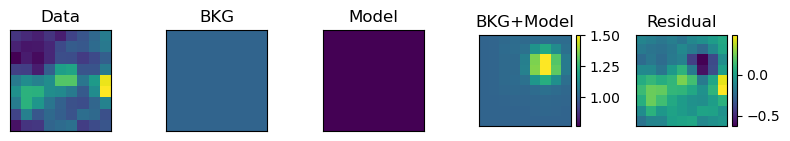

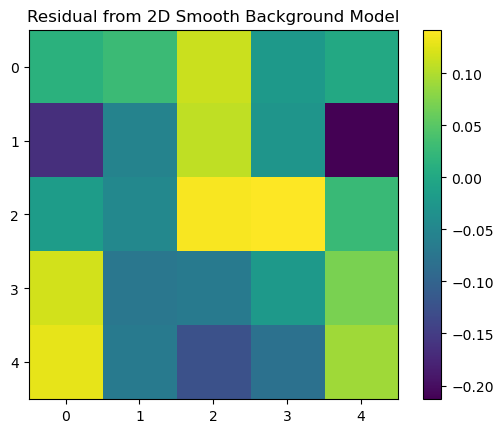

2240it [00:01, 1831.90it/s, +200 | bound: 9 | nc: 1 | ncall: 9874 | eff(%): 25.222 | loglstar:   -inf < -3.203 <    inf | logz: -12.707 +/-  0.207 | dlogz:  0.001 >  0.209]  


[2.53111975]
0.31592907602473186
[0.79965432]
Finished PSF psf_photometry with median residuals of -4.53%


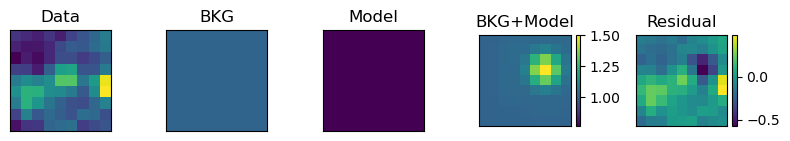

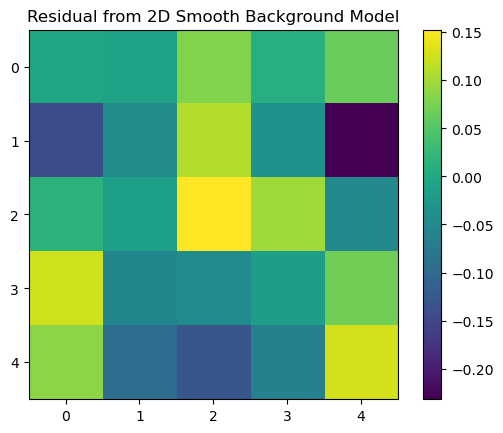

2274it [00:01, 1833.59it/s, +200 | bound: 9 | nc: 1 | ncall: 10203 | eff(%): 24.733 | loglstar:   -inf < -2.841 <    inf | logz: -12.514 +/-  0.209 | dlogz:  0.001 >  0.209] 


[2.12468313]
0.31592907602473186
[0.67124918]
Finished PSF psf_photometry with median residuals of -4.26%


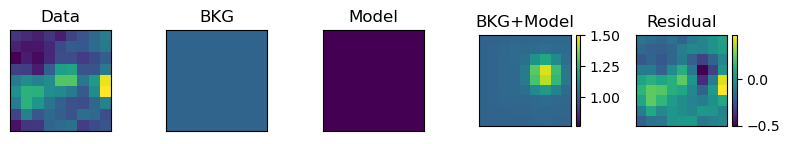

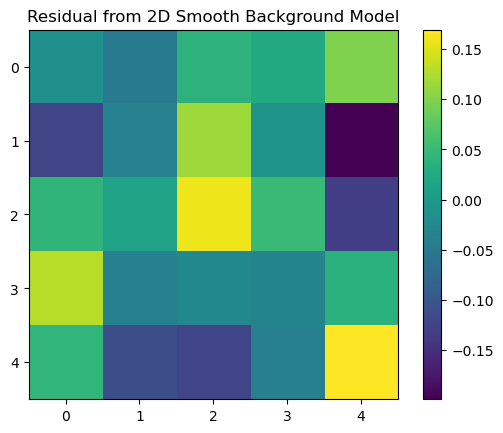

2238it [00:01, 1831.36it/s, +200 | bound: 9 | nc: 1 | ncall: 9682 | eff(%): 25.712 | loglstar:   -inf < -2.771 <    inf | logz: -12.265 +/-  0.207 | dlogz:  0.001 >  0.209]  


[2.05329047]
0.31592907602473186
[0.64869416]
Finished PSF psf_photometry with median residuals of -4.10%


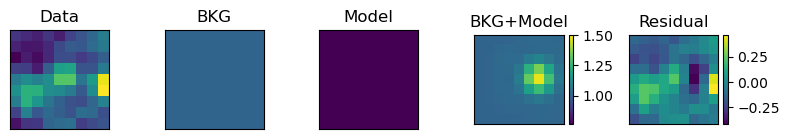

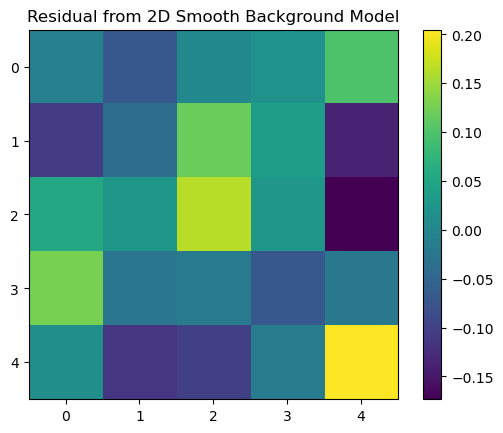

2284it [00:01, 1821.49it/s, +200 | bound: 9 | nc: 1 | ncall: 10053 | eff(%): 25.211 | loglstar:   -inf < -2.999 <    inf | logz: -12.723 +/-  0.210 | dlogz:  0.001 >  0.209] 


[2.05645326]
0.31592907602473186
[0.64969338]
Finished PSF psf_photometry with median residuals of -3.78%


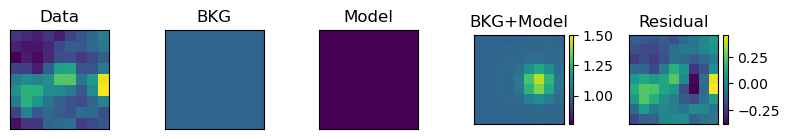

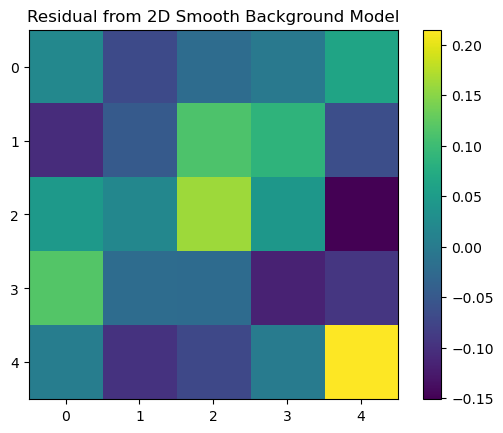

2116it [00:01, 1762.22it/s, +200 | bound: 9 | nc: 1 | ncall: 9436 | eff(%): 25.076 | loglstar:   -inf < -3.444 <    inf | logz: -12.329 +/-  0.199 | dlogz:  0.001 >  0.209]  


[2.27179532]
0.31592907602473186
[0.7177262]
Finished PSF psf_photometry with median residuals of -3.79%


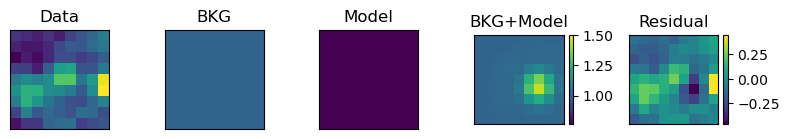

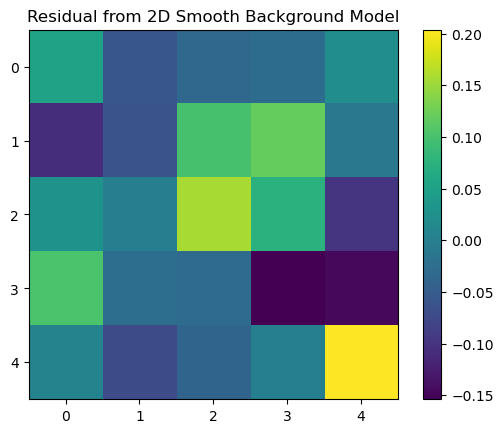

2192it [00:01, 1802.78it/s, +200 | bound: 9 | nc: 1 | ncall: 9559 | eff(%): 25.558 | loglstar:   -inf < -3.931 <    inf | logz: -13.197 +/-  0.204 | dlogz:  0.001 >  0.209]  


[2.54410719]
0.31592907602473186
[0.80375743]
Finished PSF psf_photometry with median residuals of -3.64%


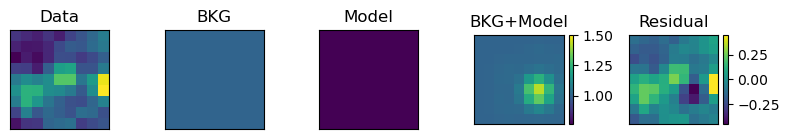

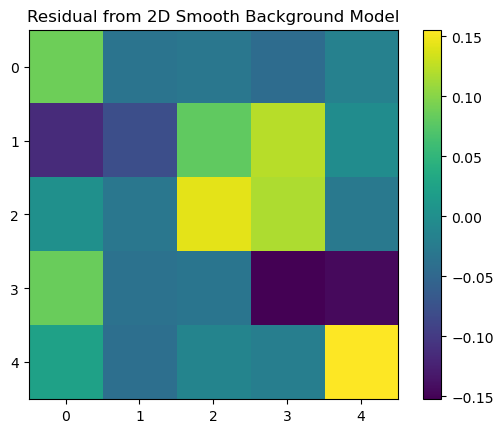

2142it [00:01, 1765.91it/s, +200 | bound: 9 | nc: 1 | ncall: 9662 | eff(%): 24.752 | loglstar:   -inf < -4.383 <    inf | logz: -13.400 +/-  0.201 | dlogz:  0.001 >  0.209]      

[3.29601122]
0.31592907602473186
[1.04130578]
Finished PSF psf_photometry with median residuals of -4.10%


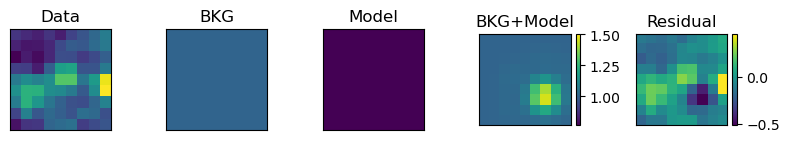

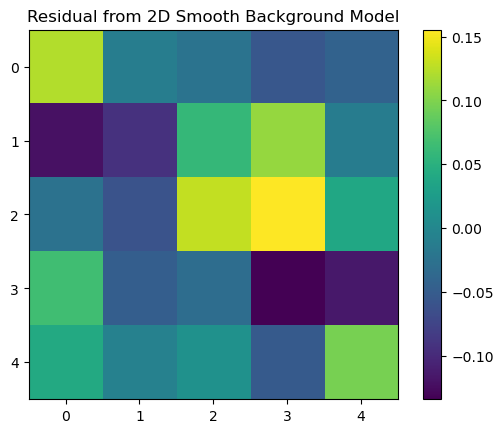

1978it [00:01, 1811.32it/s, +200 | bound: 7 | nc: 1 | ncall: 9696 | eff(%): 22.936 | loglstar:   -inf < -4.477 <    inf | logz: -12.672 +/-  0.191 | dlogz:  0.001 >  0.209]     


[9.35262495]
0.31592907602473186
[2.95476616]
Finished PSF psf_photometry with median residuals of -10.10%


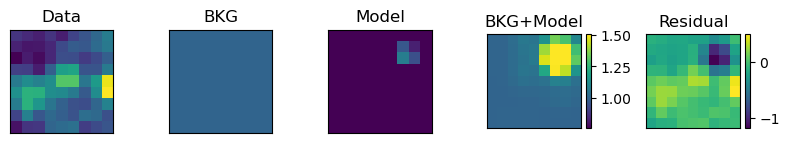

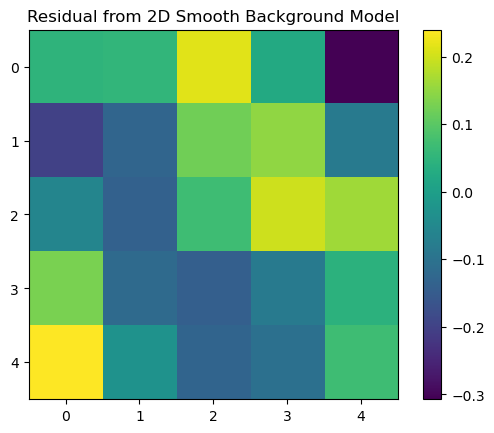

2044it [00:01, 1776.59it/s, +200 | bound: 8 | nc: 1 | ncall: 9768 | eff(%): 23.453 | loglstar:   -inf < -4.313 <    inf | logz: -12.840 +/-  0.195 | dlogz:  0.001 >  0.209]      


[6.45260406]
0.31592907602473186
[2.03856524]
Finished PSF psf_photometry with median residuals of -8.07%


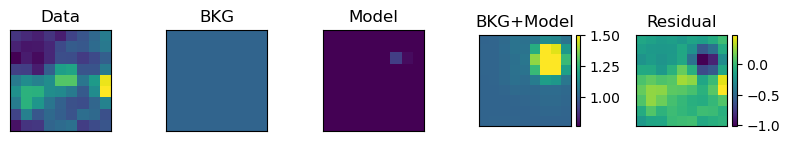

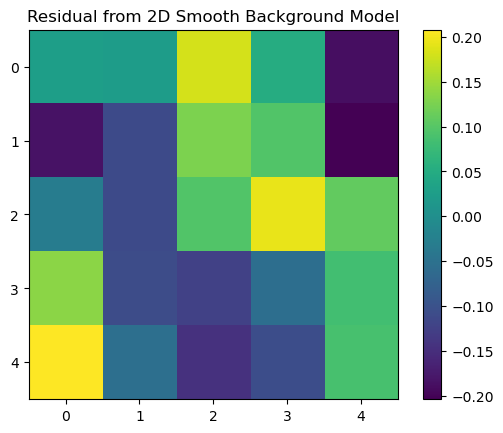

2019it [00:01, 1792.43it/s, +200 | bound: 8 | nc: 1 | ncall: 9043 | eff(%): 25.093 | loglstar:   -inf < -4.105 <    inf | logz: -12.505 +/-  0.193 | dlogz:  0.001 >  0.209]     


[4.44111125]
0.31592907602473186
[1.40307617]
Finished PSF psf_photometry with median residuals of -6.13%


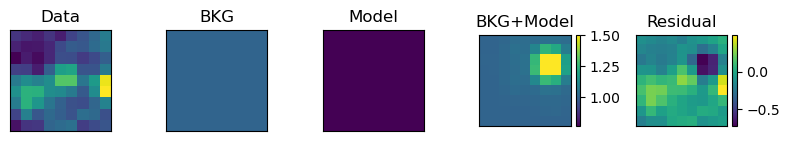

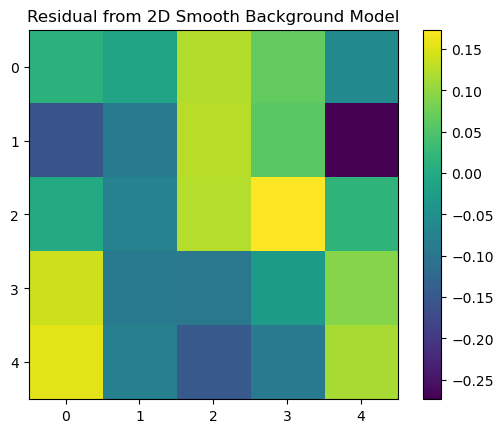

2108it [00:01, 1752.56it/s, +200 | bound: 9 | nc: 1 | ncall: 9180 | eff(%): 25.702 | loglstar:   -inf < -3.861 <    inf | logz: -12.705 +/-  0.199 | dlogz:  0.001 >  0.209]      


[3.85551352]
0.31592907602473186
[1.21806882]
Finished PSF psf_photometry with median residuals of -6.03%


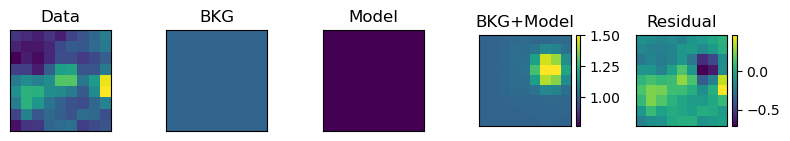

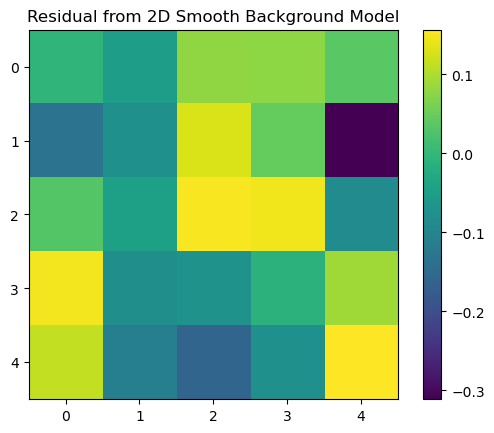

2087it [00:01, 1721.07it/s, +200 | bound: 9 | nc: 1 | ncall: 9486 | eff(%): 24.628 | loglstar:   -inf < -3.685 <    inf | logz: -12.426 +/-  0.198 | dlogz:  0.001 >  0.209]      

[3.39731767]
0.31592907602473186
[1.07331143]
Finished PSF psf_photometry with median residuals of -5.18%


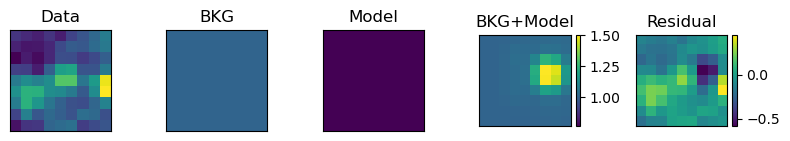

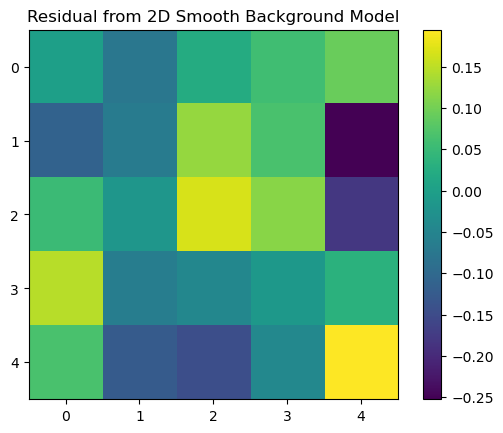

2171it [00:01, 1783.55it/s, +200 | bound: 9 | nc: 1 | ncall: 9637 | eff(%): 25.125 | loglstar:   -inf < -3.665 <    inf | logz: -12.827 +/-  0.203 | dlogz:  0.001 >  0.209]  


[3.14233878]
0.31592907602473186
[0.99275619]
Finished PSF psf_photometry with median residuals of -4.85%


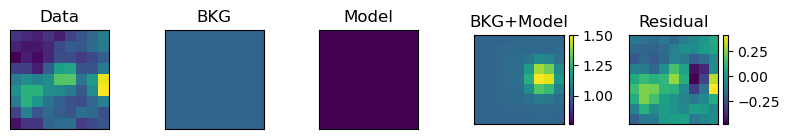

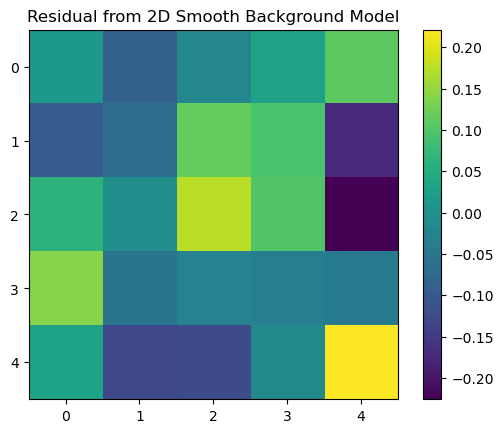

2195it [00:01, 1748.69it/s, +200 | bound: 9 | nc: 1 | ncall: 10224 | eff(%): 23.893 | loglstar:   -inf < -3.794 <    inf | logz: -13.072 +/-  0.204 | dlogz:  0.001 >  0.209] 


[2.99177205]
0.31592907602473186
[0.94518778]
Finished PSF psf_photometry with median residuals of -4.66%


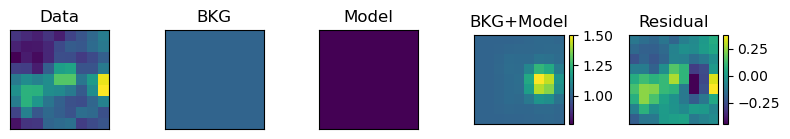

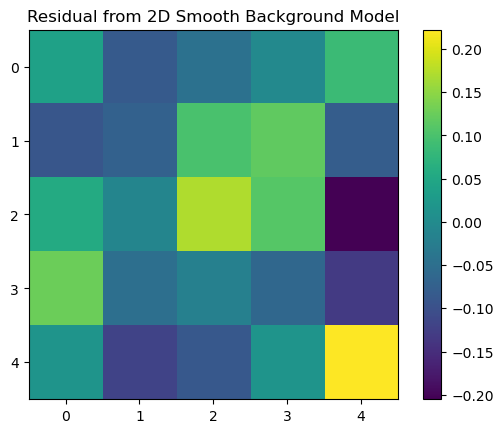

2155it [00:01, 1755.89it/s, +200 | bound: 9 | nc: 1 | ncall: 9753 | eff(%): 24.652 | loglstar:   -inf < -4.025 <    inf | logz: -13.104 +/-  0.202 | dlogz:  0.001 >  0.209]     


[3.40798058]
0.31592907602473186
[1.07668016]
Finished PSF psf_photometry with median residuals of -4.92%


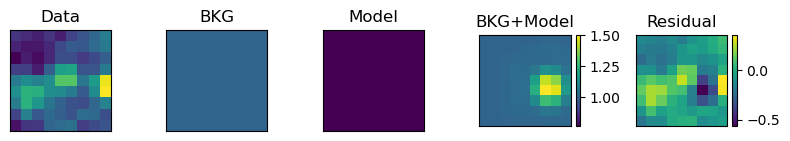

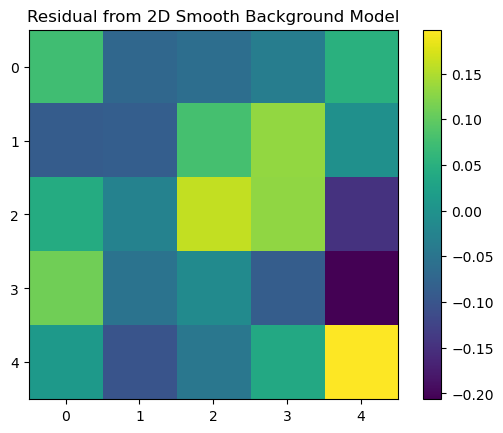

2192it [00:01, 1759.66it/s, +200 | bound: 9 | nc: 1 | ncall: 10158 | eff(%): 24.021 | loglstar:   -inf < -4.240 <    inf | logz: -13.506 +/-  0.204 | dlogz:  0.001 >  0.209]    

[4.05561743]
0.31592907602473186
[1.28128747]
Finished PSF psf_photometry with median residuals of -5.41%


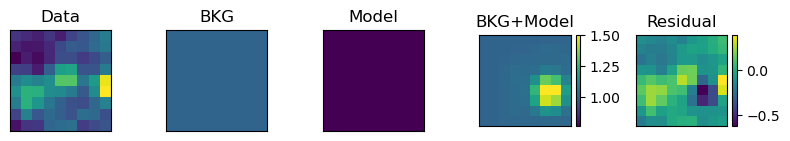

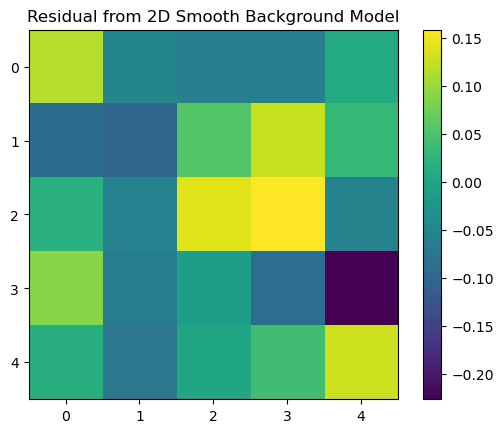

2112it [00:01, 1764.34it/s, +200 | bound: 8 | nc: 1 | ncall: 10673 | eff(%): 22.076 | loglstar:   -inf < -4.400 <    inf | logz: -13.267 +/-  0.199 | dlogz:  0.001 >  0.209]    


[5.0460423]
0.31592907602473186
[1.59419148]
Finished PSF psf_photometry with median residuals of -6.20%


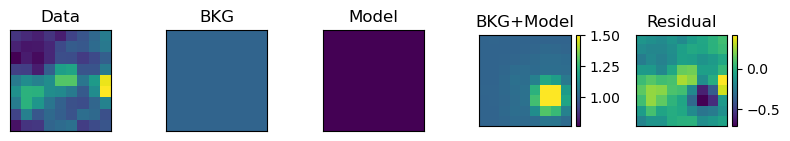

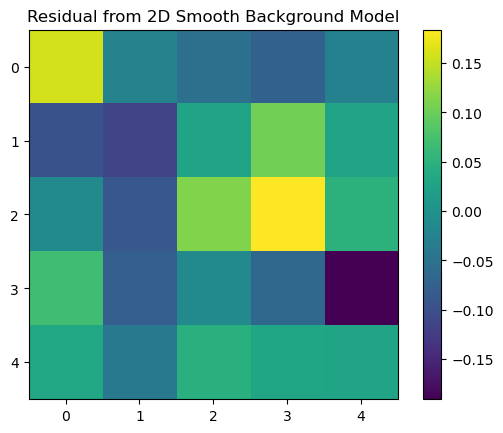

1808it [00:01, 1762.51it/s, +200 | bound: 7 | nc: 1 | ncall: 8947 | eff(%): 22.956 | loglstar:   -inf < -4.003 <    inf | logz: -11.351 +/-  0.179 | dlogz:  0.001 >  0.209]  


[12.99427299]
0.31592907602473186
[4.10526866]
Finished PSF psf_photometry with median residuals of -19.58%


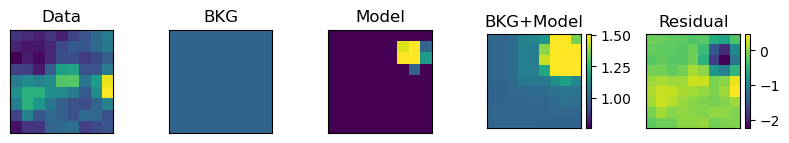

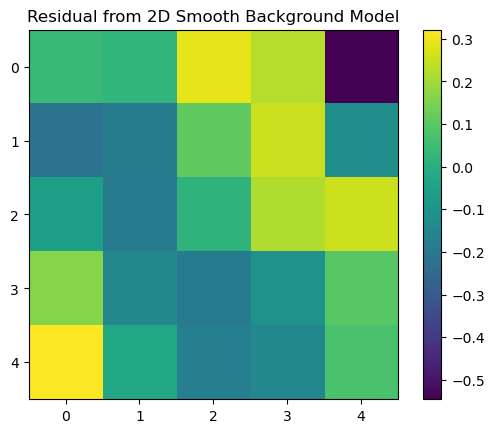

1886it [00:01, 1752.94it/s, +200 | bound: 7 | nc: 1 | ncall: 9572 | eff(%): 22.258 | loglstar:   -inf < -4.088 <    inf | logz: -11.828 +/-  0.185 | dlogz:  0.001 >  0.209]      


[9.09637146]
0.31592907602473186
[2.87380823]
Finished PSF psf_photometry with median residuals of -13.57%


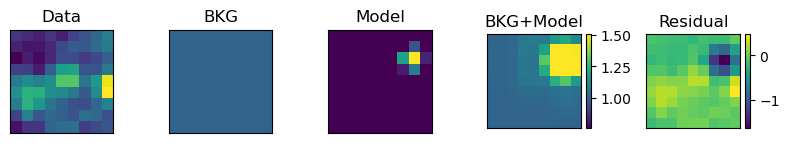

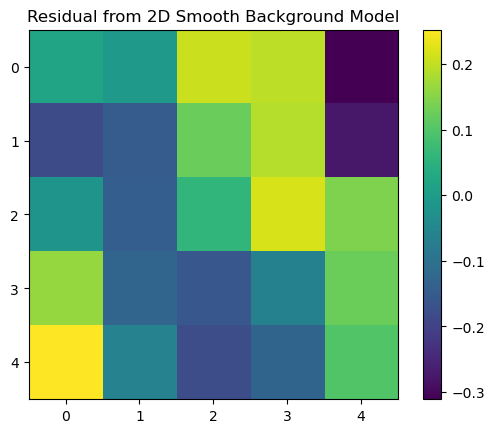

2030it [00:01, 1724.61it/s, +200 | bound: 8 | nc: 1 | ncall: 9774 | eff(%): 23.292 | loglstar:   -inf < -4.146 <    inf | logz: -12.602 +/-  0.194 | dlogz:  0.001 >  0.209]     


[6.99687281]
0.31592907602473186
[2.21051556]
Finished PSF psf_photometry with median residuals of -10.41%


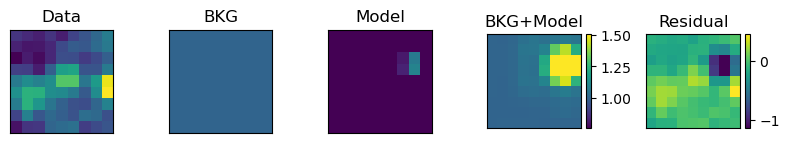

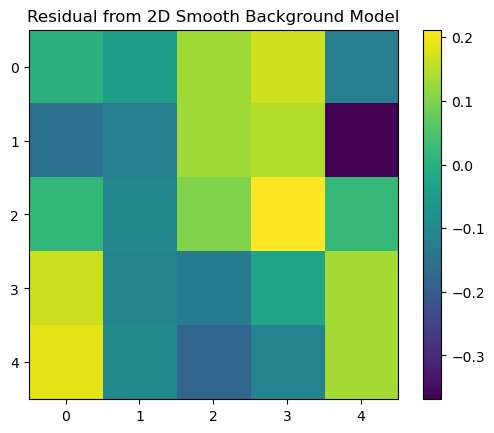

1986it [00:01, 1750.19it/s, +200 | bound: 8 | nc: 1 | ncall: 9223 | eff(%): 24.227 | loglstar:   -inf < -4.140 <    inf | logz: -12.376 +/-  0.191 | dlogz:  0.001 >  0.209]     


[5.8892447]
0.31592907602473186
[1.86058364]
Finished PSF psf_photometry with median residuals of -8.15%


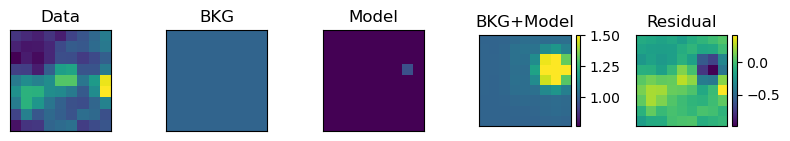

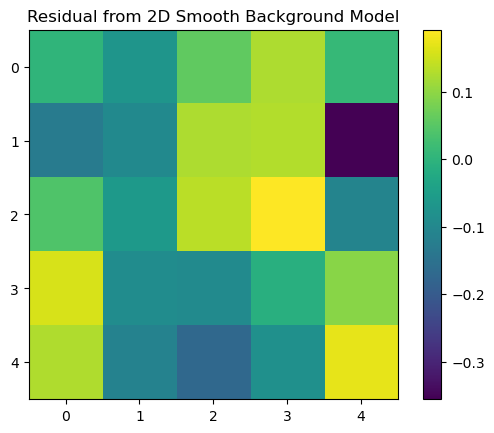

2019it [00:01, 1762.51it/s, +200 | bound: 8 | nc: 1 | ncall: 9427 | eff(%): 24.049 | loglstar:   -inf < -4.136 <    inf | logz: -12.539 +/-  0.193 | dlogz:  0.001 >  0.209]     


[5.38553053]
0.31592907602473186
[1.70144568]
Finished PSF psf_photometry with median residuals of -7.23%


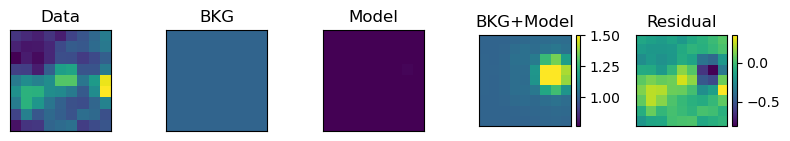

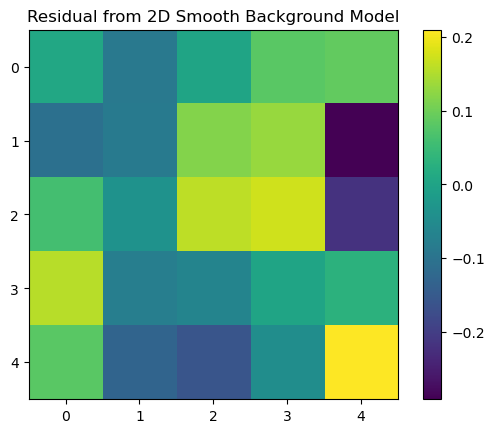

2029it [00:01, 1754.13it/s, +200 | bound: 8 | nc: 1 | ncall: 9723 | eff(%): 23.406 | loglstar:   -inf < -4.163 <    inf | logz: -12.614 +/-  0.194 | dlogz:  0.001 >  0.209]     


[4.55323858]
0.31592907602473186
[1.43850046]
Finished PSF psf_photometry with median residuals of -6.75%


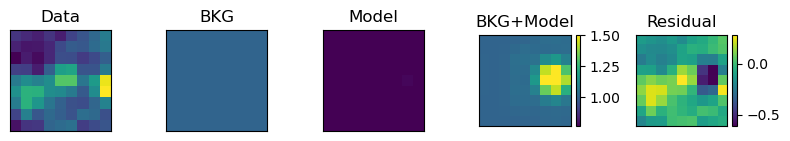

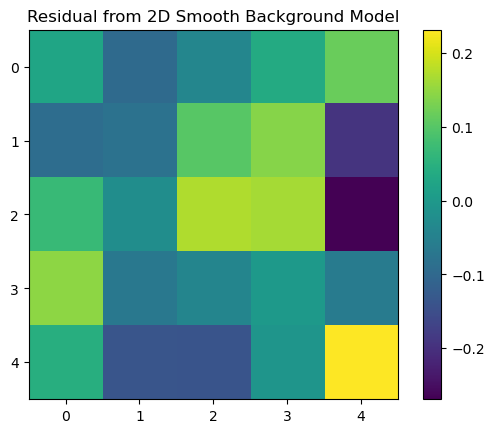

2052it [00:01, 1768.28it/s, +200 | bound: 8 | nc: 1 | ncall: 9507 | eff(%): 24.197 | loglstar:   -inf < -4.200 <    inf | logz: -12.768 +/-  0.195 | dlogz:  0.001 >  0.209]      


[5.03661838]
0.31592907602473186
[1.59121419]
Finished PSF psf_photometry with median residuals of -6.69%


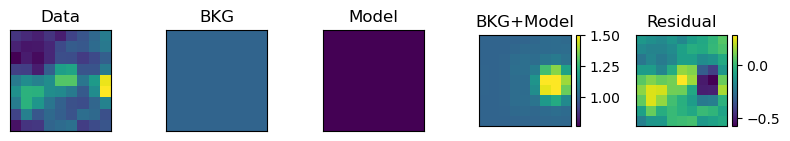

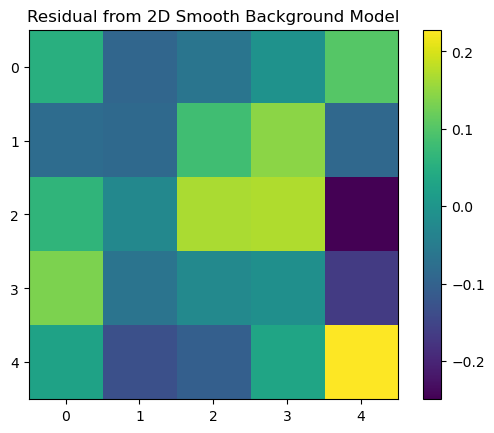

1992it [00:01, 1790.48it/s, +200 | bound: 8 | nc: 1 | ncall: 8924 | eff(%): 25.126 | loglstar:   -inf < -4.234 <    inf | logz: -12.503 +/-  0.192 | dlogz:  0.001 >  0.209]     


[5.40403855]
0.31592907602473186
[1.70729291]
Finished PSF psf_photometry with median residuals of -7.08%


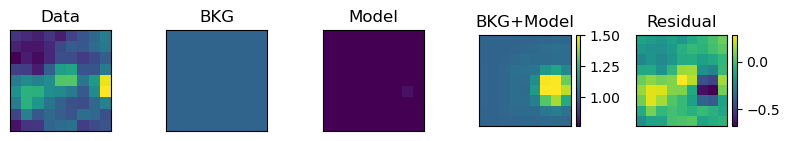

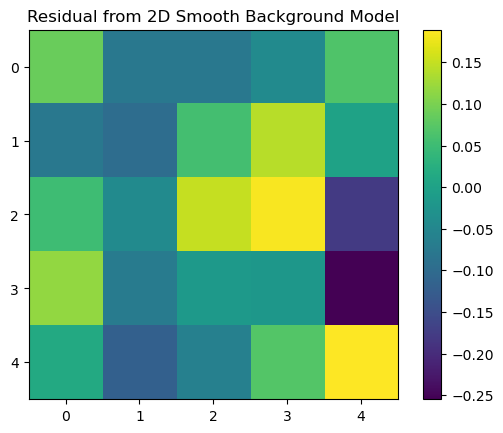

2040it [00:01, 1745.29it/s, +200 | bound: 8 | nc: 1 | ncall: 9750 | eff(%): 23.455 | loglstar:   -inf < -4.179 <    inf | logz: -12.684 +/-  0.195 | dlogz:  0.001 >  0.209]      


[6.11839047]
0.31592907602473186
[1.93297745]
Finished PSF psf_photometry with median residuals of -8.43%


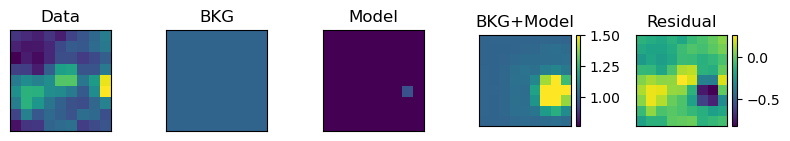

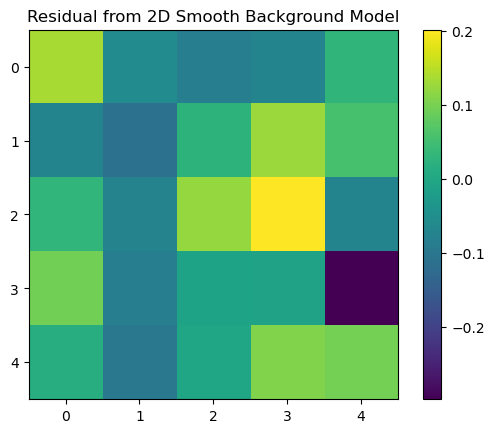

1963it [00:01, 1722.58it/s, +200 | bound: 8 | nc: 1 | ncall: 9478 | eff(%): 23.313 | loglstar:   -inf < -4.012 <    inf | logz: -12.135 +/-  0.190 | dlogz:  0.001 >  0.209]      

[7.93521817]
0.31592907602473186
[2.50696615]
Finished PSF psf_photometry with median residuals of -11.11%


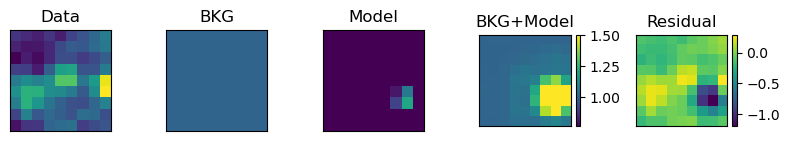

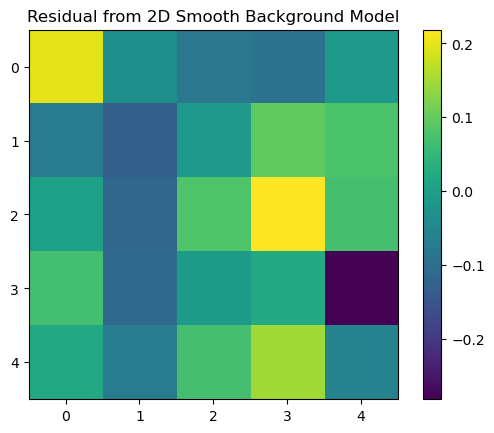

In [160]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=9,
                                                      xshift_range=[-2,2], yshift_range=[-2,2], background_range=[1,1],
                                                      nxs=10, nys=10, nbkg=1, plotting=True)

# x = 0.666
# y = 0.66
# background = 1.11

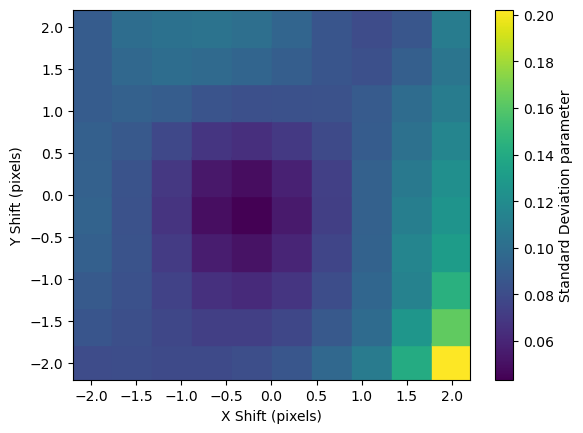

In [161]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')


Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.043434222125167746
x_shift:  -0.22222222222222232 y_shift:  -0.22222222222222232
background:  1.0


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

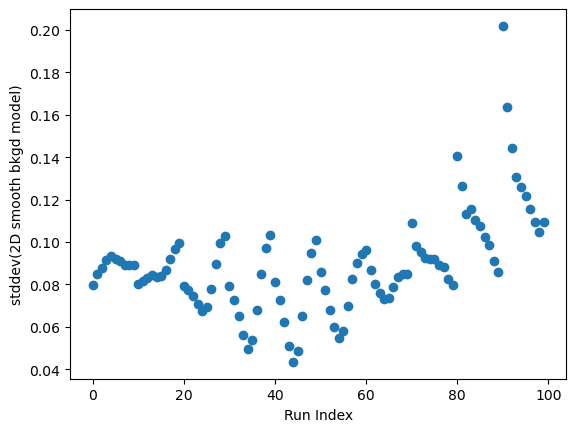

In [162]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2308it [00:01, 1801.79it/s, +200 | bound: 10 | nc: 1 | ncall: 9753 | eff(%): 26.254 | loglstar:   -inf < -0.662 <    inf | logz: -10.503 +/-  0.211 | dlogz:  0.001 >  0.209]    


[1.03381079]
0.31592907602473186
[0.32661089]
Finished PSF psf_photometry with median residuals of -2.88%


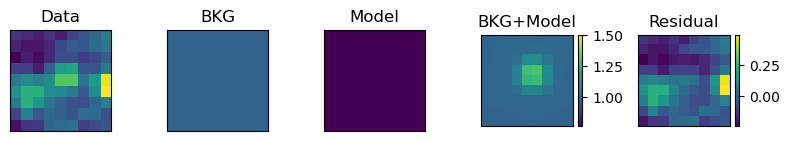

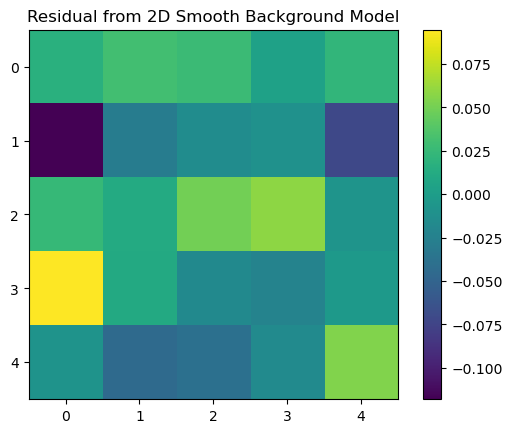

In [163]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=9,
                                                      xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
                                                      yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
                                                      background_range=[back_ground[min_ind],back_ground[min_ind]],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [164]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra        ...                        exp                        
----------------- ... --------------------------------------------------
53.38174187508846 ... jw02107-o021_t003_nircam_clear-f200w_jhat_i2d.fits
       mag              magerr      
----------------- ------------------
26.72830838239731 0.2938635669273864


#### Calculate Flux

In [165]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  7.390548085992654e-08
FLUX ERROR [Jy] =  2.0003135315746305e-08


# F300M

In [166]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F300M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F300M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F300M', 'F300M', 'F300M', 'F300M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00001_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00003_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1000w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f2100w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_cle

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00001_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00003_nrcblong_cal.fits']

2025-11-04 13:17:30,621 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 13:17:30,622 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 13:17:30,623 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 13:17:30,624 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 13:17:30,624 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 13:17:30,625 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 13:17:30,625 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 13:17:30,755 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 13:17:30,760 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

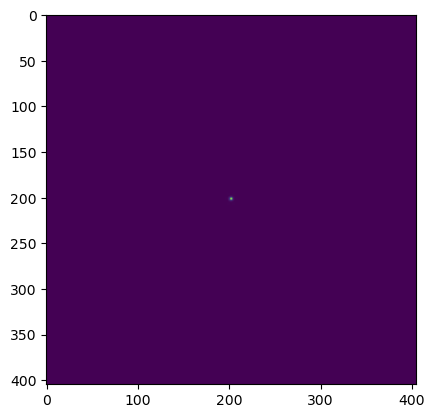

In [167]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

In [172]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[-2,2], yshift_range=[-2,2], background_range=[0.55,0.55],
                                                      nxs=10, nys=10, nbkg=1, plotting=False)

# x = 0.55
# y = -0.44
# background = 0.55


2236it [00:01, 1720.44it/s, +200 | bound: 9 | nc: 1 | ncall: 10064 | eff(%): 24.696 | loglstar:   -inf < -2.433 <    inf | logz: -11.916 +/-  0.207 | dlogz:  0.001 >  0.209] 


[2.46353569]
0.3235708421158301
[0.79712832]
Finished PSF psf_photometry with median residuals of -1.74%


2268it [00:01, 1835.62it/s, +200 | bound: 9 | nc: 1 | ncall: 9946 | eff(%): 25.323 | loglstar:   -inf < -2.326 <    inf | logz: -11.970 +/-  0.209 | dlogz:  0.001 >  0.209]  


[1.95737798]
0.3235708421158301
[0.63335044]
Finished PSF psf_photometry with median residuals of -2.14%


2280it [00:01, 1798.55it/s, +200 | bound: 9 | nc: 1 | ncall: 10454 | eff(%): 24.186 | loglstar:   -inf < -2.126 <    inf | logz: -11.832 +/-  0.210 | dlogz:  0.001 >  0.209] 


...

[1.80651891]
0.3235708421158301
[0.58453685]
Finished PSF psf_photometry with median residuals of -1.82%


2254it [00:01, 1756.40it/s, +200 | bound: 9 | nc: 1 | ncall: 10262 | eff(%): 24.389 | loglstar:   -inf < -2.378 <    inf | logz: -11.950 +/-  0.208 | dlogz:  0.001 >  0.209] 


[2.20656253]
0.3235708421158301
[0.7139793]
Finished PSF psf_photometry with median residuals of -1.85%


2139it [00:01, 1834.91it/s, +200 | bound: 8 | nc: 1 | ncall: 9460 | eff(%): 25.259 | loglstar:   -inf < -2.406 <    inf | logz: -11.407 +/-  0.201 | dlogz:  0.001 >  0.209]  

[2.78327668]
0.3235708421158301
[0.90058718]
Finished PSF psf_photometry with median residuals of -2.48%


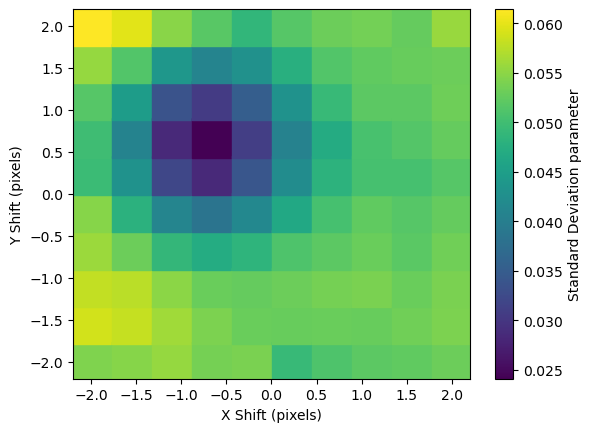

In [173]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')


Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.024112781333287103
x_shift:  -0.6666666666666667 y_shift:  0.6666666666666665
background:  0.55


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

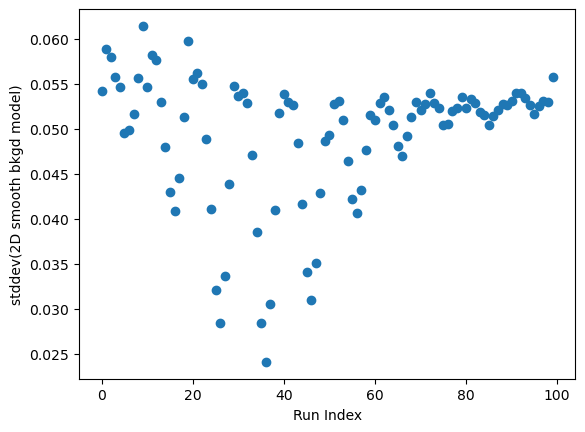

In [174]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2371it [00:01, 1790.09it/s, +200 | bound: 10 | nc: 1 | ncall: 9840 | eff(%): 26.670 | loglstar:   -inf < -0.096 <    inf | logz: -10.254 +/-  0.215 | dlogz:  0.001 >  0.209]    


[0.77355418]
0.3235708421158301
[0.25029958]
Finished PSF psf_photometry with median residuals of -2.60%


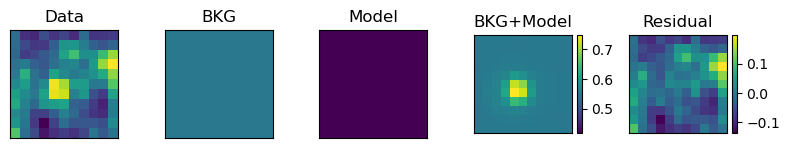

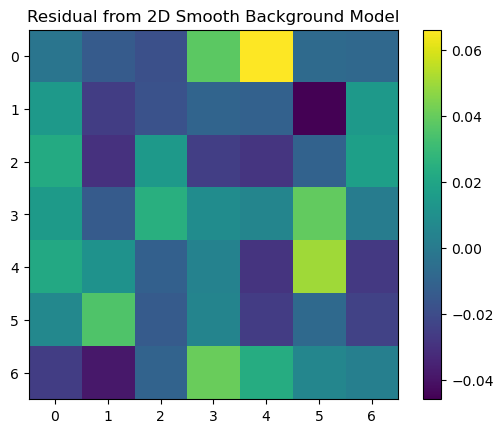

In [175]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
                                                      yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
                                                      background_range=[back_ground[min_ind],back_ground[min_ind]],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [176]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra         ...                        exp                        
------------------ ... --------------------------------------------------
53.381756423404575 ... jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits
       mag               magerr      
------------------ ------------------
25.848312299878454 0.3914611271946753


#### Calculate Flux

In [177]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  1.6621686239081972e-07
FLUX ERROR [Jy] =  5.992932723908535e-08


# NIRCAM F335M

In [178]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F335M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F335M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F335M', 'F335M', 'F335M', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1000w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f2100w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_cle

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcblong_cal.fits']

2025-11-04 13:23:07,373 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 13:23:07,373 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 13:23:07,374 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 13:23:07,375 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 13:23:07,376 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 13:23:07,376 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 13:23:07,377 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 13:23:07,491 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 13:23:07,496 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

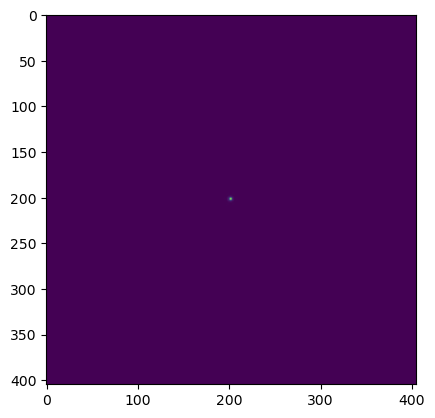

In [179]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

In [184]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[-2,2], yshift_range=[-2,2], background_range=[0.66,0.66],
                                                      nxs=10, nys=10, nbkg=1, plotting=False)

# x = 0.333
# y = 0.333
# background = 0.66

2074it [00:01, 1771.26it/s, +200 | bound: 8 | nc: 1 | ncall: 9569 | eff(%): 24.272 | loglstar:   -inf < -7.599 <    inf | logz: -16.275 +/-  0.197 | dlogz:  0.001 >  0.209]      


[4.86111362]
0.3235708421158301
[1.57291463]
Finished PSF psf_photometry with median residuals of -2.94%


2140it [00:01, 1717.83it/s, +200 | bound: 9 | nc: 1 | ncall: 9743 | eff(%): 24.521 | loglstar:   -inf < -7.530 <    inf | logz: -16.534 +/-  0.201 | dlogz:  0.001 >  0.209]      


[3.60219129]
0.3235708421158301
[1.16556407]
Finished PSF psf_photometry with median residuals of -2.40%


2223it [00:01, 1736.08it/s, +200 | bound: 9 | nc: 1 | ncall: 10264 | eff(%): 24.076 | loglstar:   -inf < -7.392 <    inf | logz: -16.812 +/-  0.206 | dlogz:  0.001 >  0.209] 


...

[1.25079431]
0.3235708421158301
[0.40472057]
Finished PSF psf_photometry with median residuals of -2.45%


2327it [00:01, 1775.20it/s, +200 | bound: 9 | nc: 1 | ncall: 10307 | eff(%): 25.002 | loglstar:   -inf < -4.576 <    inf | logz: -14.516 +/-  0.212 | dlogz:  0.001 >  0.209]    


[1.35159055]
0.3235708421158301
[0.43733529]
Finished PSF psf_photometry with median residuals of -2.54%


2323it [00:01, 1831.69it/s, +200 | bound: 9 | nc: 1 | ncall: 9907 | eff(%): 25.992 | loglstar:   -inf < -5.185 <    inf | logz: -15.102 +/-  0.212 | dlogz:  0.001 >  0.209]     

[1.59921726]
0.3235708421158301
[0.51746008]
Finished PSF psf_photometry with median residuals of -2.78%


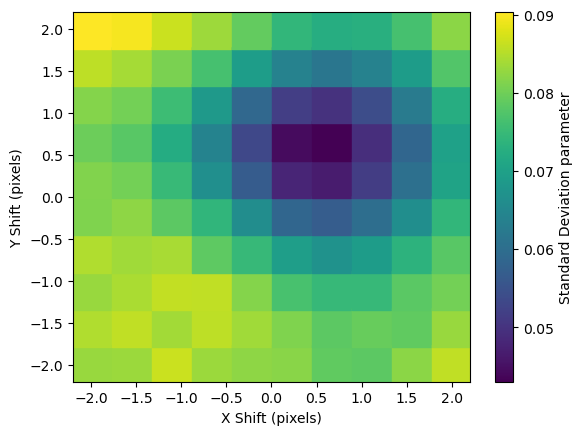

In [185]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')


Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.04304733954724273
x_shift:  0.6666666666666665 y_shift:  0.6666666666666665
background:  0.66


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

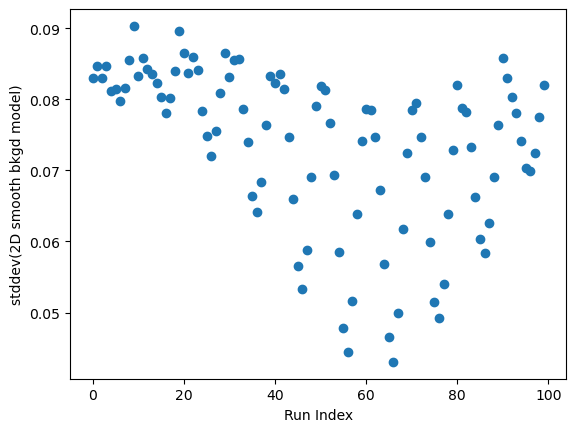

In [186]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2423it [00:01, 1775.16it/s, +200 | bound: 10 | nc: 1 | ncall: 10072 | eff(%): 26.570 | loglstar:   -inf < -0.457 <    inf | logz: -10.875 +/-  0.218 | dlogz:  0.001 >  0.209]   


[0.79487841]
0.3235708421158301
[0.25719948]
Finished PSF psf_photometry with median residuals of -1.97%


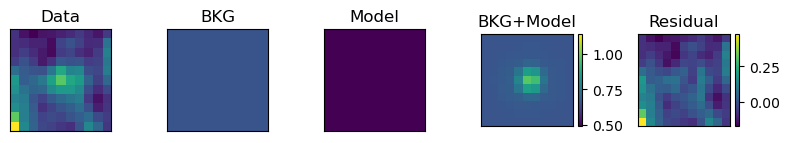

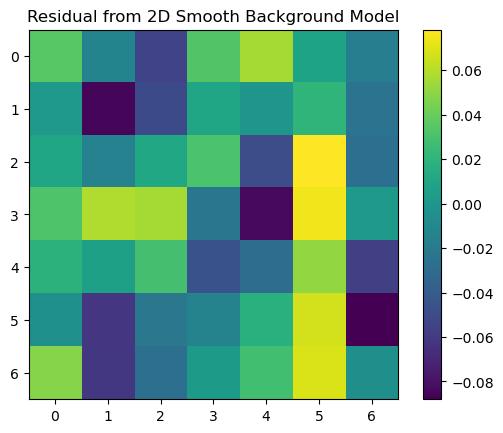

In [187]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
                                                      yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
                                                      background_range=[back_ground[min_ind],back_ground[min_ind]],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [188]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra        ...                        exp                        
----------------- ... --------------------------------------------------
53.38172788126466 ... jw02107-o021_t003_nircam_clear-f335m_jhat_i2d.fits
       mag               magerr      
------------------ ------------------
25.304548159497443 0.2597991511504836


#### Calculate Flux

In [189]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  2.742715344196298e-07
FLUX ERROR [Jy] =  6.562875173056804e-08


# NIRCAM F360M

In [190]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F360M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F360M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs


['F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcblong_cal.fits']

2025-11-04 13:28:16,938 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 13:28:16,938 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 13:28:16,939 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 13:28:16,940 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 13:28:16,941 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 13:28:16,941 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 13:28:16,942 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 13:28:17,062 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 13:28:17,067 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

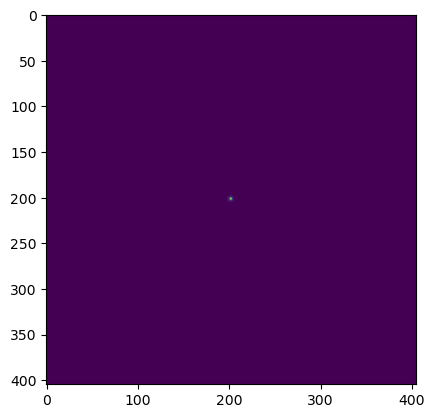

In [191]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

In [196]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[-2,2], yshift_range=[-2,2], background_range=[0.55,0.55],
                                                      nxs=10, nys=10, nbkg=1, plotting=False)

# x = -0.66
# y = -0.4
# background = 0.64


2147it [00:01, 1694.51it/s, +200 | bound: 9 | nc: 1 | ncall: 9567 | eff(%): 25.056 | loglstar:   -inf < -5.736 <    inf | logz: -14.774 +/-  0.201 | dlogz:  0.001 >  0.209]  


[3.39802079]
0.3235708421158301
[1.09950045]
Finished PSF psf_photometry with median residuals of 2.57%


2187it [00:01, 1714.97it/s, +200 | bound: 9 | nc: 1 | ncall: 9702 | eff(%): 25.121 | loglstar:   -inf < -5.581 <    inf | logz: -14.823 +/-  0.204 | dlogz:  0.001 >  0.209]  


[2.64238918]
0.3235708421158301
[0.85500009]
Finished PSF psf_photometry with median residuals of 3.09%


2188it [00:01, 1691.36it/s, +200 | bound: 9 | nc: 1 | ncall: 10242 | eff(%): 23.780 | loglstar:   -inf < -5.316 <    inf | logz: -14.561 +/-  0.204 | dlogz:  0.001 >  0.209] 


...

[2.3001389]
0.3235708421158301
[0.74425788]
Finished PSF psf_photometry with median residuals of -0.89%


2206it [00:01, 1658.80it/s, +200 | bound: 9 | nc: 1 | ncall: 9765 | eff(%): 25.154 | loglstar:   -inf < -3.569 <    inf | logz: -12.901 +/-  0.205 | dlogz:  0.001 >  0.209]  


[3.01961533]
0.3235708421158301
[0.97705947]
Finished PSF psf_photometry with median residuals of -1.69%


2135it [00:01, 1664.18it/s, +200 | bound: 9 | nc: 1 | ncall: 9622 | eff(%): 24.782 | loglstar:   -inf < -3.876 <    inf | logz: -12.855 +/-  0.201 | dlogz:  0.001 >  0.209]     

[3.58576647]
0.3235708421158301
[1.16024948]
Finished PSF psf_photometry with median residuals of -3.21%


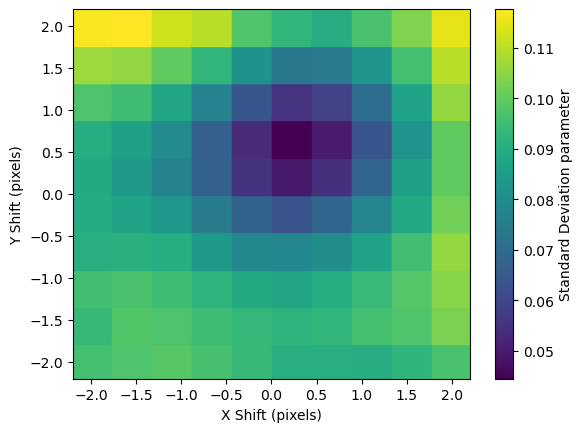

In [197]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')


Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.04450736990075753
x_shift:  0.22222222222222232 y_shift:  0.6666666666666665
background:  0.55


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

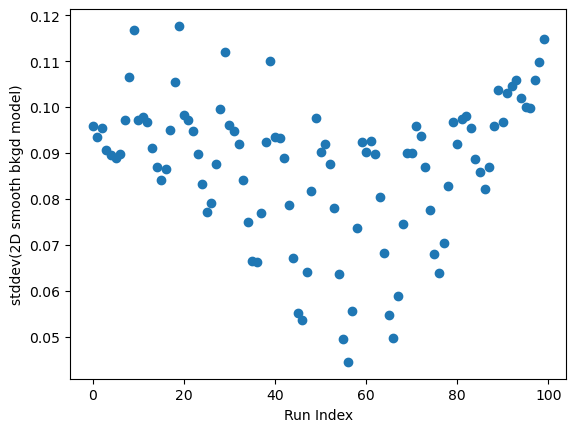

In [198]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2367it [00:01, 1685.25it/s, +200 | bound: 10 | nc: 1 | ncall: 10358 | eff(%): 25.271 | loglstar:   -inf < -0.179 <    inf | logz: -10.314 +/-  0.215 | dlogz:  0.001 >  0.209]   


[1.07930235]
0.3235708421158301
[0.34923077]
Finished PSF psf_photometry with median residuals of 1.60%


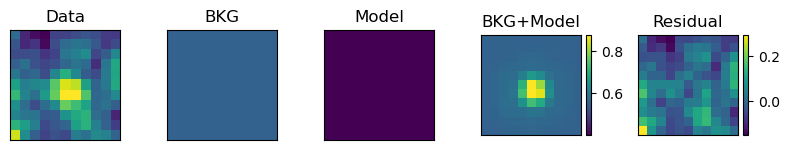

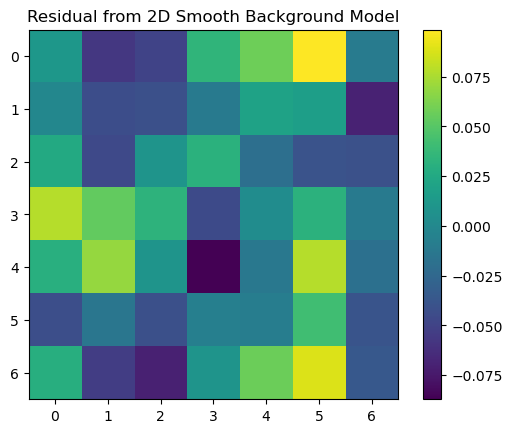

In [199]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
                                                      yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
                                                      background_range=[back_ground[min_ind],back_ground[min_ind]],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [200]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra         ...                        exp                        
------------------ ... --------------------------------------------------
53.381737394378945 ... jw02107-o021_t003_nircam_clear-f360m_jhat_i2d.fits
       mag                magerr      
------------------ -------------------
25.021259689598054 0.27038425584442555


#### Calculate Flux

In [201]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  3.5603781258025903e-07
FLUX ERROR [Jy] =  8.866520116498824e-08


# SED

In [ ]:
# Can sophie create her very first SED?!?!
x = [770, 1000, 1130, 2100, 200, 300, 335, 360]
y = [0.0000055004725286763, 0.0000387257644921614, 0.0000337287308658865, 0.000141775112312198, 7.45418213378988E-08, 1.62330452776544E-07, 3.11314966544703E-07, 3.37287308658865E-07]
yerr = [4.6390273226989E-07, 5.9210082020016E-07, 1.8909190847519416e-06, 0.0000107279857869754, 2.36175107985365E-08, 6.86259493769322E-08, 5.73463360953419E-08, 9.19533151105197E-08]

plt.errorbar(x, y, yerr=yerr, fmt='o')
plt.yscale('log')
plt.xlabel('Filter')
plt.ylabel('Flux (Jy)')
plt.title('SED of SN 1983V')
# plt.xticks(x, ['F770W', 'F1000W', 'F1130W', 'F2100W',], fontsize=8)
plt.grid()
# plt.savefig('sed_sn1983v.png', dpi=300)


In [ ]:
# axes1 = {}
# axes2 = {}


# fig, axs = plt.subplots(2,2)
# jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
#             'centroid':[-1,1],                              
#             'bkg':[-10,10]},
#             fit_width=11,
#             background = back_ground[min_ind],
#             fit_bkg=False,
#             fit_centroid=False, 
#             fit_flux=True,
#             centroidx_shift=x_shift[min_ind],
#             centroidy_shift=y_shift[min_ind],
#             psf_method='nest',
#                 center_weight=25,npoints=200)

# resid_cutout = jwst_drz_obs.psf_result.resid_arr[0][2:9,2:9]
# yy, xx = np.mgrid[0:resid_cutout.shape[0], 0:resid_cutout.shape[1]]
# xx = xx - resid_cutout.shape[1]//2
# yy = yy - resid_cutout.shape[0]//2

# # Fit and evaluate
# z = resid_cutout.flatten()
# x_flat = xx.flatten()
# y_flat = yy.flatten()
# m, ij = polyfit2d(x_flat, y_flat, z, deg=2)
# model = polyval2d_custom(xx, yy, m, ij)
# residuals_from_model = resid_cutout - model

# # Residual from background modeled; use this for error calculation:
# # residuals_from_model

# # But, which flux to use? 
# # the residual from the PSF fit?
# # resid_cutout
# # The model? model+bkg? data?


# # Final metric: deviation from smooth model
# smoothness_metric = np.std(residuals_from_model)
# print(f"Deviation from 2D smooth background model: {smoothness_metric:.5f}")
# ax1 = np.sum(jwst_drz_obs.psf_result.resid_arr[0][4:7],axis=0)
# ax2 = np.sum(jwst_drz_obs.psf_result.resid_arr[0].T[4:7],axis=0)

# axes1['%f,%f,%f'%(x_shift[min_ind],y_shift[min_ind],back_ground[min_ind])]=[ax1,smoothness_metric]
# axes2['%f,%f,%f'%(x_shift[min_ind],y_shift[min_ind],back_ground[min_ind])] = [ax2,smoothness_metric]

# axs[0,0].plot(np.arange(0,11,1),ax1,label='%f,%f,%f'%(x_shift[min_ind],y_shift[min_ind],back_ground[min_ind]))
# axs[0,0].legend(fontsize=8, loc='upper center')
# axs[0,1].plot(np.arange(0,11,1),ax2,label='%f,%f,%f'%(x_shift[min_ind],y_shift[min_ind],back_ground[min_ind]))
# axs[0,1].legend(fontsize=8, loc='upper center')
# for i in range(4,7):
#     ax1 = jwst_drz_obs.psf_result.resid_arr[0][i]
#     ax2 = jwst_drz_obs.psf_result.resid_arr[0].T[i]

#     axs[1,0].plot(np.arange(0,11,1),ax1,label=i)
#     axs[1,0].legend(fontsize=8)
# for i in range(4,7):
#     ax1 = jwst_drz_obs.psf_result.resid_arr[0][i]
#     ax2 = jwst_drz_obs.psf_result.resid_arr[0].T[i]
#     axs[1,1].plot(np.arange(0,11,1),ax2,label=i)
#     axs[1,1].legend(fontsize=8)
# plt.show()

# jwst_drz_obs.plot_psf_fit()
# plt.show()



# jwst_drz_obs.plot_psf_posterior()#minweight=0.001)
# plt.show()
